<a href="https://colab.research.google.com/github/Eceeeeeeeee/Szenario-A-VetKliniken-Verbund/blob/main/W09_transformation_matching_team_a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# W08 – Staging Report | Team A | Szenario A: VetKliniken-Verbund

Dieses Notebook implementiert **Meilenstein W8**:
- Extract-Skripte für alle vier Quellen (CSV, JSON, XML mit Namespace)
- Befüllung aller acht `staging.*`-Tabellen in einer DuckDB-Datenbank
- Zeilenstatistik je Tabelle gegen die Quelldatei
- **Idempotenz**: Erneuter Lauf erzeugt keine Duplikate (`DROP IF EXISTS` vor jedem Load)
- **Provenance**: Spalten `quell_zeile` und `quell_datei` in jeder Staging-Tabelle


## 0 · Abhängigkeiten installieren

In [1]:
!pip install -q duckdb lxml pandas

## 1 · Repository klonen

In [2]:
import os

REPO_URL = "https://git.x-breed.de/magruene/fallstudie_datenmanagement_master.git"
REPO_DIR = "fallstudie_datenmanagement_master"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    print("Repo bereits vorhanden – überspringe Clone.")

DATA_DIR = os.path.join(REPO_DIR, "verbund")
print("\nDateien im verbund/-Ordner:")
for f in sorted(os.listdir(DATA_DIR)):
    print(" ", f)

Repo bereits vorhanden – überspringe Clone.

Dateien im verbund/-Ordner:
  beispiel_embeddings.py
  beispiel_llm_match.py
  gold_cluster.csv
  praxis_bergblick_export.xml
  praxis_juckstadt_behandlungen.csv
  praxis_juckstadt_kunden.csv
  praxis_schmidt_behandlungen.json
  praxis_schmidt_kunden.csv
  praxis_waldrand_behandlungen.csv
  praxis_waldrand_kunden.csv
  zielschema.sql


## 2 · Imports & Konfiguration

In [3]:
import pandas as pd
import duckdb
import json
import os
from lxml import etree
from pathlib import Path
from datetime import datetime

# ── Pfade ──────────────────────────────────────────────────────────────────
REPO_DIR  = "fallstudie_datenmanagement_master"
DATA_DIR  = os.path.join(REPO_DIR, "verbund")
DB_PATH   = "verbund_staging.duckdb"

# Quelldateien
FILE_JUCK_K  = os.path.join(DATA_DIR, "praxis_juckstadt_kunden.csv")
FILE_JUCK_B  = os.path.join(DATA_DIR, "praxis_juckstadt_behandlungen.csv")
FILE_WALD_K  = os.path.join(DATA_DIR, "praxis_waldrand_kunden.csv")
FILE_WALD_B  = os.path.join(DATA_DIR, "praxis_waldrand_behandlungen.csv")
FILE_SCHM_K  = os.path.join(DATA_DIR, "praxis_schmidt_kunden.csv")
FILE_SCHM_B  = os.path.join(DATA_DIR, "praxis_schmidt_behandlungen.json")
FILE_BERG    = os.path.join(DATA_DIR, "praxis_bergblick_export.xml")

# Verfügbarkeit aller Dateien prüfen
files = {
    "juck_kunden":        FILE_JUCK_K,
    "juck_behandlungen":  FILE_JUCK_B,
    "wald_kunden":        FILE_WALD_K,
    "wald_behandlungen":  FILE_WALD_B,
    "schm_kunden":        FILE_SCHM_K,
    "schm_behandlungen":  FILE_SCHM_B,
    "berg_export":        FILE_BERG,
}

print("Quelldateien-Check:")
all_ok = True
for name, path in files.items():
    exists = Path(path).exists()
    status = "✓" if exists else "✗ FEHLT"
    print(f"  {status}  {name:25s}  {path}")
    if not exists:
        all_ok = False

if all_ok:
    print("\nAlle Quelldateien vorhanden. Pipeline kann gestartet werden.")
else:
    print("\nACHTUNG: Mindestens eine Quelldatei fehlt.")

Quelldateien-Check:
  ✓  juck_kunden                fallstudie_datenmanagement_master/verbund/praxis_juckstadt_kunden.csv
  ✓  juck_behandlungen          fallstudie_datenmanagement_master/verbund/praxis_juckstadt_behandlungen.csv
  ✓  wald_kunden                fallstudie_datenmanagement_master/verbund/praxis_waldrand_kunden.csv
  ✓  wald_behandlungen          fallstudie_datenmanagement_master/verbund/praxis_waldrand_behandlungen.csv
  ✓  schm_kunden                fallstudie_datenmanagement_master/verbund/praxis_schmidt_kunden.csv
  ✓  schm_behandlungen          fallstudie_datenmanagement_master/verbund/praxis_schmidt_behandlungen.json
  ✓  berg_export                fallstudie_datenmanagement_master/verbund/praxis_bergblick_export.xml

Alle Quelldateien vorhanden. Pipeline kann gestartet werden.


## 3 · DuckDB-Verbindung & Schemata anlegen

Alle drei Schemata (`staging`, `transform`, `final`) werden einmalig angelegt.
In diesem Meilenstein wird ausschließlich `staging` befüllt.

In [4]:
# DuckDB-Verbindung öffnen (Datei wird angelegt, falls noch nicht vorhanden)
con = duckdb.connect(DB_PATH)

# Drei Medallion-Schemata anlegen
con.execute("CREATE SCHEMA IF NOT EXISTS staging;")
con.execute("CREATE SCHEMA IF NOT EXISTS transform;")
con.execute("CREATE SCHEMA IF NOT EXISTS final;")

print(f"DuckDB-Datenbank: {DB_PATH}")
print("Schemata angelegt: staging, transform, final")

# Vorhandene Tabellen anzeigen
existing = con.execute("""
    SELECT table_schema, table_name
    FROM information_schema.tables
    WHERE table_schema IN ('staging', 'transform', 'final')
    ORDER BY table_schema, table_name
""").fetchdf()

if existing.empty:
    print("Noch keine Tabellen vorhanden – erster Lauf.")
else:
    print("\nBereits vorhandene Tabellen (werden bei Load überschrieben):")
    display(existing)

DuckDB-Datenbank: verbund_staging.duckdb
Schemata angelegt: staging, transform, final

Bereits vorhandene Tabellen (werden bei Load überschrieben):


,table_schema,table_name
0,final,behandlung_mapping_nach_praxis
1,final,behandlung_ungeklaert
2,final,kunden_konflikte
3,final,verbund_behandlung
4,final,verbund_kunde
5,staging,berg_behandlungen
6,staging,berg_patienten
7,staging,juck_behandlungen
8,staging,juck_kunden
9,staging,schm_behandlungen


## 4 · Hilfsfunktionen

In [5]:
def load_to_staging(
    con: duckdb.DuckDBPyConnection,
    df: pd.DataFrame,
    table_name: str,
    quell_datei: str,
    zeile_col: str = "quell_zeile",
) -> int:
    df = df.copy()

    # Alle Spalten als String (Bronze-Regel: alles VARCHAR)
    df = df.astype(str).where(df.notna(), other=None)

    # Provenance: quell_zeile (1-basiert, fortlaufend)
    if zeile_col not in df.columns:
        df.insert(0, zeile_col, range(1, len(df) + 1))

    # Provenance: quell_datei
    if "quell_datei" not in df.columns:
        df["quell_datei"] = quell_datei

    full_name = f"staging.{table_name}"

    # Idempotenz: Tabelle löschen und neu erstellen
    con.execute(f"DROP TABLE IF EXISTS {full_name};")
    con.register("__tmp__", df)
    con.execute(f"CREATE TABLE {full_name} AS SELECT * FROM __tmp__;")
    con.unregister("__tmp__")

    n = con.execute(f"SELECT count(*) FROM {full_name}").fetchone()[0]
    print(f"  ✓  {full_name:40s}  {n:5d} Zeilen  |  {len(df.columns)} Spalten")
    return n


def staging_stats(con: duckdb.DuckDBPyConnection) -> pd.DataFrame:
    tables = con.execute(
        "SELECT table_name "
        "FROM information_schema.tables "
        "WHERE table_schema = 'staging' "
        "ORDER BY table_name"
    ).fetchdf()

    rows = []
    for tbl in tables["table_name"]:
        n = con.execute(f"SELECT count(*) FROM staging.{tbl}").fetchone()[0]
        rows.append({"Tabelle": f"staging.{tbl}", "Zeilen": n})
    return pd.DataFrame(rows)


print("Hilfsfunktionen geladen: load_to_staging(), staging_stats()")

Hilfsfunktionen geladen: load_to_staging(), staging_stats()


---
## 5 · Extract & Load: Praxis Juckstadt


In [6]:
# ── 5.1 Juckstadt Kunden ──────────────────────────────────────────────────
print("=== Praxis Juckstadt ===")

df_juck_k = pd.read_csv(
    FILE_JUCK_K,
    sep=";",          # Juckstadt-Dialekt: Semikolon
    dtype=str,        # Bronze: alles als Text lassen
    encoding="utf-8",
    keep_default_na=False,  # "" bleibt leer, wird nicht zu NaN
)
# Leere Strings → NaN für saubere Provenance
df_juck_k = df_juck_k.replace("", pd.NA)

print(f"praxis_juckstadt_kunden.csv gelesen: {len(df_juck_k)} Zeilen, Spalten: {list(df_juck_k.columns)}")

load_to_staging(
    con,
    df_juck_k,
    table_name="juck_kunden",
    quell_datei="praxis_juckstadt_kunden.csv",
)

=== Praxis Juckstadt ===
praxis_juckstadt_kunden.csv gelesen: 223 Zeilen, Spalten: ['kunden_nr', 'anrede', 'vorname', 'nachname', 'strasse', 'plz', 'ort', 'telefon', 'email', 'angelegt_am']
  ✓  staging.juck_kunden                         223 Zeilen  |  12 Spalten


223

In [7]:
# ── 5.2 Juckstadt Behandlungen ────────────────────────────────────────────
df_juck_b = pd.read_csv(
    FILE_JUCK_B,
    sep=";",
    dtype=str,
    encoding="utf-8",
    keep_default_na=False,
)
df_juck_b = df_juck_b.replace("", pd.NA)

print(f"praxis_juckstadt_behandlungen.csv gelesen: {len(df_juck_b)} Zeilen, Spalten: {list(df_juck_b.columns)}")

load_to_staging(
    con,
    df_juck_b,
    table_name="juck_behandlungen",
    quell_datei="praxis_juckstadt_behandlungen.csv",
)

# Stichprobe
print("\nStichprobe – erste 3 Zeilen aus staging.juck_behandlungen:")
display(con.execute("SELECT * FROM staging.juck_behandlungen LIMIT 3").fetchdf())

praxis_juckstadt_behandlungen.csv gelesen: 150 Zeilen, Spalten: ['beh_nr', 'datum', 'patient_name', 'kunde_nachname', 'diagnose', 'kosten_euro']
  ✓  staging.juck_behandlungen                   150 Zeilen  |  8 Spalten

Stichprobe – erste 3 Zeilen aus staging.juck_behandlungen:


,quell_zeile,beh_nr,datum,patient_name,kunde_nachname,diagnose,kosten_euro,quell_datei
0,1,1,2026-02-06,Pumba,Krueger,Augenuntersuchung,"191,17",praxis_juckstadt_behandlungen.csv
1,2,2,2026-03-04,Lucky,Lange,Jaehrliche Impfung,"74,12",praxis_juckstadt_behandlungen.csv
2,3,3,2025-11-02,Lucky,Krueger,Verbandwechsel,"38,26",praxis_juckstadt_behandlungen.csv


---
## 6 · Extract & Load: Praxis Waldrand



In [8]:
# ── 6.1 Waldrand Kunden ───────────────────────────────────────────────────
print("=== Praxis Waldrand ===")

df_wald_k = pd.read_csv(
    FILE_WALD_K,
    sep=",",           # Waldrand-Dialekt: Komma
    dtype=str,
    encoding="utf-8",
    keep_default_na=False,
)
df_wald_k = df_wald_k.replace("", pd.NA)

print(f"praxis_waldrand_kunden.csv gelesen: {len(df_wald_k)} Zeilen, Spalten: {list(df_wald_k.columns)}")

load_to_staging(
    con,
    df_wald_k,
    table_name="wald_kunden",
    quell_datei="praxis_waldrand_kunden.csv",
)

=== Praxis Waldrand ===
praxis_waldrand_kunden.csv gelesen: 227 Zeilen, Spalten: ['customer_id', 'first_name', 'last_name', 'street', 'zip_code', 'city', 'phone', 'email_address', 'created_at', 'marketing_consent']
  ✓  staging.wald_kunden                         227 Zeilen  |  12 Spalten


227

In [9]:
# ── 6.2 Waldrand Behandlungen ─────────────────────────────────────────────
df_wald_b = pd.read_csv(
    FILE_WALD_B,
    sep=",",
    dtype=str,
    encoding="utf-8",
    keep_default_na=False,
)
df_wald_b = df_wald_b.replace("", pd.NA)

print(f"praxis_waldrand_behandlungen.csv gelesen: {len(df_wald_b)} Zeilen, Spalten: {list(df_wald_b.columns)}")

load_to_staging(
    con,
    df_wald_b,
    table_name="wald_behandlungen",
    quell_datei="praxis_waldrand_behandlungen.csv",
)

print("\nStichprobe – erste 3 Zeilen aus staging.wald_kunden:")
display(con.execute("SELECT * FROM staging.wald_kunden LIMIT 3").fetchdf())

praxis_waldrand_behandlungen.csv gelesen: 150 Zeilen, Spalten: ['treatment_id', 'customer_id', 'animal_name', 'species', 'treatment_date', 'diagnosis', 'total_eur']
  ✓  staging.wald_behandlungen                   150 Zeilen  |  9 Spalten

Stichprobe – erste 3 Zeilen aus staging.wald_kunden:


,quell_zeile,customer_id,first_name,last_name,street,zip_code,city,phone,email_address,created_at,marketing_consent,quell_datei
0,1,W-1001,Thomas,Berger,Hauptstr. 12,35500,Juckstadt,+49 645 01234,berger@email.de,02/09/2022,None,praxis_waldrand_kunden.csv
1,2,W-1002,K.,None,Am Markt 3,35500,Juckstadt,0645 09012,weber@email.de,05/29/2025,yes,praxis_waldrand_kunden.csv
2,3,W-1003,Petra,Vogel,Eichenallee 8,35466,Rabenau,0640/777991,None,12/29/2024,no,praxis_waldrand_kunden.csv


---
## 7 · Extract & Load: Praxis Schmidt


In [10]:
# ── 7.1 Schmidt Kunden (CSV, Pipe) ────────────────────────────────────────
print("=== Praxis Schmidt ===")

df_schm_k = pd.read_csv(
    FILE_SCHM_K,
    sep="|",           # Schmidt-Dialekt: Pipe
    dtype=str,
    encoding="utf-8",
    keep_default_na=False,
)
df_schm_k = df_schm_k.replace("", pd.NA)

print(f"praxis_schmidt_kunden.csv gelesen: {len(df_schm_k)} Zeilen, Spalten: {list(df_schm_k.columns)}")

load_to_staging(
    con,
    df_schm_k,
    table_name="schm_kunden",
    quell_datei="praxis_schmidt_kunden.csv",
)

=== Praxis Schmidt ===
praxis_schmidt_kunden.csv gelesen: 234 Zeilen, Spalten: ['nachname', 'vorname', 'anrede', 'plz', 'ort', 'strasse', 'tel', 'email', 'erfasst']
  ✓  staging.schm_kunden                         234 Zeilen  |  11 Spalten


234

In [11]:
# ── 7.2 Schmidt Behandlungen (JSON mit Flattening) ────────────────────────

with open(FILE_SCHM_B, encoding="utf-8") as f:
    raw_json = json.load(f)

print(f"JSON geladen: {len(raw_json)} Einträge")
print(f"Beispiel-Eintrag: {json.dumps(raw_json[0], ensure_ascii=False)}")

# Flattening: Ein Dict je Behandlung, tier.name und tier.art aufgelöst
behandlung_rows = []
for pos, entry in enumerate(raw_json, start=1):
    row = {"quell_zeile": pos}

    # Alle Top-Level-Felder übernehmen (außer tier)
    for key, value in entry.items():
        if key == "tier" and isinstance(value, dict):
            # Verschachteltes tier-Objekt flach auflösen
            row["tier_name"] = value.get("name", None)
            row["tier_art"]  = value.get("art",  None)
        else:
            row[key] = value if value != "" else None

    behandlung_rows.append(row)

df_schm_b = pd.DataFrame(behandlung_rows)

print(f"\nNach Flattening: {len(df_schm_b)} Zeilen, Spalten: {list(df_schm_b.columns)}")
print("Hinweis: 'betrag' bleibt als String (z. B. '48,50 EUR') – Umwandlung erfolgt in W9.")

load_to_staging(
    con,
    df_schm_b,
    table_name="schm_behandlungen",
    quell_datei="praxis_schmidt_behandlungen.json",
)

print("\nStichprobe – erste 3 Zeilen aus staging.schm_behandlungen:")
display(con.execute("SELECT * FROM staging.schm_behandlungen LIMIT 3").fetchdf())

JSON geladen: 150 Einträge
Beispiel-Eintrag: {"id": 301, "datum": "24.09.2025", "kunde": "Schneider X.", "tier": {"name": "Caesar", "art": "Katze"}, "leistung": "Vorsorgeuntersuchung", "betrag": "15,46 EUR"}

Nach Flattening: 150 Zeilen, Spalten: ['quell_zeile', 'id', 'datum', 'kunde', 'tier_name', 'tier_art', 'leistung', 'betrag']
Hinweis: 'betrag' bleibt als String (z. B. '48,50 EUR') – Umwandlung erfolgt in W9.
  ✓  staging.schm_behandlungen                   150 Zeilen  |  9 Spalten

Stichprobe – erste 3 Zeilen aus staging.schm_behandlungen:


,quell_zeile,id,datum,kunde,tier_name,tier_art,leistung,betrag,quell_datei
0,1,301,24.09.2025,Schneider X.,Caesar,Katze,Vorsorgeuntersuchung,"15,46 EUR",praxis_schmidt_behandlungen.json
1,2,302,13.10.2025,Schneider T.,Tiger,Katze,Kontrolle,"148,99 EUR",praxis_schmidt_behandlungen.json
2,3,303,24.03.2026,Muleler I.,Caesar,Katze,Vorsorgeuntersuchung,"167,34 EUR",praxis_schmidt_behandlungen.json


---
## 8 · Extract & Load: Praxis Bergblick (XML mit Namespace)



In [12]:
# ── 8.1 XML parsen und Namespace erkennen ─────────────────────────────────
print("=== Praxis Bergblick (XML) ===")

tree = etree.parse(FILE_BERG)
root = tree.getroot()

# Namespace automatisch aus dem Root-Element auslesen
ns_map  = root.nsmap
ns_uri  = list(ns_map.values())[0] if ns_map else ""
ns_pre  = f"{{{ns_uri}}}" if ns_uri else ""

print(f"Root-Tag    : {root.tag.split('}')[-1]}")
print(f"Namespace   : {ns_uri if ns_uri else '(keiner)'}")
print(f"Direkte Kinder: {[child.tag.split('}')[-1] for child in root]}")

# Hilfsfunktionen (namespace-aware)
def xml_tag(name: str) -> str:
    """Gibt den vollständig qualifizierten Tag-Namen zurück."""
    return f"{ns_pre}{name}"

def text_or_none(element) -> str | None:
    """Liest Text aus einem XML-Element (None bei fehlendem Element oder leerem Text)."""
    if element is None or element.text is None:
        return None
    v = element.text.strip()
    return v if v else None

def find_text(parent, tag_name: str) -> str | None:
    """Sucht ein Kind-Element (namespace-aware) und gibt seinen Text zurück."""
    if parent is None:
        return None
    return text_or_none(parent.find(xml_tag(tag_name)))

def get_attr(element, attr_name: str) -> str | None:
    """Liest ein XML-Attribut aus."""
    if element is None:
        return None
    v = element.get(attr_name)
    return v.strip() if v else None

print("\nXML-Hilfsfunktionen bereit.")

=== Praxis Bergblick (XML) ===
Root-Tag    : praxisexport
Namespace   : http://vetkliniken-hessen.de/schema/v2
Direkte Kinder: ['praxis', 'patienten', 'behandlungen']

XML-Hilfsfunktionen bereit.


In [13]:
# ── 8.2 Patienten / Halter / Tiere extrahieren ────────────────────────────
patienten_rows = []

for pos, patient in enumerate(root.iter(xml_tag("patient")), start=1):
    halter = patient.find(xml_tag("halter"))
    tier   = patient.find(xml_tag("tier"))

    row = {
        "quell_zeile"    : pos,
        "patient_id"     : get_attr(patient, "id"),
        "quell_datei"    : "praxis_bergblick_export.xml",
    }

    # Halter
    if halter is not None:
        row["halter_id"]       = get_attr(halter, "id") or get_attr(patient, "id")
        row["halter_anrede"]   = find_text(halter, "anrede")
        row["halter_name"]     = find_text(halter, "name")
        row["halter_vorname"]  = find_text(halter, "vorname")
        row["halter_nachname"] = find_text(halter, "nachname")

        kontakt = halter.find(xml_tag("kontakt"))
        if kontakt is not None:
            telefon_el              = kontakt.find(xml_tag("telefon"))
            row["halter_telefon"]   = text_or_none(telefon_el)
            row["halter_tel_typ"]   = get_attr(telefon_el, "typ")
            row["halter_email"]     = find_text(kontakt, "email")

        adresse = halter.find(xml_tag("adresse"))
        if adresse is not None:
            row["halter_strasse"] = find_text(adresse, "strasse")
            row["halter_plz"]     = find_text(adresse, "plz")
            row["halter_ort"]     = find_text(adresse, "ort")

    # Tier
    if tier is not None:
        row["tier_id"]     = get_attr(tier, "id")
        row["tier_name"]   = find_text(tier, "name")
        row["tier_art"]    = find_text(tier, "art")
        row["tier_geburt"] = find_text(tier, "geburt")

    patienten_rows.append(row)

df_berg_p = pd.DataFrame(patienten_rows)

# Falls Vorname/Nachname in halter_name kombiniert: aufteilen
if "halter_name" in df_berg_p.columns:
    name_split = (
        df_berg_p["halter_name"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.split(r"\s+", n=1, expand=True)
    )
    # Nur befüllen, wenn die Felder noch leer sind
    if "halter_vorname" not in df_berg_p.columns or df_berg_p["halter_vorname"].isna().all():
        df_berg_p["halter_vorname"] = name_split[0].replace("", pd.NA)
    if "halter_nachname" not in df_berg_p.columns or df_berg_p["halter_nachname"].isna().all():
        df_berg_p["halter_nachname"] = name_split[1].replace("", pd.NA) if name_split.shape[1] > 1 else pd.NA

print(f"berg_patienten extrahiert: {len(df_berg_p)} Zeilen, {len(df_berg_p.columns)} Spalten")
display(df_berg_p.head(3))

berg_patienten extrahiert: 232 Zeilen, 18 Spalten


,quell_zeile,patient_id,quell_datei,halter_id,halter_anrede,halter_name,halter_vorname,halter_nachname,halter_telefon,halter_tel_typ,halter_email,halter_strasse,halter_plz,halter_ort,tier_id,tier_name,tier_art,tier_geburt
0,1,P-4001,praxis_bergblick_export.xml,P-4001,Herr,Thomas Berger,Thomas,Berger,0645-01234,festnetz,berger@email.de,Hauptstrasse 12,35500,Juckstadt,None,Lucky,Hund,2022-05-03
1,2,P-4002,praxis_bergblick_export.xml,P-4002,Frau,Marion Hoffmann,Marion,Hoffmann,0645-02233,mobil,hoffmann@email.de,Kirchgasse 4,35500,Juckstadt,None,Buddy,Hund,2021-11-18
2,3,P-4003,praxis_bergblick_export.xml,P-4003,Frau,Petra Vogel,Petra,Vogel,0640-7779913,festnetz,vogel@email.de,Eichenallee 8,35466,Rabenau,None,Luna,Hund,2020-05-09


In [14]:
# ── 8.3 Behandlungen extrahieren ──────────────────────────────────────────
behandlung_rows = []

for pos, behandlung in enumerate(root.iter(xml_tag("behandlung")), start=1):
    summe = behandlung.find(xml_tag("summe"))

    row = {
        "quell_zeile"   : pos,
        "quell_datei"   : "praxis_bergblick_export.xml",
        "behandlung_id" : get_attr(behandlung, "id"),
        "patient_id"    : get_attr(behandlung, "patientId"),
        "datum"         : get_attr(behandlung, "datum"),
        "diagnose"      : find_text(behandlung, "diagnose"),
        "leistung"      : find_text(behandlung, "leistung"),
        "kosten_netto"  : get_attr(summe, "netto"),
        "kosten_brutto" : get_attr(summe, "brutto"),
    }
    behandlung_rows.append(row)

df_berg_b = pd.DataFrame(behandlung_rows)

print(f"berg_behandlungen extrahiert: {len(df_berg_b)} Zeilen, {len(df_berg_b.columns)} Spalten")
display(df_berg_b.head(3))

berg_behandlungen extrahiert: 150 Zeilen, 9 Spalten


,quell_zeile,quell_datei,behandlung_id,patient_id,datum,diagnose,leistung,kosten_netto,kosten_brutto
0,1,praxis_bergblick_export.xml,None,P-4191,2025-11-15,Tumorabklaerung,None,162.92,193.87
1,2,praxis_bergblick_export.xml,None,P-4094,2025-11-02,Zahnsteinentfernung,None,32.55,38.73
2,3,praxis_bergblick_export.xml,None,P-4036,2026-03-12,Allergietest,None,161.95,192.72


In [15]:
# ── 8.4 Bergblick in Staging schreiben ────────────────────────────────────

# Für Bergblick wurden quell_zeile und quell_datei bereits beim Extrahieren gesetzt.
# load_to_staging() prüft auf doppelte Spalten und überspringt das Hinzufügen.

load_to_staging(
    con,
    df_berg_p,
    table_name="berg_patienten",
    quell_datei="praxis_bergblick_export.xml",
)

load_to_staging(
    con,
    df_berg_b,
    table_name="berg_behandlungen",
    quell_datei="praxis_bergblick_export.xml",
)

print("\nStichprobe – erste 3 Zeilen aus staging.berg_patienten:")
display(con.execute("SELECT patient_id, halter_vorname, halter_nachname, halter_plz, tier_art FROM staging.berg_patienten LIMIT 3").fetchdf())

  ✓  staging.berg_patienten                      232 Zeilen  |  18 Spalten
  ✓  staging.berg_behandlungen                   150 Zeilen  |  9 Spalten

Stichprobe – erste 3 Zeilen aus staging.berg_patienten:


,patient_id,halter_vorname,halter_nachname,halter_plz,tier_art
0,P-4001,Thomas,Berger,35500,Hund
1,P-4002,Marion,Hoffmann,35500,Hund
2,P-4003,Petra,Vogel,35466,Hund


---
## 9 · Zeilenstatistik & Verifikation

Abgleich der Zeilenzahlen zwischen Quelldatei und Staging-Tabelle.
Alle Zahlen müssen übereinstimmen, jede Abweichung ist ein Extraktionsfehler.

In [16]:
# Zeilenzahlen aus den Quelldateien (unabhängig vom DuckDB-Load ermitteln)
def count_csv_rows(path: str, sep: str) -> int:
    """Zählt Datenzeilen einer CSV (ohne Header)."""
    return len(pd.read_csv(path, sep=sep, dtype=str, encoding="utf-8"))

def count_json_rows(path: str) -> int:
    """Zählt Einträge in einem JSON-Array."""
    with open(path, encoding="utf-8") as f:
        return len(json.load(f))

def count_xml_elements(path: str, tag: str, ns_uri: str) -> int:
    """Zählt XML-Elemente mit gegebenem Tag (namespace-aware)."""
    tree = etree.parse(path)
    prefix = f"{{{ns_uri}}}" if ns_uri else ""
    return sum(1 for _ in tree.getroot().iter(f"{prefix}{tag}"))

# Quelldatei-Zählungen
source_counts = {
    "juck_kunden":        (count_csv_rows(FILE_JUCK_K, ";"),          FILE_JUCK_K),
    "juck_behandlungen":  (count_csv_rows(FILE_JUCK_B, ";"),          FILE_JUCK_B),
    "wald_kunden":        (count_csv_rows(FILE_WALD_K, ","),          FILE_WALD_K),
    "wald_behandlungen":  (count_csv_rows(FILE_WALD_B, ","),          FILE_WALD_B),
    "schm_kunden":        (count_csv_rows(FILE_SCHM_K, "|"),          FILE_SCHM_K),
    "schm_behandlungen":  (count_json_rows(FILE_SCHM_B),              FILE_SCHM_B),
    "berg_patienten":     (count_xml_elements(FILE_BERG, "patient", ns_uri), FILE_BERG),
    "berg_behandlungen":  (count_xml_elements(FILE_BERG, "behandlung", ns_uri), FILE_BERG),
}

# Staging-Zählungen
stat_rows = []
all_ok = True

for tbl, (src_n, src_file) in source_counts.items():
    stg_n = con.execute(f"SELECT count(*) FROM staging.{tbl}").fetchone()[0]
    match = "✓" if stg_n == src_n else "✗ ABWEICHUNG"
    if stg_n != src_n:
        all_ok = False
    stat_rows.append({
        "Tabelle"            : f"staging.{tbl}",
        "Quelldatei"         : Path(src_file).name,
        "Zeilen Quelle"      : src_n,
        "Zeilen Staging"     : stg_n,
        "Übereinstimmung"    : match,
    })

df_stats = pd.DataFrame(stat_rows)
display(df_stats)

if all_ok:
    print("\n✓ Alle Zeilenzahlen stimmen überein – Staging vollständig.")
else:
    print("\n✗ ACHTUNG: Abweichungen gefunden – Extract-Skript prüfen!")

,Tabelle,Quelldatei,Zeilen Quelle,Zeilen Staging,Übereinstimmung
0,staging.juck_kunden,praxis_juckstadt_kunden.csv,223,223,✓
1,staging.juck_behandlungen,praxis_juckstadt_behandlungen.csv,150,150,✓
2,staging.wald_kunden,praxis_waldrand_kunden.csv,227,227,✓
3,staging.wald_behandlungen,praxis_waldrand_behandlungen.csv,150,150,✓
4,staging.schm_kunden,praxis_schmidt_kunden.csv,234,234,✓
5,staging.schm_behandlungen,praxis_schmidt_behandlungen.json,150,150,✓
6,staging.berg_patienten,praxis_bergblick_export.xml,232,232,✓
7,staging.berg_behandlungen,praxis_bergblick_export.xml,150,150,✓



✓ Alle Zeilenzahlen stimmen überein – Staging vollständig.


---
## 10 · Idempotenz-Test

Der gesamte Load wird **ein zweites Mal** ausgeführt. Die Zeilenzahlen dürfen sich danach **nicht** ändern – das beweist, dass die Pipeline idempotent ist.

In [17]:
print("=== Idempotenz-Test: zweiter Lauf ===")
print("Zählstand VOR zweitem Lauf:")
before = staging_stats(con).rename(columns={"Zeilen": "Zeilen (vorher)"})
display(before)

# Zweiter Lauf
print("\nLade alle Tabellen erneut ...")
for df, tbl, sep_or_fmt in [
    (pd.read_csv(FILE_JUCK_K, sep=";", dtype=str, encoding="utf-8", keep_default_na=False).replace("", pd.NA), "juck_kunden", "praxis_juckstadt_kunden.csv"),
    (pd.read_csv(FILE_JUCK_B, sep=";", dtype=str, encoding="utf-8", keep_default_na=False).replace("", pd.NA), "juck_behandlungen", "praxis_juckstadt_behandlungen.csv"),
    (pd.read_csv(FILE_WALD_K, sep=",", dtype=str, encoding="utf-8", keep_default_na=False).replace("", pd.NA), "wald_kunden", "praxis_waldrand_kunden.csv"),
    (pd.read_csv(FILE_WALD_B, sep=",", dtype=str, encoding="utf-8", keep_default_na=False).replace("", pd.NA), "wald_behandlungen", "praxis_waldrand_behandlungen.csv"),
    (pd.read_csv(FILE_SCHM_K, sep="|", dtype=str, encoding="utf-8", keep_default_na=False).replace("", pd.NA), "schm_kunden", "praxis_schmidt_kunden.csv"),
    (df_schm_b, "schm_behandlungen", "praxis_schmidt_behandlungen.json"),
    (df_berg_p, "berg_patienten", "praxis_bergblick_export.xml"),
    (df_berg_b, "berg_behandlungen", "praxis_bergblick_export.xml"),
]:
    load_to_staging(con, df, tbl, sep_or_fmt)

print("\nZählstand NACH zweitem Lauf:")
after = staging_stats(con).rename(columns={"Zeilen": "Zeilen (nachher)"})
display(after)

# Vergleich
merged = before.merge(after, on="Tabelle")
merged["Idempotenz"] = merged.apply(
    lambda r: "✓" if r["Zeilen (vorher)"] == r["Zeilen (nachher)"] else "✗", axis=1
)
display(merged)

if merged["Idempotenz"].eq("✓").all():
    print("\n✓ Idempotenz bestätigt – kein Datensatz wurde doppelt eingefügt.")
else:
    print("\n✗ ACHTUNG: Idempotenz verletzt – load_to_staging() prüfen!")

=== Idempotenz-Test: zweiter Lauf ===
Zählstand VOR zweitem Lauf:


,Tabelle,Zeilen (vorher)
0,staging.berg_behandlungen,150
1,staging.berg_patienten,232
2,staging.juck_behandlungen,150
3,staging.juck_kunden,223
4,staging.schm_behandlungen,150
5,staging.schm_kunden,234
6,staging.wald_behandlungen,150
7,staging.wald_kunden,227



Lade alle Tabellen erneut ...
  ✓  staging.juck_kunden                         223 Zeilen  |  12 Spalten
  ✓  staging.juck_behandlungen                   150 Zeilen  |  8 Spalten
  ✓  staging.wald_kunden                         227 Zeilen  |  12 Spalten
  ✓  staging.wald_behandlungen                   150 Zeilen  |  9 Spalten
  ✓  staging.schm_kunden                         234 Zeilen  |  11 Spalten
  ✓  staging.schm_behandlungen                   150 Zeilen  |  9 Spalten
  ✓  staging.berg_patienten                      232 Zeilen  |  18 Spalten
  ✓  staging.berg_behandlungen                   150 Zeilen  |  9 Spalten

Zählstand NACH zweitem Lauf:


,Tabelle,Zeilen (nachher)
0,staging.berg_behandlungen,150
1,staging.berg_patienten,232
2,staging.juck_behandlungen,150
3,staging.juck_kunden,223
4,staging.schm_behandlungen,150
5,staging.schm_kunden,234
6,staging.wald_behandlungen,150
7,staging.wald_kunden,227


,Tabelle,Zeilen (vorher),Zeilen (nachher),Idempotenz
0,staging.berg_behandlungen,150,150,✓
1,staging.berg_patienten,232,232,✓
2,staging.juck_behandlungen,150,150,✓
3,staging.juck_kunden,223,223,✓
4,staging.schm_behandlungen,150,150,✓
5,staging.schm_kunden,234,234,✓
6,staging.wald_behandlungen,150,150,✓
7,staging.wald_kunden,227,227,✓



✓ Idempotenz bestätigt – kein Datensatz wurde doppelt eingefügt.


---
## 11 · Provenance-Verifikation

Jede Staging-Tabelle muss die Spalten `quell_zeile` (Zeilennummer) und `quell_datei` (Dateiname) enthalten.
Diese Prüfung stellt sicher, dass die Herkunft jedes Datensatzes auch nach Transform und Load nachvollziehbar bleibt.

In [18]:
print("=== Provenance-Check ===")
tabellen = [
    "juck_kunden", "juck_behandlungen",
    "wald_kunden", "wald_behandlungen",
    "schm_kunden", "schm_behandlungen",
    "berg_patienten", "berg_behandlungen",
]

prov_rows = []
for tbl in tabellen:
    cols = con.execute(
        f"SELECT column_name FROM information_schema.columns "
        f"WHERE table_schema = 'staging' AND table_name = '{tbl}'"
    ).fetchdf()["column_name"].tolist()

    has_zeile  = "quell_zeile"  in cols
    has_datei  = "quell_datei"  in cols

    # Beispielwert quell_datei
    datei_bsp = (
        con.execute(f"SELECT quell_datei FROM staging.{tbl} LIMIT 1").fetchone()[0]
        if has_datei else "–"
    )

    prov_rows.append({
        "Tabelle"      : f"staging.{tbl}",
        "quell_zeile"  : "✓" if has_zeile else "✗",
        "quell_datei"  : "✓" if has_datei else "✗",
        "Datei-Beispiel": datei_bsp,
    })

display(pd.DataFrame(prov_rows))

all_prov = all(r["quell_zeile"] == "✓" and r["quell_datei"] == "✓" for r in prov_rows)
if all_prov:
    print("\n✓ Alle Staging-Tabellen tragen Provenance-Spalten.")
else:
    print("\n✗ ACHTUNG: Provenance fehlt in mindestens einer Tabelle.")

=== Provenance-Check ===


,Tabelle,quell_zeile,quell_datei,Datei-Beispiel
0,staging.juck_kunden,✓,✓,praxis_juckstadt_kunden.csv
1,staging.juck_behandlungen,✓,✓,praxis_juckstadt_behandlungen.csv
2,staging.wald_kunden,✓,✓,praxis_waldrand_kunden.csv
3,staging.wald_behandlungen,✓,✓,praxis_waldrand_behandlungen.csv
4,staging.schm_kunden,✓,✓,praxis_schmidt_kunden.csv
5,staging.schm_behandlungen,✓,✓,praxis_schmidt_behandlungen.json
6,staging.berg_patienten,✓,✓,praxis_bergblick_export.xml
7,staging.berg_behandlungen,✓,✓,praxis_bergblick_export.xml



✓ Alle Staging-Tabellen tragen Provenance-Spalten.


---
## 12 · Überprüfung der Tabellen & Zeilenstatistik als CSV speichern





In [19]:
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)
DB_PATH = OUT_DIR / "verbund_staging.duckdb"

print(f"Output directory: {OUT_DIR}")
print(f"Database path: {DB_PATH}")

Output directory: output
Database path: output/verbund_staging.duckdb


In [20]:
con.execute("""
SELECT
    table_schema,
    table_name
FROM information_schema.tables
ORDER BY table_schema, table_name
""").df()

,table_schema,table_name
0,final,behandlung_mapping_nach_praxis
1,final,behandlung_ungeklaert
2,final,kunden_konflikte
3,final,verbund_behandlung
4,final,verbund_kunde
5,staging,berg_behandlungen
6,staging,berg_patienten
7,staging,juck_behandlungen
8,staging,juck_kunden
9,staging,schm_behandlungen


In [21]:
con.execute("""
SELECT *
FROM staging.berg_behandlungen

LIMIT 50

""").df()

,quell_zeile,quell_datei,behandlung_id,patient_id,datum,diagnose,leistung,kosten_netto,kosten_brutto
0,1,praxis_bergblick_export.xml,<NA>,P-4191,2025-11-15,Tumorabklaerung,<NA>,162.92,193.87
1,2,praxis_bergblick_export.xml,<NA>,P-4094,2025-11-02,Zahnsteinentfernung,<NA>,32.55,38.73
2,3,praxis_bergblick_export.xml,<NA>,P-4036,2026-03-12,Allergietest,<NA>,161.95,192.72
3,4,praxis_bergblick_export.xml,<NA>,P-4026,2025-09-22,Tumorabklaerung,<NA>,135.18,160.86
4,5,praxis_bergblick_export.xml,<NA>,P-4085,2026-01-22,Tumorabklaerung,<NA>,71.45,85.02
5,6,praxis_bergblick_export.xml,<NA>,P-4060,2026-01-10,Kontrolle,<NA>,48.53,57.75
6,7,praxis_bergblick_export.xml,<NA>,P-4003,2026-02-12,Allergietest,<NA>,42.88,51.03
7,8,praxis_bergblick_export.xml,<NA>,P-4202,2025-11-11,Vorsorgeuntersuchung,<NA>,46.19,54.97
8,9,praxis_bergblick_export.xml,<NA>,P-4113,2025-12-10,Jaehrliche Impfung,<NA>,51.81,61.65
9,10,praxis_bergblick_export.xml,<NA>,P-4132,2026-02-27,Tumorabklaerung,<NA>,98.72,117.48


In [22]:
con.execute("""
SELECT *
FROM staging.berg_patienten

LIMIT 50

""").df()

,quell_zeile,patient_id,quell_datei,halter_id,halter_anrede,halter_name,halter_vorname,halter_nachname,halter_telefon,halter_tel_typ,halter_email,halter_strasse,halter_plz,halter_ort,tier_id,tier_name,tier_art,tier_geburt
0,1,P-4001,praxis_bergblick_export.xml,P-4001,Herr,Thomas Berger,Thomas,Berger,0645-01234,festnetz,berger@email.de,Hauptstrasse 12,35500,Juckstadt,<NA>,Lucky,Hund,2022-05-03
1,2,P-4002,praxis_bergblick_export.xml,P-4002,Frau,Marion Hoffmann,Marion,Hoffmann,0645-02233,mobil,hoffmann@email.de,Kirchgasse 4,35500,Juckstadt,<NA>,Buddy,Hund,2021-11-18
2,3,P-4003,praxis_bergblick_export.xml,P-4003,Frau,Petra Vogel,Petra,Vogel,0640-7779913,festnetz,vogel@email.de,Eichenallee 8,35466,Rabenau,<NA>,Luna,Hund,2020-05-09
3,4,P-4004,praxis_bergblick_export.xml,P-4004,Herr,B. Schulz,B.,Schulz,0640-7771212,mobil,schulz@email.de,Dorfstr. 44,35466,Rabenau,<NA>,Lola,Hund,2019-05-07
4,5,P-4005,praxis_bergblick_export.xml,P-4005,Frau,Bettina Klein,Bettina,Klein,0645-020031,privat,klein.b@gmx.de,Bergstr. 9,35510,Waldrand,<NA>,Buddy,Hund,2021-03-11
5,6,P-4006,praxis_bergblick_export.xml,P-4006,Herr,Yannick Wolf,Yannick,Wolf,0645-0388618,festnetz,wolf.y@email.de,Buchenweg 68,35511,Hoehental,<NA>,Cleo,Katze,2020-05-09
6,7,P-4007,praxis_bergblick_export.xml,P-4007,Frau,Anna Werner,Anna,Werner,0645-02805,privat,werner.a@web.de,Dorfstr. 77,35510,Waldrand,<NA>,Kitty,Katze,2023-04-08
7,8,P-4008,praxis_bergblick_export.xml,P-4008,Frau,Bettina Schulze,Bettina,Schulze,0645-0068677,festnetz,schulze.b@email.de,Bahnhofstrasse 94,35510,Bergblick-Siedlung,<NA>,Bruno,Hund,2024-09-02
8,9,P-4009,praxis_bergblick_export.xml,P-4009,Frau,Ines Lange,Ines,Lange,0645-05896,mobil,lange.i@web.de,Bergstr. 57,35510,Waldrand,<NA>,Nala,Hund,2023-09-27
9,10,P-4010,praxis_bergblick_export.xml,P-4010,Frau,Ines Hoffmann,Ines,Hoffmann,0645-0994347,festnetz,hoffmann.i@email.de,Talstr. 94,35511,Hoehental,<NA>,Schnurri,Katze,2022-01-04


In [23]:
con.execute("""
SELECT *
FROM staging.juck_behandlungen

LIMIT 50

""").df()

,quell_zeile,beh_nr,datum,patient_name,kunde_nachname,diagnose,kosten_euro,quell_datei
0,1,1,2026-02-06,Pumba,Krueger,Augenuntersuchung,"191,17",praxis_juckstadt_behandlungen.csv
1,2,2,2026-03-04,Lucky,Lange,Jaehrliche Impfung,"74,12",praxis_juckstadt_behandlungen.csv
2,3,3,2025-11-02,Lucky,Krueger,Verbandwechsel,"38,26",praxis_juckstadt_behandlungen.csv
3,4,4,2025-09-11,Mimi,Stein,Floehe Behandlung,"152,88",praxis_juckstadt_behandlungen.csv
4,5,5,2026-03-30,Bello,Schmidt,Tumorabklaerung,"167,99",praxis_juckstadt_behandlungen.csv
5,6,6,2025-12-20,Charlie,Lange,Wurmkur,"180,16",praxis_juckstadt_behandlungen.csv
6,7,7,2025-11-30,Bello,Kaiser,Allergietest,"168,39",praxis_juckstadt_behandlungen.csv
7,8,8,2026-03-12,Emma,Schaefer,Roentgen,"118,54",praxis_juckstadt_behandlungen.csv
8,9,9,2025-09-30,Luna,Hofmann,Vorsorgeuntersuchung,"145,19",praxis_juckstadt_behandlungen.csv
9,10,10,2025-11-15,Diego,Neumann,Floehe Behandlung,"33,96",praxis_juckstadt_behandlungen.csv


In [24]:
con.execute("""
SELECT *
FROM staging.juck_kunden

LIMIT 50

""").df()

,quell_zeile,kunden_nr,anrede,vorname,nachname,strasse,plz,ort,telefon,email,angelegt_am,quell_datei
0,1,1,Herr,Thomas,Berger,Hauptstr. 12,35500,Juckstadt,06450-1234,berger@email.de,2021-05-12,praxis_juckstadt_kunden.csv
1,2,2,Frau,Marion,Hoffmann,Kirchgasse 4,35500,Juckstadt,06450-2233,hoffmann@email.de,2024-11-29,praxis_juckstadt_kunden.csv
2,3,3,Herr,Klaus,Weber,Am Markt 3,35500,Juckstadt,06450-9012,None,2024-09-29,praxis_juckstadt_kunden.csv
3,4,4,Herr,Thomas,Neumann,Feldweg 22,35501,Oberstadt,06451-5588,neumann@email.de,2023-04-08,praxis_juckstadt_kunden.csv
4,5,5,Herr,Markus,Lehmann,Schulstr. 21,35501,Oberstadt,06451-7890,None,2022-03-29,praxis_juckstadt_kunden.csv
5,6,6,Herr,Paul,Mueller,Beethovenstr. 95,35500,Juckstadt,06450-475147,mueller.p@t-online.de,2019-07-30,praxis_juckstadt_kunden.csv
6,7,7,Herr,Karl,Kaiser,Schlossstr. 92,35501,Oberstadt,06450-6504,kaiser.k@email.de,2024-10-16,praxis_juckstadt_kunden.csv
7,8,8,Herr,Wolfgang,Kaiser,Schillerstr. 75,35500,Juckstadt,06450-1856,kaiser.w@t-online.de,2019-11-19,praxis_juckstadt_kunden.csv
8,9,9,Frau,Stefanie,Schneider,Parkstr. 40,35500,Juckstadt,06450-87380,schneider.s@t-online.de,2021-01-06,praxis_juckstadt_kunden.csv
9,10,10,Frau,Yvonne,Becker,Marktplatz 75,35500,Juckstadt,06450-503057,becker.y@t-online.de,2024-12-10,praxis_juckstadt_kunden.csv


In [25]:
con.execute("""
SELECT *
FROM staging.schm_behandlungen

LIMIT 50

""").df()

,quell_zeile,id,datum,kunde,tier_name,tier_art,leistung,betrag,quell_datei
0,1,301,24.09.2025,Schneider X.,Caesar,Katze,Vorsorgeuntersuchung,"15,46 EUR",praxis_schmidt_behandlungen.json
1,2,302,13.10.2025,Schneider T.,Tiger,Katze,Kontrolle,"148,99 EUR",praxis_schmidt_behandlungen.json
2,3,303,24.03.2026,Muleler I.,Caesar,Katze,Vorsorgeuntersuchung,"167,34 EUR",praxis_schmidt_behandlungen.json
3,4,304,10.03.2026,Klein G.,Ace,Hund,Tumorabklaerung,"91,09 EUR",praxis_schmidt_behandlungen.json
4,5,305,06.03.2026,Lehmann E.,Smokey,Katze,Zeckenbefall Spot-On,"52,04 EUR",praxis_schmidt_behandlungen.json
5,6,306,07.02.2026,Weber K.,Buddy,Hund,Ohrenentzuendung,"93,93 EUR",praxis_schmidt_behandlungen.json
6,7,307,06.10.2025,Schneider E.,Balou,Hund,Kontrolle,"83,66 EUR",praxis_schmidt_behandlungen.json
7,8,308,21.11.2025,Braun Y.,Rocky,Hund,Kastration,"124,86 EUR",praxis_schmidt_behandlungen.json
8,9,309,23.10.2025,Fischer G.,Nero,Katze,Zahnsteinentfernung,"70,04 EUR",praxis_schmidt_behandlungen.json
9,10,310,18.03.2026,Richter W.,Pumba,Katze,Kontrolle,"195,53 EUR",praxis_schmidt_behandlungen.json


In [26]:
con.execute("""
SELECT *
FROM staging.schm_kunden

LIMIT 50

""").df()

,quell_zeile,nachname,vorname,anrede,plz,ort,strasse,tel,email,erfasst,quell_datei
0,1,Berger,Th.,Hr.,35500,Juckstadt,Hauptstr. 12,0645 01234,berger@email.de,06.12.2020,praxis_schmidt_kunden.csv
1,2,Hoffmann,Marion,Fr.,35500,Juckstadt,Kirchgasse 4,0645 02233,hoffmann@email.de,02.03.2024,praxis_schmidt_kunden.csv
2,3,Klaus,Weber,Hr.,35500,Juckstadt,Am Markt 3,0645 09012,weber@email.de,06.02.2024,praxis_schmidt_kunden.csv
3,4,Vogel,Petra,Fr.,35466,Rabenau,Eichenallee 8,0640 7779912,vogel@email.de,25.04.2025,praxis_schmidt_kunden.csv
4,5,Lehmann,M.,Hr.,35501,Oberstadt,Schulstr. 21,0645 17890,lehmann@email.de,24.08.2023,praxis_schmidt_kunden.csv
5,6,Schneider,Elke,Fr.,35580,Wetzlar-Buederbach,Pfarrgasse 52,0645 054192,schneider.e@email.de,03.10.2023,praxis_schmidt_kunden.csv
6,7,Lehmann,Georg,Hr.,35580,Wetzlar-Buederbach,Wiesenweg 76,0645 05073,lehmann.g@email.de,30.06.2023,praxis_schmidt_kunden.csv
7,8,Krueger,Oliver,Hr.,35579,Wetzlar-Niedergirmes,Dorfstr. 62,0645 086753,krueger.o@gmx.de,07.06.2024,praxis_schmidt_kunden.csv
8,9,Richter,Wiebke,Fr.,35580,Wetzlar-Buederbach,Bahnhofstr. 16,0645 02089,richter.w@web.de,21.01.2025,praxis_schmidt_kunden.csv
9,10,Schaefer,Diana,Fr.,35578,Wetzlar,Goethestr. 97,0645 0413113,schaefer.d@t-online.de,09.07.2024,praxis_schmidt_kunden.csv


In [27]:
con.execute("""
SELECT *
FROM staging.wald_behandlungen

LIMIT 50

""").df()

,quell_zeile,treatment_id,customer_id,animal_name,species,treatment_date,diagnosis,total_eur,quell_datei
0,1,T20250151,W-1067,Smokey,cat,12/11/2025,Flea treatment,199.85,praxis_waldrand_behandlungen.csv
1,2,T20250152,W-1210,Kitty,cat,01/17/2026,Flea treatment,59.78,praxis_waldrand_behandlungen.csv
2,3,T20250153,W-1013,Felix,cat,03/22/2026,Ultrasound,35.02,praxis_waldrand_behandlungen.csv
3,4,T20250154,W-1024,Pumba,cat,10/02/2025,Flea/tick treatment,37.98,praxis_waldrand_behandlungen.csv
4,5,T20250155,W-1015,Kitty,cat,10/18/2025,Check-up,148.28,praxis_waldrand_behandlungen.csv
5,6,T20250156,W-1059,Diego,dog,12/16/2025,Dental scaling,57.82,praxis_waldrand_behandlungen.csv
6,7,T20250157,W-1043,Daisy,dog,11/13/2025,Ear infection,176.09,praxis_waldrand_behandlungen.csv
7,8,T20250158,W-1104,Cleo,cat,03/15/2026,Neutering,156.28,praxis_waldrand_behandlungen.csv
8,9,T20250159,W-1165,Buddy,dog,12/17/2025,Dental scaling,168.32,praxis_waldrand_behandlungen.csv
9,10,T20250160,W-1154,Nero,cat,02/23/2026,Dental scaling,38.97,praxis_waldrand_behandlungen.csv


In [28]:
con.execute("""
SELECT *
FROM staging.wald_kunden

LIMIT 50

""").df()

,quell_zeile,customer_id,first_name,last_name,street,zip_code,city,phone,email_address,created_at,marketing_consent,quell_datei
0,1,W-1001,Thomas,Berger,Hauptstr. 12,35500,Juckstadt,+49 645 01234,berger@email.de,02/09/2022,None,praxis_waldrand_kunden.csv
1,2,W-1002,K.,None,Am Markt 3,35500,Juckstadt,0645 09012,weber@email.de,05/29/2025,yes,praxis_waldrand_kunden.csv
2,3,W-1003,Petra,Vogel,Eichenallee 8,35466,Rabenau,0640/777991,None,12/29/2024,no,praxis_waldrand_kunden.csv
3,4,W-1004,Bernd,Schulz,Dorfstr. 44,35466,Rabenau,0640 7771212,schulz@email.de,11/21/2021,None,praxis_waldrand_kunden.csv
4,5,W-1005,Frank,Neumann,Feldweg 22,35501,Oberstadt,0645 15588,neumann@email.de,10/14/2023,no,praxis_waldrand_kunden.csv
5,6,W-1006,Leon,Schneider,Feldweg 85,35466,Londorf,0640 72224,None,06/09/2021,yes,praxis_waldrand_kunden.csv
6,7,W-1007,Stefanie,Hoffmann,Kirchstr. 26,35466,Londorf,+49 640 758420,hoffmann.s@gmx.de,11/05/2020,None,praxis_waldrand_kunden.csv
7,8,W-1008,Elke,Becker,Buchenweg 38,35466,Allendorf,+49 640 71132,becker.e@gmx.de,07/02/2020,no,praxis_waldrand_kunden.csv
8,9,W-1009,Karl,Neumann,Sonnenwall 80,35466,Londorf,+49 640 74451,neumann.k@email.de,12/11/2019,None,praxis_waldrand_kunden.csv
9,10,W-1010,Carolin,Krause,Lindenallee 92,35466,Rabenau,+49 640 795781,krause.c@web.de,04/02/2021,no,praxis_waldrand_kunden.csv


In [29]:
import pandas as pd

# W8 Abschluss-Check und Exporte

CSV_DIR = OUT_DIR / "csv_exports"
CSV_DIR.mkdir(exist_ok=True)

tables = [
    "juck_kunden",
    "juck_behandlungen",
    "wald_kunden",
    "wald_behandlungen",
    "schm_kunden",
    "schm_behandlungen",
    "berg_patienten",
    "berg_behandlungen"
]

for table in tables:
    export_path = CSV_DIR / f"staging.{table}.csv"
    con.execute(f"""
        COPY staging.{table}
        TO '{export_path}'
        (HEADER, DELIMITER ',')
    """)
    print("CSV exportiert:", export_path)

print("\nTabellen im Staging:")
display(con.execute("SELECT table_name FROM information_schema.tables WHERE table_schema = 'staging'").df())

print("\nSpaltentypen:")
for table in tables:
    print("\n", table)
    try:
        df_description = con.execute(f"DESCRIBE staging.{table}").df()
        print(df_description.to_string()) # Using .to_string() instead of display()
    except Exception as e:
        print(f"Error describing table {table}: {e}")

print("\nZeilenstatistik:")
display(df_stats)

CSV exportiert: output/csv_exports/staging.juck_kunden.csv
CSV exportiert: output/csv_exports/staging.juck_behandlungen.csv
CSV exportiert: output/csv_exports/staging.wald_kunden.csv
CSV exportiert: output/csv_exports/staging.wald_behandlungen.csv
CSV exportiert: output/csv_exports/staging.schm_kunden.csv
CSV exportiert: output/csv_exports/staging.schm_behandlungen.csv
CSV exportiert: output/csv_exports/staging.berg_patienten.csv
CSV exportiert: output/csv_exports/staging.berg_behandlungen.csv

Tabellen im Staging:


,table_name
0,berg_behandlungen
1,berg_patienten
2,juck_behandlungen
3,juck_kunden
4,schm_behandlungen
5,schm_kunden
6,wald_behandlungen
7,wald_kunden



Spaltentypen:

 juck_kunden
    column_name column_type null   key default extra
0   quell_zeile      BIGINT  YES  None    None  None
1     kunden_nr     VARCHAR  YES  None    None  None
2        anrede     VARCHAR  YES  None    None  None
3       vorname     VARCHAR  YES  None    None  None
4      nachname     VARCHAR  YES  None    None  None
5       strasse     VARCHAR  YES  None    None  None
6           plz     VARCHAR  YES  None    None  None
7           ort     VARCHAR  YES  None    None  None
8       telefon     VARCHAR  YES  None    None  None
9         email     VARCHAR  YES  None    None  None
10  angelegt_am     VARCHAR  YES  None    None  None
11  quell_datei     VARCHAR  YES  None    None  None

 juck_behandlungen
      column_name column_type null   key default extra
0     quell_zeile      BIGINT  YES  None    None  None
1          beh_nr     VARCHAR  YES  None    None  None
2           datum     VARCHAR  YES  None    None  None
3    patient_name     VARCHAR  YES  None  

,Tabelle,Quelldatei,Zeilen Quelle,Zeilen Staging,Übereinstimmung
0,staging.juck_kunden,praxis_juckstadt_kunden.csv,223,223,✓
1,staging.juck_behandlungen,praxis_juckstadt_behandlungen.csv,150,150,✓
2,staging.wald_kunden,praxis_waldrand_kunden.csv,227,227,✓
3,staging.wald_behandlungen,praxis_waldrand_behandlungen.csv,150,150,✓
4,staging.schm_kunden,praxis_schmidt_kunden.csv,234,234,✓
5,staging.schm_behandlungen,praxis_schmidt_behandlungen.json,150,150,✓
6,staging.berg_patienten,praxis_bergblick_export.xml,232,232,✓
7,staging.berg_behandlungen,praxis_bergblick_export.xml,150,150,✓


# W09 – Transformation, Matching und Zielmodell

Dieses Notebook bildet ausschließlich den W09-Abschnitt ab. Die Struktur folgt dem Leitfaden zu Transformation und Matching: Aus den unveränderten Staging-Tabellen entsteht zuerst eine harmonisierte Silver-Schicht, danach folgen Matching, Gütemessung gegen den Goldstandard und die Gold-Schicht mit konsolidierten Kundinnen/Kunden und Behandlungen.


## 0 · Technische Vorbereitung

Die folgenden Pakete werden für Datenzugriff, Tabellenverarbeitung und DuckDB benötigt. Dieser Schritt verändert keine fachlichen Daten; er stellt nur die Laufzeitumgebung für W09 bereit.

In [30]:
!pip install -q duckdb pandas

## 1 · Imports, Datenbankpfad und Arbeitskontext

W09 setzt voraus, dass W08 bereits eine DuckDB-Datenbank mit den `staging.*`-Tabellen erzeugt hat. Das Notebook sucht deshalb nur nach der vorhandenen Staging-Datenbank, öffnet sie und legt das Schema `transform` an.

Damit bleibt die Grenze zwischen W08 und W09 klar: **W08 lädt Rohdaten in `staging`, W09 arbeitet nur noch transformierend und auswertend auf dieser Basis.**

In [31]:
import re
import unicodedata
from decimal import Decimal, InvalidOperation
from pathlib import Path

import duckdb
import pandas as pd
from IPython.display import display

# W08 legt die DB je nach Notebook-Version an einem dieser Orte ab.
DB_CANDIDATES = [
    Path("output/verbund_staging.duckdb"),
    Path("verbund_staging.duckdb"),
]
DB_PATH = next((p for p in DB_CANDIDATES if p.exists()), DB_CANDIDATES[0])

if not DB_PATH.exists():
    raise FileNotFoundError(
        "Keine W08-Datenbank gefunden. Bitte zuerst das W08-Staging-Notebook vollständig ausführen. "
        f"Geprüfte Pfade: {[str(p) for p in DB_CANDIDATES]}"
    )

con = duckdb.connect(str(DB_PATH))
con.execute("CREATE SCHEMA IF NOT EXISTS transform")
print(f"Verwendete Datenbank: {DB_PATH}")

Verwendete Datenbank: verbund_staging.duckdb


## 2 · Ausgangsdaten prüfen: Sind alle Staging-Tabellen vorhanden?

Bevor normalisiert wird, prüft das Notebook, ob alle acht erwarteten Staging-Tabellen existieren:

- Kundinnen/Kunden beziehungsweise Halterdaten aus Juckstadt, Waldrand, Schmidt und Bergblick
- Behandlungsdaten aus denselben vier Quellen

Diese Prüfung verhindert, dass spätere Transformationsschritte mit unvollständigen Eingangsdaten laufen. Sie entspricht dem Leitfadenprinzip, dass W09 auf dem vollständigen W08-Staging aufbaut.

In [32]:
EXPECTED_TABLES = [
    "juck_kunden", "juck_behandlungen",
    "wald_kunden", "wald_behandlungen",
    "schm_kunden", "schm_behandlungen",
    "berg_patienten", "berg_behandlungen",
]

available = set(con.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'staging'
""").fetchdf()["table_name"])

check = pd.DataFrame({
    "Tabelle": [f"staging.{t}" for t in EXPECTED_TABLES],
    "vorhanden": [t in available for t in EXPECTED_TABLES],
})
display(check)

missing = [t for t in EXPECTED_TABLES if t not in available]
if missing:
    raise RuntimeError(f"Fehlende Staging-Tabellen: {missing}")
print("✓ Alle benötigten Staging-Tabellen sind vorhanden.")

,Tabelle,vorhanden
0,staging.juck_kunden,True
1,staging.juck_behandlungen,True
2,staging.wald_kunden,True
3,staging.wald_behandlungen,True
4,staging.schm_kunden,True
5,staging.schm_behandlungen,True
6,staging.berg_patienten,True
7,staging.berg_behandlungen,True


✓ Alle benötigten Staging-Tabellen sind vorhanden.


## 3 · Normalisierungsregeln definieren

Die Funktionen in diesem Abschnitt bringen unterschiedlich formatierte Rohwerte in ein gemeinsames Zielformat. Normalisierung bedeutet hier ausdrücklich **noch nicht** Dublettenauflösung. Sie schafft nur die Voraussetzung dafür, dass Datensätze später sinnvoll verglichen werden können.

Abgedeckt werden insbesondere:

- Datumswerte in ein einheitliches ISO-Format
- Dezimalzahlen mit Punkt als Dezimaltrenner
- Telefonnummern als vergleichbare Ziffernfolge
- Namen in einheitlicher Schreibweise
- Adressen mit getrennter Straße und Hausnummer
- E-Mail-Adressen und Postleitzahlen in stabilen Vergleichsformaten

Die Funktionen sind defensiv angelegt: Leere oder nicht interpretierbare Werte werden als `None` behandelt, statt stillschweigend fehlerhafte Werte zu erzeugen.

In [33]:
NULL_TOKENS = {"", "none", "nan", "null", "n/a", "na", "-"}


def clean_text(value):
    """Trimmt Text, reduziert Mehrfach-Leerzeichen und vereinheitlicht Nullwerte."""
    if value is None or pd.isna(value):
        return None
    text = re.sub(r"\s+", " ", str(value).strip())
    return None if text.lower() in NULL_TOKENS else text


def normalize_name(value):
    """Einheitliche Namensschreibung ohne aggressive Tippfehlerkorrektur."""
    text = clean_text(value)
    if text is None:
        return None
    # Bindestriche und Apostrophe erhalten; jedes Namensteil groß schreiben.
    return " ".join(
        "-".join(part.capitalize() for part in token.split("-"))
        for token in text.split(" ")
    )


def split_full_name(value):
    """Teilt einen kombinierten Namen pragmatisch in Vor- und Nachname."""
    text = clean_text(value)
    if text is None:
        return None, None
    # Häufige Anreden entfernen.
    text = re.sub(r"^(herr|frau|dr\.?|prof\.?)\s+", "", text, flags=re.I)
    parts = text.split()
    if len(parts) == 1:
        return normalize_name(parts[0]), None
    return normalize_name(parts[0]), normalize_name(" ".join(parts[1:]))


def normalize_date(value, dayfirst=None):
    """Konvertiert verschiedene Datumsformate in ein Python-Datum."""
    text = clean_text(value)
    if text is None:
        return None
    # Explizite Formate zuerst, damit US-Daten nicht fälschlich als Tag/Monat gelesen werden.
    formats = ["%Y-%m-%d", "%d.%m.%Y", "%m/%d/%Y", "%d/%m/%Y", "%Y/%m/%d"]
    for fmt in formats:
        try:
            return pd.to_datetime(text, format=fmt, errors="raise").date()
        except (ValueError, TypeError):
            pass
    parsed = pd.to_datetime(text, errors="coerce", dayfirst=bool(dayfirst))
    return None if pd.isna(parsed) else parsed.date()


def normalize_decimal(value):
    """Entfernt Währungstext und normalisiert Komma/Punkt zu Decimal."""
    text = clean_text(value)
    if text is None:
        return None
    text = re.sub(r"[^0-9,\.\-]", "", text)
    if not text:
        return None
    if "," in text and "." in text:
        # Das letzte Trennzeichen wird als Dezimaltrenner interpretiert.
        if text.rfind(",") > text.rfind("."):
            text = text.replace(".", "").replace(",", ".")
        else:
            text = text.replace(",", "")
    else:
        text = text.replace(",", ".")
    try:
        return Decimal(text).quantize(Decimal("0.01"))
    except InvalidOperation:
        return None


def normalize_phone(value):
    """Gibt deutsche Nummern als Ziffernfolge mit 49 zurück; sonst nur Ziffern."""
    text = clean_text(value)
    if text is None:
        return None
    digits = re.sub(r"\D", "", text)
    if not digits:
        return None
    if text.lstrip().startswith("+") and digits.startswith("49"):
        return digits
    if digits.startswith("0049"):
        return digits[2:]
    if digits.startswith("0"):
        return "49" + digits[1:]
    return digits


STREET_EXPANSIONS = [
    (r"\bstr\.?(?=\s|$)", "Straße"),
    (r"\bstrasse\b", "Straße"),
    (r"\bstaße\b", "Straße"),
]


def normalize_street_name(value):
    text = clean_text(value)
    if text is None:
        return None
    for pattern, replacement in STREET_EXPANSIONS:
        text = re.sub(pattern, replacement, text, flags=re.I)
    return normalize_name(text)


def split_address(value):
    """Trennt eine kombinierte Straßenangabe von der Hausnummer."""
    text = clean_text(value)
    if text is None:
        return None, None
    match = re.match(r"^(.*?)[,\s]+(\d+[a-zA-Z]?(?:\s*[-/]\s*\d+[a-zA-Z]?)?)$", text)
    if match:
        return normalize_street_name(match.group(1)), clean_text(match.group(2))
    return normalize_street_name(text), None


def normalize_email(value):
    text = clean_text(value)
    return text.lower() if text else None


def normalize_postcode(value):
    text = clean_text(value)
    if text is None:
        return None
    digits = re.sub(r"\D", "", text)
    return digits.zfill(5) if digits else None

print("✓ Normalisierungsfunktionen geladen.")

✓ Normalisierungsfunktionen geladen.


## 4 · Hilfsfunktionen für den Transform-Layer

Dieser Abschnitt kapselt wiederkehrende Operationen:

- Lesen aus `staging.*`
- idempotentes Schreiben nach `transform.*`
- Mitführen der Provenance-Spalten `source_system`, `quell_datei` und `quell_zeile`

Dadurch bleibt jede normalisierte Zeile auf ihren ursprünglichen Quell-Datensatz zurückführbar.

In [34]:
def read_staging(table_name):
    return con.execute(f"SELECT * FROM staging.{table_name}").fetchdf()


def write_transform(df, table_name):
    """Schreibt idempotent eine DataFrame-Tabelle in das transform-Schema."""
    full_name = f"transform.{table_name}"
    con.execute(f"DROP TABLE IF EXISTS {full_name}")
    con.register("__norm_df", df)
    con.execute(f"CREATE TABLE {full_name} AS SELECT * FROM __norm_df")
    con.unregister("__norm_df")
    count = con.execute(f"SELECT COUNT(*) FROM {full_name}").fetchone()[0]
    print(f"✓ {full_name:42s} {count:5d} Zeilen")


def base_provenance(df, source_system):
    out = pd.DataFrame(index=df.index)
    out["source_system"] = source_system
    out["quell_datei"] = df.get("quell_datei")
    out["quell_zeile"] = pd.to_numeric(df.get("quell_zeile"), errors="coerce").astype("Int64")
    return out

# Teil A · Transformation und Normalisierung

In Teil A werden die vier Praxissysteme auf ein gemeinsames Datenmodell abgebildet. Das Ergebnis ist eine harmonisierte Silver-Schicht im Schema `transform`.

Fachlich wichtig ist dabei: Die Anzahl der Zeilen soll sich durch Normalisierung nicht ändern. Jede Quellzeile bleibt genau eine Transform-Zeile; Dubletten werden erst später im Matching behandelt.

## 5 · Praxis Juckstadt normalisieren

Juckstadt liefert bereits relativ strukturierte CSV-Daten. Die wichtigsten Transformationsschritte sind hier die Vereinheitlichung von Namen, Adressen, Telefonnummern, Datumswerten und Geldbeträgen.

Die erzeugten Tabellen sind:

- `transform.juck_kunden_norm`
- `transform.juck_behandlungen_norm`

In [35]:
# Kunden
src = read_staging("juck_kunden")
out = base_provenance(src, "JUCK")
out["source_customer_id"] = src["kunden_nr"].map(clean_text)
out["anrede"] = src["anrede"].map(clean_text)
out["vorname"] = src["vorname"].map(normalize_name)
out["nachname"] = src["nachname"].map(normalize_name)
out[["strasse", "hausnummer"]] = src["strasse"].apply(split_address).apply(pd.Series)
out["plz"] = src["plz"].map(normalize_postcode)
out["ort"] = src["ort"].map(normalize_name)
out["telefon"] = src["telefon"].map(normalize_phone)
out["email"] = src["email"].map(normalize_email)
out["angelegt_am"] = src["angelegt_am"].map(normalize_date)
write_transform(out, "juck_kunden_norm")

# Behandlungen
src = read_staging("juck_behandlungen")
out = base_provenance(src, "JUCK")
out["source_treatment_id"] = src["beh_nr"].map(clean_text)
out["behandlungsdatum"] = src["datum"].map(normalize_date)
out["tier_name"] = src["patient_name"].map(normalize_name)
out["kunde_nachname"] = src["kunde_nachname"].map(normalize_name)
out["diagnose"] = src["diagnose"].map(clean_text)
out["kosten_brutto_eur"] = src["kosten_euro"].map(normalize_decimal)
write_transform(out, "juck_behandlungen_norm")

✓ transform.juck_kunden_norm                   223 Zeilen
✓ transform.juck_behandlungen_norm             150 Zeilen


## 6 · Praxis Waldrand normalisieren

Waldrand verwendet andere Spaltennamen und einzelne abweichende Formate, zum Beispiel englische Feldnamen, `MM/DD/YYYY`-Datumsangaben und boolesche Marketingwerte. Die Normalisierung übersetzt diese Struktur in dasselbe Zielformat wie Juckstadt.

Die erzeugten Tabellen sind:

- `transform.wald_kunden_norm`
- `transform.wald_behandlungen_norm`

In [36]:
# Kunden
src = read_staging("wald_kunden")
out = base_provenance(src, "WALD")
out["source_customer_id"] = src["customer_id"].map(clean_text)
out["anrede"] = None
out["vorname"] = src["first_name"].map(normalize_name)
out["nachname"] = src["last_name"].map(normalize_name)
out[["strasse", "hausnummer"]] = src["street"].apply(split_address).apply(pd.Series)
out["plz"] = src["zip_code"].map(normalize_postcode)
out["ort"] = src["city"].map(normalize_name)
out["telefon"] = src["phone"].map(normalize_phone)
out["email"] = src["email_address"].map(normalize_email)
# Waldrand liefert MM/DD/YYYY.
out["angelegt_am"] = src["created_at"].map(normalize_date)
out["marketing_consent"] = src["marketing_consent"].map(
    lambda x: {"yes": True, "ja": True, "true": True, "1": True,
               "no": False, "nein": False, "false": False, "0": False}.get((clean_text(x) or "").lower())
)
write_transform(out, "wald_kunden_norm")

# Behandlungen
src = read_staging("wald_behandlungen")
out = base_provenance(src, "WALD")
out["source_treatment_id"] = src["treatment_id"].map(clean_text)
out["source_customer_id"] = src["customer_id"].map(clean_text)
out["behandlungsdatum"] = src["treatment_date"].map(normalize_date)
out["tier_name"] = src["animal_name"].map(normalize_name)
out["tier_art"] = src["species"].map(normalize_name)
out["diagnose"] = src["diagnosis"].map(clean_text)
out["kosten_brutto_eur"] = src["total_eur"].map(normalize_decimal)
write_transform(out, "wald_behandlungen_norm")

✓ transform.wald_kunden_norm                   227 Zeilen
✓ transform.wald_behandlungen_norm             150 Zeilen


## 7 · Praxis Schmidt normalisieren

Schmidt enthält unter anderem Pipe-getrennte CSV-Daten und Behandlungsdaten, bei denen Kundeninformationen nur teilweise direkt vorliegen. Deshalb werden vorhandene Personen- und Behandlungsattribute so weit wie möglich harmonisiert, ohne zusätzliche Dublettenentscheidungen vorwegzunehmen.

Die erzeugten Tabellen sind:

- `transform.schm_kunden_norm`
- `transform.schm_behandlungen_norm`

In [37]:
# Kunden
src = read_staging("schm_kunden")
out = base_provenance(src, "SCHM")
out["source_customer_id"] = None
out["anrede"] = src["anrede"].map(clean_text)
out["vorname"] = src["vorname"].map(normalize_name)
out["nachname"] = src["nachname"].map(normalize_name)
out[["strasse", "hausnummer"]] = src["strasse"].apply(split_address).apply(pd.Series)
out["plz"] = src["plz"].map(normalize_postcode)
out["ort"] = src["ort"].map(normalize_name)
out["telefon"] = src["tel"].map(normalize_phone)
out["email"] = src["email"].map(normalize_email)
out["angelegt_am"] = src["erfasst"].map(normalize_date)
write_transform(out, "schm_kunden_norm")

# Behandlungen
src = read_staging("schm_behandlungen")
out = base_provenance(src, "SCHM")
out["source_treatment_id"] = src["id"].map(clean_text)
out["behandlungsdatum"] = src["datum"].map(normalize_date)
# 'kunde' enthält meistens Nachname + Initiale. Beide Bestandteile separat erhalten.
name_parts = src["kunde"].map(clean_text).str.extract(r"^(.+?)\s+([A-Za-zÄÖÜäöü]\.?)$")
out["kunde_nachname"] = name_parts[0].map(normalize_name)
out["kunde_vorname_initial"] = name_parts[1].map(clean_text)
out["tier_name"] = src["tier_name"].map(normalize_name)
out["tier_art"] = src["tier_art"].map(normalize_name)
out["diagnose"] = src["leistung"].map(clean_text)
out["kosten_brutto_eur"] = src["betrag"].map(normalize_decimal)
write_transform(out, "schm_behandlungen_norm")

✓ transform.schm_kunden_norm                   234 Zeilen
✓ transform.schm_behandlungen_norm             150 Zeilen


## 8 · Praxis Bergblick normalisieren

Bergblick basiert auf XML-Daten. In W09 werden die in W08 extrahierten Patienten-, Halter- und Behandlungsinformationen in dasselbe Transform-Zielformat gebracht.

Die erzeugten Tabellen sind:

- `transform.berg_patienten_norm`
- `transform.berg_behandlungen_norm`

In [38]:
# Patienten/Halter
src = read_staging("berg_patienten")
out = base_provenance(src, "BERG")
out["source_patient_id"] = src["patient_id"].map(clean_text)
out["source_customer_id"] = src["halter_id"].map(clean_text)
out["anrede"] = src["halter_anrede"].map(clean_text)
out["vorname"] = src["halter_vorname"].map(normalize_name)
out["nachname"] = src["halter_nachname"].map(normalize_name)
# Fallback, falls getrennte Namensfelder fehlen.
combined = src["halter_name"].map(split_full_name)
fallback = combined.apply(pd.Series)
out["vorname"] = out["vorname"].fillna(fallback[0])
out["nachname"] = out["nachname"].fillna(fallback[1])
out[["strasse", "hausnummer"]] = src["halter_strasse"].apply(split_address).apply(pd.Series)
out["plz"] = src["halter_plz"].map(normalize_postcode)
out["ort"] = src["halter_ort"].map(normalize_name)
out["telefon"] = src["halter_telefon"].map(normalize_phone)
out["telefon_typ"] = src["halter_tel_typ"].map(clean_text)
out["email"] = src["halter_email"].map(normalize_email)
out["tier_name"] = src["tier_name"].map(normalize_name)
out["tier_art"] = src["tier_art"].map(normalize_name)
out["tier_geburtsdatum"] = src["tier_geburt"].map(normalize_date)
write_transform(out, "berg_patienten_norm")

# Behandlungen
src = read_staging("berg_behandlungen")
out = base_provenance(src, "BERG")
out["source_treatment_id"] = src["behandlung_id"].map(clean_text)
out["source_patient_id"] = src["patient_id"].map(clean_text)
out["behandlungsdatum"] = src["datum"].map(normalize_date)
out["diagnose"] = src["diagnose"].map(clean_text)
out["leistung"] = src["leistung"].map(clean_text)
out["kosten_netto_eur"] = src["kosten_netto"].map(normalize_decimal)
out["kosten_brutto_eur"] = src["kosten_brutto"].map(normalize_decimal)
write_transform(out, "berg_behandlungen_norm")

✓ transform.berg_patienten_norm                232 Zeilen
✓ transform.berg_behandlungen_norm             150 Zeilen


## 9 · Einheitliche Datentypen in DuckDB erzwingen

Nach dem Schreiben aus Pandas können Spalten in DuckDB zunächst als generische Textspalten erscheinen. Dieser Schritt typisiert fachlich wichtige Felder explizit, insbesondere Datums- und Geldspalten.

Damit sind spätere Auswertungen robuster und die Transform-Schicht wird konsistenter nutzbar.

In [39]:
# Pandas-Objekttypen werden beim Schreiben häufig als VARCHAR erkannt.
# Die fachlich relevanten Spalten werden explizit typisiert.
transform_tables = con.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'transform' AND table_name LIKE '%_norm'
""").fetchdf()["table_name"].tolist()

for table in transform_tables:
    cols = set(con.execute(f"DESCRIBE transform.{table}").fetchdf()["column_name"])
    for date_col in ["angelegt_am", "behandlungsdatum", "tier_geburtsdatum"]:
        if date_col in cols:
            con.execute(f"ALTER TABLE transform.{table} ALTER COLUMN {date_col} TYPE DATE USING TRY_CAST({date_col} AS DATE)")
    for money_col in ["kosten_netto_eur", "kosten_brutto_eur"]:
        if money_col in cols:
            con.execute(f"ALTER TABLE transform.{table} ALTER COLUMN {money_col} TYPE DECIMAL(12,2) USING TRY_CAST({money_col} AS DECIMAL(12,2))")

print("✓ Datums- und Geldspalten typisiert.")

✓ Datums- und Geldspalten typisiert.


## 9a · Leitfadenkonforme Silver-Tabellen zusammenführen

Der Leitfaden beschreibt die Silver-Schicht als zwei zentrale Tabellen: `transform.norm_kunde` und `transform.norm_behandlung`. Die vorherigen Zellen erzeugen zunächst bewusst quellenspezifische normalisierte Tabellen, damit jede Quellregel einzeln nachvollziehbar bleibt.

In diesem Abschnitt werden diese quellenspezifischen Ergebnisse in die beiden einheitlichen Silver-Tabellen überführt.

**Was wird ergänzt?**

- `transform.norm_kunde`: eine harmonisierte Zeile je normalisiertem Kunden-/Halter-Quelldatensatz.
- `transform.norm_behandlung`: eine harmonisierte Zeile je normalisiertem Behandlungs-Quelldatensatz.

**Warum an dieser Stelle?**

Die Zusammenführung gehört direkt hinter die Normalisierung und vor das Matching. Dadurch bleibt die Medallion-Struktur des Leitfadens erhalten:

`staging.* → transform.norm_* → Matching → final.*`

**Wichtig für die folgenden Abschnitte:** Ab Teil B wird nicht mehr aus den einzelnen Quelltabellen gelesen. Matching, Goldstandard-Abgleich und Behandlungsumhängung verwenden die zentralen Tabellen `transform.norm_kunde` und `transform.norm_behandlung` als fachliche Silver-Grundlage.


In [40]:
# Leitfaden-Ergänzung 1:
# Vereinheitlichte Silver-Tabellen direkt im Silver-/Normalisierungsabschnitt.
#
# Wichtig:
# - Die bestehenden quellenspezifischen Tabellen bleiben als technische Vorstufe erhalten.
# - Ab dem Matching-Teil werden die zentralen Silver-Tabellen wiederverwendet.
# - Damit folgt der Datenfluss dem Leitfaden:
#   staging.* -> transform.norm_* -> Matching -> final.*

SILVER_CUSTOMER_TABLES = [
    "juck_kunden_norm",
    "wald_kunden_norm",
    "schm_kunden_norm",
    "berg_patienten_norm",
]

SILVER_CUSTOMER_COLS = [
    "record_id",
    "source_system",
    "source_customer_id",
    "source_patient_id",
    "quell_datei",
    "quell_zeile",
    "anrede",
    "vorname",
    "nachname",
    "strasse",
    "hausnummer",
    "plz",
    "ort",
    "telefon",
    "telefon_typ",
    "email",
    "angelegt_am",
    "tier_name",
    "tier_art",
    "tier_geburtsdatum",
]

silver_customer_frames = []
for table in SILVER_CUSTOMER_TABLES:
    df = con.execute(f"SELECT * FROM transform.{table}").fetchdf()

    for col in SILVER_CUSTOMER_COLS:
        if col not in df.columns:
            df[col] = None

    df["record_id"] = [
        f"{row.source_system}:{row.quell_datei}:{row.quell_zeile}"
        for row in df.itertuples(index=False)
    ]
    silver_customer_frames.append(df[SILVER_CUSTOMER_COLS])

norm_kunde = (
    pd.concat(silver_customer_frames, ignore_index=True)
    .drop_duplicates(subset=["record_id"])
    .reset_index(drop=True)
)

write_transform(norm_kunde, "norm_kunde")

SILVER_TREATMENT_TABLES = [
    "juck_behandlungen_norm",
    "wald_behandlungen_norm",
    "schm_behandlungen_norm",
    "berg_behandlungen_norm",
]

SILVER_TREATMENT_COLS = [
    "record_id",
    "source_system",
    "source_treatment_id",
    "source_customer_id",
    "source_patient_id",
    "quell_datei",
    "quell_zeile",
    "behandlungsdatum",
    "tier_name",
    "tier_art",
    "diagnose",
    "leistung",
    "kosten_netto_eur",
    "kosten_brutto_eur",
    "kunde_nachname",
    "kunde_vorname_initial",
]

silver_treatment_frames = []
for table in SILVER_TREATMENT_TABLES:
    df = con.execute(f"SELECT * FROM transform.{table}").fetchdf()

    for col in SILVER_TREATMENT_COLS:
        if col not in df.columns:
            df[col] = None

    df["record_id"] = [
        f"{row.source_system}:{row.quell_datei}:{row.quell_zeile}"
        for row in df.itertuples(index=False)
    ]
    silver_treatment_frames.append(df[SILVER_TREATMENT_COLS])

norm_behandlung = (
    pd.concat(silver_treatment_frames, ignore_index=True)
    .drop_duplicates(subset=["record_id"])
    .reset_index(drop=True)
)

write_transform(norm_behandlung, "norm_behandlung")

expected_customer_rows = sum(
    con.execute(f"SELECT COUNT(*) FROM transform.{table}").fetchone()[0]
    for table in SILVER_CUSTOMER_TABLES
)
expected_treatment_rows = sum(
    con.execute(f"SELECT COUNT(*) FROM transform.{table}").fetchone()[0]
    for table in SILVER_TREATMENT_TABLES
)

silver_layer_check = pd.DataFrame([
    {
        "anforderung": "transform.norm_kunde",
        "zeilen": len(norm_kunde),
        "soll": expected_customer_rows,
        "erfuellt": len(norm_kunde) == expected_customer_rows,
        "beschreibung": "eine harmonisierte Zeile je normalisiertem Quell-Kunden-/Halterdatensatz",
    },
    {
        "anforderung": "transform.norm_behandlung",
        "zeilen": len(norm_behandlung),
        "soll": expected_treatment_rows,
        "erfuellt": len(norm_behandlung) == expected_treatment_rows,
        "beschreibung": "eine harmonisierte Zeile je normalisiertem Quell-Behandlungsdatensatz",
    },
])

display(silver_layer_check)
assert silver_layer_check["erfuellt"].all(), (
    "Die leitfadenkonformen Silver-Tabellen erfüllen die erwarteten Zeilenzahlen nicht."
)

SILVER_OUT_DIR = Path("output/w09_normalisierung")
SILVER_OUT_DIR.mkdir(parents=True, exist_ok=True)
for table in ["norm_kunde", "norm_behandlung"]:
    target = SILVER_OUT_DIR / f"transform.{table}.csv"
    con.execute(
        f"COPY transform.{table} TO '{target.as_posix()}' "
        "(HEADER, DELIMITER ',')"
    )

# Zentrale Tabellen für alle nachfolgenden Pipeline-Schritte.
PERSON_SOURCE_TABLE = "norm_kunde"
TREATMENT_SOURCE_TABLE = "norm_behandlung"

print(
    "✓ Leitfadenkonforme Silver-Tabellen ergänzt, geprüft und exportiert: "
    "transform.norm_kunde, transform.norm_behandlung"
)
print(
    "✓ Ab dem Matching-Abschnitt werden diese Tabellen als zentrale "
    "Silver-Grundlage verwendet."
)


✓ transform.norm_kunde                         916 Zeilen
✓ transform.norm_behandlung                    600 Zeilen


/tmp/ipykernel_29528/900754928.py:55: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(silver_customer_frames, ignore_index=True)
/tmp/ipykernel_29528/900754928.py:103: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(silver_treatment_frames, ignore_index=True)


,anforderung,zeilen,soll,erfuellt,beschreibung
0,transform.norm_kunde,916,916,True,eine harmonisierte Zeile je normalisiertem Que...
1,transform.norm_behandlung,600,600,True,eine harmonisierte Zeile je normalisiertem Que...


✓ Leitfadenkonforme Silver-Tabellen ergänzt, geprüft und exportiert: transform.norm_kunde, transform.norm_behandlung
✓ Ab dem Matching-Abschnitt werden diese Tabellen als zentrale Silver-Grundlage verwendet.


## 10 · Qualitätskontrollen der Normalisierung

Nach der Normalisierung wird geprüft, ob die Transformation nachvollziehbar und vollständig ist. Die Kontrollen erfüllen zwei Zwecke:

1. Die quellenspezifischen Normalisierungstabellen dürfen keine Zeilen verlieren.
2. Die zusammengeführten Silver-Tabellen `transform.norm_kunde` und `transform.norm_behandlung` müssen die Summe der jeweiligen Quelltabellen enthalten.

Damit wird gezeigt, dass die zentrale Silver-Schicht nicht nur angelegt, sondern vollständig aus den normalisierten Quellen abgeleitet wurde.


In [41]:
# 10.1 Zeilenzahlen: Normalisierung darf keine Zeilen verlieren oder erzeugen.
pairs = [
    ("juck_kunden", "juck_kunden_norm"),
    ("juck_behandlungen", "juck_behandlungen_norm"),
    ("wald_kunden", "wald_kunden_norm"),
    ("wald_behandlungen", "wald_behandlungen_norm"),
    ("schm_kunden", "schm_kunden_norm"),
    ("schm_behandlungen", "schm_behandlungen_norm"),
    ("berg_patienten", "berg_patienten_norm"),
    ("berg_behandlungen", "berg_behandlungen_norm"),
]
rows = []
for staging_table, transform_table in pairs:
    n_stg = con.execute(f"SELECT COUNT(*) FROM staging.{staging_table}").fetchone()[0]
    n_trf = con.execute(f"SELECT COUNT(*) FROM transform.{transform_table}").fetchone()[0]
    rows.append({
        "staging": staging_table,
        "transform": transform_table,
        "zeilen_staging": n_stg,
        "zeilen_transform": n_trf,
        "ok": n_stg == n_trf,
    })
count_check = pd.DataFrame(rows)
display(count_check)
assert count_check["ok"].all(), "Zeilenanzahl stimmt nicht überein."

# 10.1b Leitfadenkontrolle: Die zentralen Silver-Tabellen enthalten die Summe
# der zuvor normalisierten Quelltabellen.
norm_customer_rows = con.execute("SELECT COUNT(*) FROM transform.norm_kunde").fetchone()[0]
norm_treatment_rows = con.execute("SELECT COUNT(*) FROM transform.norm_behandlung").fetchone()[0]
expected_norm_customer_rows = sum(
    con.execute(f"SELECT COUNT(*) FROM transform.{table}").fetchone()[0]
    for table in ["juck_kunden_norm", "wald_kunden_norm", "schm_kunden_norm", "berg_patienten_norm"]
)
expected_norm_treatment_rows = sum(
    con.execute(f"SELECT COUNT(*) FROM transform.{table}").fetchone()[0]
    for table in ["juck_behandlungen_norm", "wald_behandlungen_norm", "schm_behandlungen_norm", "berg_behandlungen_norm"]
)

norm_count_check = pd.DataFrame([
    {
        "tabelle": "transform.norm_kunde",
        "zeilen": norm_customer_rows,
        "soll": expected_norm_customer_rows,
        "ok": norm_customer_rows == expected_norm_customer_rows,
    },
    {
        "tabelle": "transform.norm_behandlung",
        "zeilen": norm_treatment_rows,
        "soll": expected_norm_treatment_rows,
        "ok": norm_treatment_rows == expected_norm_treatment_rows,
    },
])
display(norm_count_check)
assert norm_count_check["ok"].all(), (
    "Die zentralen Silver-Tabellen enthalten nicht die erwartete Zeilenanzahl."
)

# 10.2 Formatprüfungen über alle Kundentabellen.
customer_tables = ["juck_kunden_norm", "wald_kunden_norm", "schm_kunden_norm", "berg_patienten_norm", "norm_kunde"]
format_rows = []
for table in customer_tables:
    cols = set(con.execute(f"DESCRIBE transform.{table}").fetchdf()["column_name"])
    phone_bad = con.execute(f"SELECT COUNT(*) FROM transform.{table} WHERE telefon IS NOT NULL AND NOT regexp_matches(telefon, '^[0-9]+$')").fetchone()[0]
    postcode_bad = con.execute(f"SELECT COUNT(*) FROM transform.{table} WHERE plz IS NOT NULL AND NOT regexp_matches(plz, '^[0-9]{{5}}$')").fetchone()[0]
    format_rows.append({"tabelle": table, "telefon_ungueltig": phone_bad, "plz_ungueltig": postcode_bad})
format_check = pd.DataFrame(format_rows)
display(format_check)

# 10.3 Datentypen anzeigen.
type_check = con.execute("""
    SELECT table_name, column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'transform'
      AND (column_name LIKE '%datum%' OR column_name LIKE '%_eur')
    ORDER BY table_name, ordinal_position
""").fetchdf()
display(type_check)

print("✓ Qualitätskontrollen abgeschlossen.")

,staging,transform,zeilen_staging,zeilen_transform,ok
0,juck_kunden,juck_kunden_norm,223,223,True
1,juck_behandlungen,juck_behandlungen_norm,150,150,True
2,wald_kunden,wald_kunden_norm,227,227,True
3,wald_behandlungen,wald_behandlungen_norm,150,150,True
4,schm_kunden,schm_kunden_norm,234,234,True
5,schm_behandlungen,schm_behandlungen_norm,150,150,True
6,berg_patienten,berg_patienten_norm,232,232,True
7,berg_behandlungen,berg_behandlungen_norm,150,150,True


,tabelle,zeilen,soll,ok
0,transform.norm_kunde,916,916,True
1,transform.norm_behandlung,600,600,True


,tabelle,telefon_ungueltig,plz_ungueltig
0,juck_kunden_norm,0,0
1,wald_kunden_norm,0,0
2,schm_kunden_norm,0,0
3,berg_patienten_norm,0,0
4,norm_kunde,0,0


,table_name,column_name,data_type
0,berg_behandlungen_norm,behandlungsdatum,DATE
1,berg_behandlungen_norm,kosten_netto_eur,"DECIMAL(12,2)"
2,berg_behandlungen_norm,kosten_brutto_eur,"DECIMAL(12,2)"
3,berg_patienten_norm,tier_geburtsdatum,DATE
4,juck_behandlungen_norm,behandlungsdatum,DATE
5,juck_behandlungen_norm,kosten_brutto_eur,"DECIMAL(12,2)"
6,norm_behandlung,behandlungsdatum,TIMESTAMP
7,norm_behandlung,kosten_netto_eur,DOUBLE
8,norm_behandlung,kosten_brutto_eur,DOUBLE
9,norm_kunde,tier_geburtsdatum,TIMESTAMP


✓ Qualitätskontrollen abgeschlossen.


## 11 · Vorher-/Nachher-Beispiele

Die Beispiele machen die Normalisierungslogik nachvollziehbar. Sie zeigen typische Formatprobleme aus dem Leitfaden, etwa unterschiedliche Datumsformate, Komma- und Punkt-Dezimalzahlen, Telefonnummernvarianten sowie Adressabkürzungen.

Diese kleine Demonstration ist wichtig für die Dokumentation: Sie zeigt nicht nur, dass die Funktionen laufen, sondern auch **welche fachliche Vereinheitlichung** sie vornehmen.

In [42]:
examples = {
    "Datum": ["24.09.2025", "2026-02-06", "05/29/2025"],
    "Dezimalzahl": ["48,50 EUR", "193.87", "1.234,56 €"],
    "Telefon": ["+49 645 01234", "0640/777991", "0645-02233"],
    "Adresse": ["Hauptstr. 12", "Musterstrasse 8a", "Am Markt 3"],
}

rows = []
for value in examples["Datum"]:
    rows.append({"Feld": "Datum", "Vorher": value, "Nachher": normalize_date(value)})
for value in examples["Dezimalzahl"]:
    rows.append({"Feld": "Dezimalzahl", "Vorher": value, "Nachher": normalize_decimal(value)})
for value in examples["Telefon"]:
    rows.append({"Feld": "Telefon", "Vorher": value, "Nachher": normalize_phone(value)})
for value in examples["Adresse"]:
    street, number = split_address(value)
    rows.append({"Feld": "Adresse", "Vorher": value, "Nachher": f"{street} | {number}"})

display(pd.DataFrame(rows))

,Feld,Vorher,Nachher
0,Datum,24.09.2025,2025-09-24
1,Datum,2026-02-06,2026-02-06
2,Datum,05/29/2025,2025-05-29
3,Dezimalzahl,"48,50 EUR",48.50
4,Dezimalzahl,193.87,193.87
5,Dezimalzahl,"1.234,56 €",1234.56
6,Telefon,+49 645 01234,4964501234
7,Telefon,0640/777991,49640777991
8,Telefon,0645-02233,4964502233
9,Adresse,Hauptstr. 12,Hauptstr. | 12


## 12 · Stichproben aus dem Transform-Layer

Die folgenden Stichproben dienen als visuelle Plausibilitätskontrolle. Sie zeigen, ob die Normalisierungsergebnisse in `transform.*` verständlich, vollständig und vergleichbar strukturiert sind.

Besonders relevant sind die Provenance-Spalten: Sie stellen sicher, dass jede harmonisierte Zeile weiterhin auf Quelle und Quellzeile zurückführbar ist.

In [43]:
for table in sorted(transform_tables):
    print(f"\ntransform.{table}")
    display(con.execute(f"SELECT * FROM transform.{table} LIMIT 5").fetchdf())


transform.berg_behandlungen_norm


,source_system,quell_datei,quell_zeile,source_treatment_id,source_patient_id,behandlungsdatum,diagnose,leistung,kosten_netto_eur,kosten_brutto_eur
0,BERG,praxis_bergblick_export.xml,1,<NA>,P-4191,2025-11-15,Tumorabklaerung,<NA>,162.92,193.87
1,BERG,praxis_bergblick_export.xml,2,<NA>,P-4094,2025-11-02,Zahnsteinentfernung,<NA>,32.55,38.73
2,BERG,praxis_bergblick_export.xml,3,<NA>,P-4036,2026-03-12,Allergietest,<NA>,161.95,192.72
3,BERG,praxis_bergblick_export.xml,4,<NA>,P-4026,2025-09-22,Tumorabklaerung,<NA>,135.18,160.86
4,BERG,praxis_bergblick_export.xml,5,<NA>,P-4085,2026-01-22,Tumorabklaerung,<NA>,71.45,85.02



transform.berg_patienten_norm


,source_system,quell_datei,quell_zeile,source_patient_id,source_customer_id,anrede,vorname,nachname,strasse,hausnummer,plz,ort,telefon,telefon_typ,email,tier_name,tier_art,tier_geburtsdatum
0,BERG,praxis_bergblick_export.xml,1,P-4001,P-4001,Herr,Thomas,Berger,Hauptstrasse,12,35500,Juckstadt,4964501234,festnetz,berger@email.de,Lucky,Hund,2022-05-03
1,BERG,praxis_bergblick_export.xml,2,P-4002,P-4002,Frau,Marion,Hoffmann,Kirchgasse,4,35500,Juckstadt,4964502233,mobil,hoffmann@email.de,Buddy,Hund,2021-11-18
2,BERG,praxis_bergblick_export.xml,3,P-4003,P-4003,Frau,Petra,Vogel,Eichenallee,8,35466,Rabenau,496407779913,festnetz,vogel@email.de,Luna,Hund,2020-05-09
3,BERG,praxis_bergblick_export.xml,4,P-4004,P-4004,Herr,B.,Schulz,Dorfstr.,44,35466,Rabenau,496407771212,mobil,schulz@email.de,Lola,Hund,2019-05-07
4,BERG,praxis_bergblick_export.xml,5,P-4005,P-4005,Frau,Bettina,Klein,Bergstr.,9,35510,Waldrand,49645020031,privat,klein.b@gmx.de,Buddy,Hund,2021-03-11



transform.juck_behandlungen_norm


...

,source_system,quell_datei,quell_zeile,source_customer_id,anrede,vorname,nachname,strasse,hausnummer,plz,ort,telefon,email,angelegt_am
0,SCHM,praxis_schmidt_kunden.csv,1,<NA>,Hr.,Th.,Berger,Hauptstr.,12,35500,Juckstadt,4964501234,berger@email.de,2020-12-06
1,SCHM,praxis_schmidt_kunden.csv,2,<NA>,Fr.,Marion,Hoffmann,Kirchgasse,4,35500,Juckstadt,4964502233,hoffmann@email.de,2024-03-02
2,SCHM,praxis_schmidt_kunden.csv,3,<NA>,Hr.,Weber,Klaus,Am Markt,3,35500,Juckstadt,4964509012,weber@email.de,2024-02-06
3,SCHM,praxis_schmidt_kunden.csv,4,<NA>,Fr.,Petra,Vogel,Eichenallee,8,35466,Rabenau,496407779912,vogel@email.de,2025-04-25
4,SCHM,praxis_schmidt_kunden.csv,5,<NA>,Hr.,M.,Lehmann,Schulstr.,21,35501,Oberstadt,4964517890,lehmann@email.de,2023-08-24



transform.wald_behandlungen_norm


,source_system,quell_datei,quell_zeile,source_treatment_id,source_customer_id,behandlungsdatum,tier_name,tier_art,diagnose,kosten_brutto_eur
0,WALD,praxis_waldrand_behandlungen.csv,1,T20250151,W-1067,2025-12-11,Smokey,Cat,Flea treatment,199.85
1,WALD,praxis_waldrand_behandlungen.csv,2,T20250152,W-1210,2026-01-17,Kitty,Cat,Flea treatment,59.78
2,WALD,praxis_waldrand_behandlungen.csv,3,T20250153,W-1013,2026-03-22,Felix,Cat,Ultrasound,35.02
3,WALD,praxis_waldrand_behandlungen.csv,4,T20250154,W-1024,2025-10-02,Pumba,Cat,Flea/tick treatment,37.98
4,WALD,praxis_waldrand_behandlungen.csv,5,T20250155,W-1015,2025-10-18,Kitty,Cat,Check-up,148.28



transform.wald_kunden_norm


,source_system,quell_datei,quell_zeile,source_customer_id,anrede,vorname,nachname,strasse,hausnummer,plz,ort,telefon,email,angelegt_am,marketing_consent
0,WALD,praxis_waldrand_kunden.csv,1,W-1001,<NA>,Thomas,Berger,Hauptstr.,12,35500,Juckstadt,4964501234,berger@email.de,2022-02-09,<NA>
1,WALD,praxis_waldrand_kunden.csv,2,W-1002,<NA>,K.,None,Am Markt,3,35500,Juckstadt,4964509012,weber@email.de,2025-05-29,True
2,WALD,praxis_waldrand_kunden.csv,3,W-1003,<NA>,Petra,Vogel,Eichenallee,8,35466,Rabenau,49640777991,None,2024-12-29,False
3,WALD,praxis_waldrand_kunden.csv,4,W-1004,<NA>,Bernd,Schulz,Dorfstr.,44,35466,Rabenau,496407771212,schulz@email.de,2021-11-21,<NA>
4,WALD,praxis_waldrand_kunden.csv,5,W-1005,<NA>,Frank,Neumann,Feldweg,22,35501,Oberstadt,4964515588,neumann@email.de,2023-10-14,False


## 13 · Normalisierung abschließen und exportieren

Zum Abschluss von Teil A werden die normalisierten Tabellen zusammengefasst und als CSV-Dateien exportiert. Diese Exporte dienen als überprüfbare Zwischenergebnisse für Bericht, Abgabe und eventuelle manuelle Kontrolle.

Danach ist die Silver-Schicht vorbereitet und der Dublettenabgleich kann auf einheitlichen Feldern arbeiten.

In [44]:
OUT_DIR = Path("output/w09_normalisierung")
OUT_DIR.mkdir(parents=True, exist_ok=True)

export_tables = sorted(set(transform_tables + ["norm_kunde", "norm_behandlung"]))
for table in export_tables:
    target = OUT_DIR / f"transform.{table}.csv"
    con.execute(f"COPY transform.{table} TO '{target.as_posix()}' (HEADER, DELIMITER ',')")

summary = con.execute("""
    SELECT table_name, estimated_size AS zeilen
    FROM duckdb_tables()
    WHERE schema_name = 'transform'
      AND (table_name LIKE '%_norm' OR table_name IN ('norm_kunde', 'norm_behandlung'))
    ORDER BY table_name
""").fetchdf()
display(summary)
print(f"CSV-Exporte: {OUT_DIR.resolve()}")
print("✓ Normalisierung abgeschlossen. Der Dublettenabgleich folgt im nächsten Abschnitt.")

,table_name,zeilen
0,berg_behandlungen_norm,150
1,berg_patienten_norm,232
2,juck_behandlungen_norm,150
3,juck_kunden_norm,223
4,norm_behandlung,600
5,norm_kunde,916
6,schm_behandlungen_norm,150
7,schm_kunden_norm,234
8,wald_behandlungen_norm,150
9,wald_kunden_norm,227


CSV-Exporte: /content/output/w09_normalisierung
✓ Normalisierung abgeschlossen. Der Dublettenabgleich folgt im nächsten Abschnitt.


## 13a · Übergang von Silver zu Matching

Ab hier ist die Normalisierung abgeschlossen. Die nachfolgenden Abschnitte greifen bewusst auf die zentralen Silver-Tabellen zurück:

- Personenmatching: `transform.norm_kunde`
- Behandlungsumhängung: `transform.norm_behandlung`

Damit wird die PDF-Struktur nicht nur beschrieben, sondern im Notebook-Datenfluss umgesetzt. Die alten quellenspezifischen Tabellen bleiben als nachvollziehbare Zwischenergebnisse erhalten, sind aber nicht mehr die fachliche Hauptquelle für Matching und Gold-Schicht.


# Teil B · Dublettenabgleich: Kandidaten finden, vergleichen und clustern

Der Leitfaden empfiehlt für W09 einen dreistufigen Matching-Prozess:

1. **Blocking:** Nur plausible Kandidatenpaare werden verglichen.  
2. **Ähnlichkeit berechnen:** Mehrere Merkmale werden zu einem Score kombiniert.  
3. **Schwellwert anwenden:** Ab einem definierten Score gilt ein Paar als Dublette.

Dieses Notebook setzt das deterministische Szenario um. Es kombiniert phonetische beziehungsweise fuzzy String-Maße mit weiteren Merkmalen wie Adresse, Telefon, E-Mail und Postleitzahl. Wichtig ist dabei, dass nicht ein einzelnes Merkmal entscheidet, sondern die Kombination mehrerer Hinweise.

## 14 · Bibliotheken und Matching-Schwellenwerte

Für den deterministischen Abgleich werden `rapidfuzz` und `jellyfish` verwendet. Die Schwellenwerte trennen automatische Matches von Prüffällen:

- Ab `MATCH_THRESHOLD` wird ein Paar automatisch als Dublette behandelt.
- Ab `REVIEW_THRESHOLD` wird ein Paar als fachlicher Prüffall dokumentiert.

Diese Trennung macht die Matching-Entscheidungen nachvollziehbar und unterstützt die spätere Begründung des gewählten Schwellwerts.

In [45]:
!pip install -q rapidfuzz jellyfish

In [46]:
from collections import defaultdict
from itertools import combinations

import jellyfish
import numpy as np
from rapidfuzz.fuzz import ratio

MATCH_THRESHOLD = 0.82
REVIEW_THRESHOLD = 0.70

print(f"Automatischer Match ab: {MATCH_THRESHOLD:.2f}")
print(f"Manuelle Prüfung ab:    {REVIEW_THRESHOLD:.2f}")

Automatischer Match ab: 0.82
Manuelle Prüfung ab:    0.70


## 15 · Einheitliche Personenbasis aus `transform.norm_kunde` erzeugen

Für das Matching wird jetzt die leitfadenkonforme Silver-Tabelle `transform.norm_kunde` als zentrale Eingabe verwendet. Die quellenspezifischen Normalisierungstabellen bleiben nur technische Vorstufen, auf denen die Silver-Tabelle aufgebaut wurde.

**Was ändert sich gegenüber einer rein quellenspezifischen Verarbeitung?**

- Der Matching-Code liest nicht mehr einzeln aus `juck_kunden_norm`, `wald_kunden_norm`, `schm_kunden_norm` und `berg_patienten_norm`.
- Stattdessen wird eine einheitliche Personenbasis direkt aus `transform.norm_kunde` gebildet.
- `record_id`, `source_system` und die Quellattribute bleiben erhalten, damit jeder Match weiterhin auf den Originaldatensatz zurückgeführt werden kann.

**Beitrag zur Anforderungserfüllung:** Der Dublettenabgleich baut damit sichtbar auf der Silver-Schicht auf, wie es der Leitfaden vorsieht.


In [47]:
PERSON_SOURCE_TABLE = "norm_kunde"

PERSON_COLUMNS = [
    "record_id",
    "source_system",
    "source_customer_id",
    "source_patient_id",
    "quell_datei",
    "quell_zeile",
    "vorname",
    "nachname",
    "strasse",
    "hausnummer",
    "plz",
    "ort",
    "telefon",
    "email",
]

persons = con.execute(
    f"SELECT * FROM transform.{PERSON_SOURCE_TABLE}"
).fetchdf()

for col in PERSON_COLUMNS:
    if col not in persons.columns:
        persons[col] = None

persons = (
    persons[PERSON_COLUMNS]
    .drop_duplicates(subset=["record_id"])
    .reset_index(drop=True)
)

expected_person_rows = con.execute(
    f"SELECT COUNT(*) FROM transform.{PERSON_SOURCE_TABLE}"
).fetchone()[0]

assert len(persons) == expected_person_rows, (
    "Die Matching-Basis muss jede Zeile aus transform.norm_kunde genau einmal enthalten."
)
assert persons["record_id"].is_unique, (
    "record_id muss in der Silver-basierten Personenbasis eindeutig sein."
)

display(persons.head())
print(
    f"Personen-/Halterdatensätze aus transform.{PERSON_SOURCE_TABLE}: "
    f"{len(persons):,}"
)


,record_id,source_system,source_customer_id,source_patient_id,quell_datei,quell_zeile,vorname,nachname,strasse,hausnummer,plz,ort,telefon,email
0,JUCK:praxis_juckstadt_kunden.csv:1,JUCK,1,None,praxis_juckstadt_kunden.csv,1,Thomas,Berger,Hauptstr.,12,35500,Juckstadt,4964501234,berger@email.de
1,JUCK:praxis_juckstadt_kunden.csv:2,JUCK,2,None,praxis_juckstadt_kunden.csv,2,Marion,Hoffmann,Kirchgasse,4,35500,Juckstadt,4964502233,hoffmann@email.de
2,JUCK:praxis_juckstadt_kunden.csv:3,JUCK,3,None,praxis_juckstadt_kunden.csv,3,Klaus,Weber,Am Markt,3,35500,Juckstadt,4964509012,None
3,JUCK:praxis_juckstadt_kunden.csv:4,JUCK,4,None,praxis_juckstadt_kunden.csv,4,Thomas,Neumann,Feldweg,22,35501,Oberstadt,4964515588,neumann@email.de
4,JUCK:praxis_juckstadt_kunden.csv:5,JUCK,5,None,praxis_juckstadt_kunden.csv,5,Markus,Lehmann,Schulstr.,21,35501,Oberstadt,4964517890,None


Personen-/Halterdatensätze aus transform.norm_kunde: 916


## 16 · Vergleichsschlüssel vorbereiten

Zusätzlich zu den lesbaren Normalisierungsfeldern werden technische Vergleichsschlüssel erzeugt. Diese Schlüssel sind nicht als Ersatz für die Originalwerte gedacht, sondern erleichtern robuste Vergleiche.

Beispiele:

- `name_key` reduziert Namen auf eine vergleichbare Zeichenfolge.
- `address_key` macht Adressen unabhängig von Leerzeichen und Schreibvarianten.
- `phone_key` und `email_key` ermöglichen starke direkte Treffer.
- `soundex_last` unterstützt phonetische Ähnlichkeit bei Nachnamen.

In [48]:
def match_key(value):
    text = clean_text(value)
    if text is None:
        return ""
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    return re.sub(r"[^a-z0-9]", "", text.lower())


def safe_soundex(value):
    key = match_key(value)
    return jellyfish.soundex(key) if key else ""


persons["name_key"] = (
    persons["vorname"].fillna("").map(match_key)
    + persons["nachname"].fillna("").map(match_key)
)
persons["vorname_key"] = persons["vorname"].map(match_key)
persons["nachname_key"] = persons["nachname"].map(match_key)
persons["nachname_initial"] = persons["nachname_key"].str[:1]
persons["nachname_soundex"] = persons["nachname"].map(safe_soundex)
persons["address_key"] = (
    persons["strasse"].fillna("").map(match_key)
    + persons["hausnummer"].fillna("").map(match_key)
)
persons["ort_key"] = persons["ort"].map(match_key)
persons["plz_key"] = persons["plz"].fillna("").astype(str).map(match_key)
persons["email_key"] = persons["email"].map(match_key)
persons["phone_key"] = persons["telefon"].fillna("").astype(str).map(match_key)

display(persons[[
    "record_id", "name_key", "address_key", "plz_key",
    "phone_key", "email_key", "nachname_soundex"
]].head())

,record_id,name_key,address_key,plz_key,phone_key,email_key,nachname_soundex
0,JUCK:praxis_juckstadt_kunden.csv:1,thomasberger,hauptstr12,35500,4964501234,bergeremailde,B626
1,JUCK:praxis_juckstadt_kunden.csv:2,marionhoffmann,kirchgasse4,35500,4964502233,hoffmannemailde,H155
2,JUCK:praxis_juckstadt_kunden.csv:3,klausweber,ammarkt3,35500,4964509012,,W160
3,JUCK:praxis_juckstadt_kunden.csv:4,thomasneumann,feldweg22,35501,4964515588,neumannemailde,N550
4,JUCK:praxis_juckstadt_kunden.csv:5,markuslehmann,schulstr21,35501,4964517890,,L550


## 17 · Blocking: Kandidatenpaare begrenzen

Ohne Blocking müssten bei 916 Personenzeilen alle 419.070 möglichen Paare verglichen werden. Das wäre ineffizient und würde viele offensichtlich irrelevante Vergleiche erzeugen.

Das Notebook verwendet mehrere plausible Blockregeln, zum Beispiel gleiche E-Mail, gleiche Telefonnummer, gleiche Adresse oder Kombinationen aus Postleitzahl und Nachnamenmerkmalen.

**Beobachtung aus dem vorhandenen Lauf:** Das Blocking reduziert die 419.070 möglichen Paare auf 7.174 Kandidatenpaare. Entscheidend ist hier nicht nur die Reduktion, sondern auch die Herkunft der Daten: Die Kandidaten entstehen aus `transform.norm_kunde`, also aus der zusammengeführten Silver-Schicht.


In [49]:
def add_block_pairs(groups, pair_set, block_reasons, reason):
    for indices in groups.values():
        if len(indices) < 2:
            continue
        for left, right in combinations(sorted(indices), 2):
            pair = (left, right)
            pair_set.add(pair)
            block_reasons[pair].add(reason)


candidate_pairs = set()
block_reasons = defaultdict(set)

block_specs = [
    (["email_key"], "gleiche_email"),
    (["phone_key"], "gleiches_telefon"),
    (["plz_key", "nachname_initial"], "plz_und_nachname_initial"),
    (["plz_key", "nachname_soundex"], "plz_und_soundex"),
    (["address_key"], "gleiche_adresse"),
]

for columns, reason in block_specs:
    groups = defaultdict(list)
    for idx, row in persons.iterrows():
        values = tuple(row[col] for col in columns)
        if all(values):
            groups[values].append(idx)
    add_block_pairs(groups, candidate_pairs, block_reasons, reason)

all_possible_pairs = len(persons) * (len(persons) - 1) // 2
reduction = 1 - (len(candidate_pairs) / all_possible_pairs if all_possible_pairs else 0)

display(pd.DataFrame([{
    "datensaetze": len(persons),
    "alle_moeglichen_paare": all_possible_pairs,
    "kandidatenpaare_nach_blocking": len(candidate_pairs),
    "reduktionsanteil": reduction,
}]))

reason_counts = pd.Series(
    [reason for reasons in block_reasons.values() for reason in reasons],
    dtype="object"
).value_counts().rename_axis("blockregel").reset_index(name="paare")
display(reason_counts)

,datensaetze,alle_moeglichen_paare,kandidatenpaare_nach_blocking,reduktionsanteil
0,916,419070,7174,0.982881


,blockregel,paare
0,plz_und_nachname_initial,6992
1,plz_und_soundex,1952
2,gleiche_adresse,242
3,gleiche_email,173
4,gleiches_telefon,112


## 18 · Ähnlichkeit pro Kandidatenpaar berechnen

Für jedes Kandidatenpaar berechnet das Notebook mehrere Teil-Scores. Der Gesamtscore kombiniert unter anderem:

- Name
- Adresse
- Postleitzahl
- Telefon
- E-Mail
- gegebenenfalls weitere vorhandene Hinweise

Fehlende Werte werden nicht automatisch als Unterschied gezählt. Stattdessen werden die vorhandenen Gewichte neu skaliert. Dadurch werden Datensätze mit unvollständigen Angaben nicht unnötig benachteiligt.

In [50]:
def fuzzy_similarity(a, b, method="jaro"):
    a = a or ""
    b = b or ""
    if not a or not b:
        return None
    if method == "ratio":
        return ratio(a, b) / 100.0
    return jellyfish.jaro_winkler_similarity(a, b)


def exact_similarity(a, b):
    a = a or ""
    b = b or ""
    if not a or not b:
        return None
    return 1.0 if a == b else 0.0


def weighted_available_score(features):
    available = [(score, weight) for score, weight in features if score is not None]
    if not available:
        return 0.0
    return sum(score * weight for score, weight in available) / sum(
        weight for _, weight in available
    )


def compare_persons(left, right):
    first_name = fuzzy_similarity(left["vorname_key"], right["vorname_key"])
    last_name = fuzzy_similarity(left["nachname_key"], right["nachname_key"])
    name_score = weighted_available_score([
        (first_name, 0.40),
        (last_name, 0.60),
    ])

    address_score = fuzzy_similarity(left["address_key"], right["address_key"])
    phone_score = exact_similarity(left["phone_key"], right["phone_key"])
    email_score = exact_similarity(left["email_key"], right["email_key"])
    postcode_score = exact_similarity(left["plz_key"], right["plz_key"])
    city_score = fuzzy_similarity(left["ort_key"], right["ort_key"])
    location_score = weighted_available_score([
        (postcode_score, 0.60),
        (city_score, 0.40),
    ])

    total = weighted_available_score([
        (name_score, 0.40),
        (address_score, 0.25),
        (phone_score, 0.15),
        (email_score, 0.10),
        (location_score, 0.10),
    ])

    exact_contact = (phone_score == 1.0) or (email_score == 1.0)
    if name_score < 0.55 and not exact_contact:
        total = min(total, REVIEW_THRESHOLD - 0.01)

    return {
        "score_name": name_score,
        "score_address": address_score,
        "score_phone": phone_score,
        "score_email": email_score,
        "score_location": location_score,
        "score_total": total,
        "exact_contact": exact_contact,
    }


comparison_rows = []
for left_idx, right_idx in sorted(candidate_pairs):
    left = persons.loc[left_idx]
    right = persons.loc[right_idx]
    scores = compare_persons(left, right)

    comparison_rows.append({
        "left_idx": left_idx,
        "right_idx": right_idx,
        "record_id_left": left["record_id"],
        "record_id_right": right["record_id"],
        "source_left": left["source_system"],
        "source_right": right["source_system"],
        "name_left": f'{left["vorname"] or ""} {left["nachname"] or ""}'.strip(),
        "name_right": f'{right["vorname"] or ""} {right["nachname"] or ""}'.strip(),
        "adresse_left": f'{left["strasse"] or ""} {left["hausnummer"] or ""}, {left["plz"] or ""} {left["ort"] or ""}'.strip(),
        "adresse_right": f'{right["strasse"] or ""} {right["hausnummer"] or ""}, {right["plz"] or ""} {right["ort"] or ""}'.strip(),
        "blockregeln": ", ".join(sorted(block_reasons[(left_idx, right_idx)])),
        **scores,
    })

pair_scores = pd.DataFrame(comparison_rows)

if pair_scores.empty:
    pair_scores = pd.DataFrame(columns=[
        "left_idx", "right_idx", "record_id_left", "record_id_right",
        "source_left", "source_right", "name_left", "name_right",
        "adresse_left", "adresse_right", "blockregeln",
        "score_name", "score_address", "score_phone", "score_email",
        "score_location", "score_total", "exact_contact", "entscheidung"
    ])
    print("Keine Kandidatenpaare erzeugt.")
else:
    pair_scores["entscheidung"] = np.select(
        [
            pair_scores["score_total"] >= MATCH_THRESHOLD,
            pair_scores["score_total"] >= REVIEW_THRESHOLD,
        ],
        ["DUBLETTE", "PRUEFEN"],
        default="KEIN_MATCH",
    )
    display(pair_scores.sort_values("score_total", ascending=False).head(20))

,left_idx,right_idx,record_id_left,record_id_right,source_left,source_right,name_left,name_right,adresse_left,adresse_right,blockregeln,score_name,score_address,score_phone,score_email,score_location,score_total,exact_contact,entscheidung
2025,218,798,JUCK:praxis_juckstadt_kunden.csv:219,BERG:praxis_bergblick_export.xml:115,JUCK,BERG,Bernd Wagner,Bernd Wagner,"Kapellenweg 81, 35511 Hoehental","Kapellenweg 81, 35511 Hoehental","gleiche_adresse, gleiche_email, plz_und_nachna...",1.0,1.0,NaN,1.0,1.0,1.0,True,DUBLETTE
342,25,887,JUCK:praxis_juckstadt_kunden.csv:26,BERG:praxis_bergblick_export.xml:204,JUCK,BERG,Christian Fischer,Christian Fischer,"Hauptstr. 81, 35500 Juckstadt","Hauptstr. 81, 35500 Juckstadt","gleiche_adresse, gleiche_email, gleiches_telef...",1.0,1.0,1.0,1.0,1.0,1.0,True,DUBLETTE
1614,170,653,JUCK:praxis_juckstadt_kunden.csv:171,SCHM:praxis_schmidt_kunden.csv:204,JUCK,SCHM,Georg Albrecht,Georg Albrecht,"Goethestr. 23, 35500 Juckstadt","Goethestr. 23, 35500 Juckstadt","gleiche_adresse, gleiches_telefon, plz_und_nac...",1.0,1.0,1.0,NaN,1.0,1.0,True,DUBLETTE
4772,440,532,WALD:praxis_waldrand_kunden.csv:218,SCHM:praxis_schmidt_kunden.csv:83,WALD,SCHM,Diana Richter,Diana Richter,"Lindenallee 77, 35579 Wetzlar-Niedergirmes","Lindenallee 77, 35579 Wetzlar-Niedergirmes","gleiche_adresse, gleiche_email, gleiches_telef...",1.0,1.0,1.0,1.0,1.0,1.0,True,DUBLETTE
4777,442,445,WALD:praxis_waldrand_kunden.csv:220,WALD:praxis_waldrand_kunden.csv:223,WALD,WALD,V. Schaefer,V. Schaefer,"Parkstr. 15, 35511 Hoehental","Parkstr. 15, 35511 Hoehental","gleiche_adresse, gleiches_telefon, plz_und_nac...",1.0,1.0,1.0,NaN,1.0,1.0,True,DUBLETTE
951,77,658,JUCK:praxis_juckstadt_kunden.csv:78,SCHM:praxis_schmidt_kunden.csv:209,JUCK,SCHM,Carolin Mueller,Carolin Mueller,"Rosenweg 9, 35500 Juckstadt","Rosenweg 9, 35500 Juckstadt","gleiche_adresse, gleiche_email, gleiches_telef...",1.0,1.0,1.0,1.0,1.0,1.0,True,DUBLETTE
4867,451,685,SCHM:praxis_schmidt_kunden.csv:2,BERG:praxis_bergblick_export.xml:2,SCHM,BERG,Marion Hoffmann,Marion Hoffmann,"Kirchgasse 4, 35500 Juckstadt","Kirchgasse 4, 35500 Juckstadt","gleiche_adresse, gleiche_email, gleiches_telef...",1.0,1.0,1.0,1.0,1.0,1.0,True,DUBLETTE
4860,449,728,WALD:praxis_waldrand_kunden.csv:227,BERG:praxis_bergblick_export.xml:45,WALD,BERG,Diana Braun,Diana Braun,"Sonnenwall 94, 35510 Bergblick-Siedlung","Sonnenwall 94, 35510 Bergblick-Siedlung","gleiche_adresse, gleiche_email, gleiches_telef...",1.0,1.0,1.0,1.0,1.0,1.0,True,DUBLETTE
2785,258,666,WALD:praxis_waldrand_kunden.csv:36,SCHM:praxis_schmidt_kunden.csv:217,WALD,SCHM,Hannes Albrecht,Hannes Albrecht,"Goethestr. 11, 35466 Allendorf","Goethestr. 11, 35466 Allendorf","gleiche_adresse, gleiches_telefon, plz_und_nac...",1.0,1.0,1.0,NaN,1.0,1.0,True,DUBLETTE
1694,200,203,JUCK:praxis_juckstadt_kunden.csv:201,JUCK:praxis_juckstadt_kunden.csv:204,JUCK,JUCK,Igor Krueger,Igor Krueger,"Beethovenstr. 74, 35466 Rabenau","Beethovenstr. 74, 35466 Rabenau","gleiche_adresse, gleiches_telefon, plz_und_nac...",1.0,1.0,1.0,NaN,1.0,1.0,True,DUBLETTE


## 19 · Schwellwert empirisch prüfen und begründen

Der Matching-Schwellwert steuert den Precision-/Recall-Trade-off:

- Ein höherer Schwellwert reduziert falsche Treffer, kann aber echte Dubletten übersehen.
- Ein niedrigerer Schwellwert findet mehr potenzielle Dubletten, erzeugt aber mehr Fehlalarme.

Die folgende Analyse zeigt, wie viele automatische Matches bei verschiedenen Schwellenwerten entstehen. Sie ist die Grundlage für eine nachvollziehbare Begründung des verwendeten Grenzwerts.

In [51]:
if pair_scores.empty:
    threshold_analysis = pd.DataFrame()
    print("Keine Scores für eine Schwellwertanalyse vorhanden.")
else:
    thresholds = [0.70, 0.75, 0.80, 0.82, 0.85, 0.90, 0.95]
    threshold_analysis = pd.DataFrame({
        "schwellwert": thresholds,
        "anzahl_automatische_matches": [
            int((pair_scores["score_total"] >= threshold).sum())
            for threshold in thresholds
        ],
    })
    display(threshold_analysis)

    print("Score-Quantile:")
    display(
        pair_scores["score_total"]
        .quantile([0, 0.25, 0.50, 0.75, 0.90, 0.95, 1.0])
        .rename("score_total")
        .to_frame()
    )

    print("Paare rund um den gewählten Grenzwert:")
    display(
        pair_scores.loc[
            pair_scores["score_total"].between(
                MATCH_THRESHOLD - 0.07,
                MATCH_THRESHOLD + 0.07
            )
        ].sort_values("score_total", ascending=False)
    )

,schwellwert,anzahl_automatische_matches
0,0.70,184
1,0.75,157
2,0.80,146
3,0.82,142
4,0.85,134
5,0.90,116
6,0.95,113


Score-Quantile:


,score_total
0.00,0.183670
0.25,0.424240
0.50,0.477163
0.75,0.533789
0.90,0.588745
0.95,0.632257
1.00,1.000000


Paare rund um den gewählten Grenzwert:


,left_idx,right_idx,record_id_left,record_id_right,source_left,source_right,name_left,name_right,adresse_left,adresse_right,blockregeln,score_name,score_address,score_phone,score_email,score_location,score_total,exact_contact,entscheidung
270,20,424,JUCK:praxis_juckstadt_kunden.csv:21,WALD:praxis_waldrand_kunden.csv:202,JUCK,WALD,Claudia Klein,Claudia Klein,"Beethovenstr. 96, 35501 Oberstadt","Beethovenstr. 96, 35501 Oberstadt","gleiche_adresse, gleiche_email, plz_und_nachna...",1.000000,1.000000,0.0,1.0,1.000000,0.850000,True,DUBLETTE
1024,85,886,JUCK:praxis_juckstadt_kunden.csv:86,BERG:praxis_bergblick_export.xml:203,JUCK,BERG,Lisa Fischer,Lisa Fischer,"Hauptstr. 47, 35500 Juckstadt","Hauptstr. 47, 35500 Juckstadt","gleiche_adresse, gleiche_email, plz_und_nachna...",1.000000,1.000000,0.0,1.0,1.000000,0.850000,True,DUBLETTE
1610,168,430,JUCK:praxis_juckstadt_kunden.csv:169,WALD:praxis_waldrand_kunden.csv:208,JUCK,WALD,Karl Neumann,Karl Neumann,"Sonnenwall 58, 35500 Juckstadt","Sonnenwall 58, 35500 Juckstadt","gleiche_adresse, gleiche_email, plz_und_nachna...",1.000000,1.000000,0.0,1.0,1.000000,0.850000,True,DUBLETTE
1122,97,885,JUCK:praxis_juckstadt_kunden.csv:98,BERG:praxis_bergblick_export.xml:202,JUCK,BERG,Quirina Schmid,Quirina Schmid,"Bergstr. 86, 35500 Juckstadt","Bergstr. 86, 35500 Juckstadt","gleiche_adresse, gleiche_email, plz_und_nachna...",1.000000,1.000000,0.0,1.0,1.000000,0.850000,True,DUBLETTE
2015,217,807,JUCK:praxis_juckstadt_kunden.csv:218,BERG:praxis_bergblick_export.xml:124,JUCK,BERG,Robert Hofmann,Robert Hofmann,"Sonnenwall 24, 35510 Waldrand","Sonnenwall 24, 35510 Waldrand","gleiche_adresse, gleiche_email, plz_und_nachna...",1.000000,1.000000,0.0,1.0,1.000000,0.850000,True,DUBLETTE
2004,216,877,JUCK:praxis_juckstadt_kunden.csv:217,BERG:praxis_bergblick_export.xml:194,JUCK,BERG,Wolfgang Schmidt,Wolfgang Schmidt,"Buchenweg 99, 35511 Hoehental","Buchenweg 99, 35511 Hoehental","gleiche_adresse, gleiche_email, plz_und_nachna...",1.000000,1.000000,0.0,1.0,1.000000,0.850000,True,DUBLETTE
1927,211,468,JUCK:praxis_juckstadt_kunden.csv:212,SCHM:praxis_schmidt_kunden.csv:19,JUCK,SCHM,Manuel Schroeder,Manuel Schroeder,"Tulpenstr. 26, 35579 Wetzlar-Niedergirmes","Tulpenstr. 26, 35579 Wetzlar-Niedergirmes","gleiche_adresse, gleiche_email, plz_und_nachna...",1.000000,1.000000,0.0,1.0,1.000000,0.850000,True,DUBLETTE
1668,188,651,JUCK:praxis_juckstadt_kunden.csv:189,SCHM:praxis_schmidt_kunden.csv:202,JUCK,SCHM,Jens Schmidt,Jens Schmidt,"Ahornweg 98, 35501 Oberstadt","Ahornweg 98, 35501 Oberstadt","gleiche_adresse, gleiche_email, plz_und_nachna...",1.000000,1.000000,0.0,1.0,1.000000,0.850000,True,DUBLETTE
4752,437,596,WALD:praxis_waldrand_kunden.csv:215,SCHM:praxis_schmidt_kunden.csv:147,WALD,SCHM,Verena Peters,Verena Peters,"Schulstr. 6, 35580 Wetzlar-Buederbach","Schulstr. 6, 35580 Wetzlar-Buederbach","gleiche_adresse, gleiche_email, plz_und_nachna...",1.000000,1.000000,0.0,1.0,1.000000,0.850000,True,DUBLETTE
4756,438,545,WALD:praxis_waldrand_kunden.csv:216,SCHM:praxis_schmidt_kunden.csv:96,WALD,SCHM,Stefan Lange,Stefan Lange,"Schulstr. 98, 35580 Wetzlar-Buederbach","Schulstr. 98, 35580 Wetzlar-Buederbach","gleiche_adresse, gleiche_email, plz_und_nachna...",1.000000,1.000000,0.0,1.0,1.000000,0.850000,True,DUBLETTE


## 20 · Dublettenpaare und fachliche Prüffälle

Die Ergebnisse werden bewusst getrennt:

- `duplicate_pairs`: automatisch akzeptierte Dublettenpaare
- `review_pairs`: Kandidaten mit erhöhtem Score, die aber unterhalb des automatischen Schwellwerts liegen

Diese Trennung entspricht einer kontrollierten Matching-Pipeline: sichere Entscheidungen werden automatisiert, unsichere Fälle bleiben überprüfbar.

In [52]:
duplicate_pairs = (
    pair_scores[pair_scores["entscheidung"] == "DUBLETTE"]
    .sort_values("score_total", ascending=False)
    .reset_index(drop=True)
)
review_pairs = (
    pair_scores[pair_scores["entscheidung"] == "PRUEFEN"]
    .sort_values("score_total", ascending=False)
    .reset_index(drop=True)
)

print(f"Automatische Dublettenpaare: {len(duplicate_pairs)}")
display(duplicate_pairs)

print(f"Manuell zu prüfende Paare: {len(review_pairs)}")
display(review_pairs)

Automatische Dublettenpaare: 142


,left_idx,right_idx,record_id_left,record_id_right,source_left,source_right,name_left,name_right,adresse_left,adresse_right,blockregeln,score_name,score_address,score_phone,score_email,score_location,score_total,exact_contact,entscheidung
0,0,223,JUCK:praxis_juckstadt_kunden.csv:1,WALD:praxis_waldrand_kunden.csv:1,JUCK,WALD,Thomas Berger,Thomas Berger,"Hauptstr. 12, 35500 Juckstadt","Hauptstr. 12, 35500 Juckstadt","gleiche_adresse, gleiche_email, gleiches_telef...",1.0,1.000000,1.0,1.0,1.0,1.000000,True,DUBLETTE
1,1,451,JUCK:praxis_juckstadt_kunden.csv:2,SCHM:praxis_schmidt_kunden.csv:2,JUCK,SCHM,Marion Hoffmann,Marion Hoffmann,"Kirchgasse 4, 35500 Juckstadt","Kirchgasse 4, 35500 Juckstadt","gleiche_adresse, gleiche_email, gleiches_telef...",1.0,1.000000,1.0,1.0,1.0,1.000000,True,DUBLETTE
2,1,685,JUCK:praxis_juckstadt_kunden.csv:2,BERG:praxis_bergblick_export.xml:2,JUCK,BERG,Marion Hoffmann,Marion Hoffmann,"Kirchgasse 4, 35500 Juckstadt","Kirchgasse 4, 35500 Juckstadt","gleiche_adresse, gleiche_email, gleiches_telef...",1.0,1.000000,1.0,1.0,1.0,1.000000,True,DUBLETTE
3,25,887,JUCK:praxis_juckstadt_kunden.csv:26,BERG:praxis_bergblick_export.xml:204,JUCK,BERG,Christian Fischer,Christian Fischer,"Hauptstr. 81, 35500 Juckstadt","Hauptstr. 81, 35500 Juckstadt","gleiche_adresse, gleiche_email, gleiches_telef...",1.0,1.000000,1.0,1.0,1.0,1.000000,True,DUBLETTE
4,26,656,JUCK:praxis_juckstadt_kunden.csv:27,SCHM:praxis_schmidt_kunden.csv:207,JUCK,SCHM,Karl Schroeder,Karl Schroeder,"Buchenweg 8, 35501 Oberstadt","Buchenweg 8, 35501 Oberstadt","gleiche_adresse, gleiches_telefon, plz_und_nac...",1.0,1.000000,1.0,NaN,1.0,1.000000,True,DUBLETTE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,175,891,JUCK:praxis_juckstadt_kunden.csv:176,BERG:praxis_bergblick_export.xml:208,JUCK,BERG,Hannah Becker,Hannah Becker,"Parkstr. 19, 35501 Oberstadt","Parkstrasse 19, 35501 Oberstadt","gleiche_email, plz_und_nachname_initial, plz_u...",1.0,0.938462,0.0,1.0,1.0,0.834615,True,DUBLETTE
138,118,427,JUCK:praxis_juckstadt_kunden.csv:119,WALD:praxis_waldrand_kunden.csv:205,JUCK,WALD,Sabine Frank,Sabine Frank,"Bergstr. 2, 35501 Oberstadt","Bergstrasse 2, 35501 Oberstadt","gleiche_email, plz_und_nachname_initial, plz_u...",1.0,0.933333,0.0,1.0,1.0,0.833333,True,DUBLETTE
139,225,453,WALD:praxis_waldrand_kunden.csv:3,SCHM:praxis_schmidt_kunden.csv:4,WALD,SCHM,Petra Vogel,Petra Vogel,"Eichenallee 8, 35466 Rabenau","Eichenallee 8, 35466 Rabenau","gleiche_adresse, plz_und_nachname_initial, plz...",1.0,1.000000,0.0,NaN,1.0,0.833333,False,DUBLETTE
140,225,686,WALD:praxis_waldrand_kunden.csv:3,BERG:praxis_bergblick_export.xml:3,WALD,BERG,Petra Vogel,Petra Vogel,"Eichenallee 8, 35466 Rabenau","Eichenallee 8, 35466 Rabenau","gleiche_adresse, plz_und_nachname_initial, plz...",1.0,1.000000,0.0,NaN,1.0,0.833333,False,DUBLETTE


Manuell zu prüfende Paare: 42


,left_idx,right_idx,record_id_left,record_id_right,source_left,source_right,name_left,name_right,adresse_left,adresse_right,blockregeln,score_name,score_address,score_phone,score_email,score_location,score_total,exact_contact,entscheidung
0,214,783,JUCK:praxis_juckstadt_kunden.csv:215,BERG:praxis_bergblick_export.xml:100,JUCK,BERG,Katrin Hofmann,Katrin Hofmann,"Bergstr. 10, 35510 Bergblick-Siedlung","Bergstrasse 10, 35510 Bergblick-Siedlung","plz_und_nachname_initial, plz_und_soundex",1.000000,0.938462,0.0,NaN,1.000000,0.816239,False,PRUEFEN
1,326,897,WALD:praxis_waldrand_kunden.csv:104,BERG:praxis_bergblick_export.xml:214,WALD,BERG,Hannes Lehmann,N. Lehmann,"Bahnhofstr. 35, 35466 Allendorf","Brunnenstrasse 3, 35466 Londorf","plz_und_nachname_initial, plz_und_soundex",0.888889,0.633333,NaN,NaN,0.936508,0.810053,False,PRUEFEN
2,798,821,BERG:praxis_bergblick_export.xml:115,BERG:praxis_bergblick_export.xml:138,BERG,BERG,Bernd Wagner,Bernd Wagner,"Kapellenweg 81, 35511 Hoehental","Wiesenweg 16, 35511 Hoehental","plz_und_nachname_initial, plz_und_soundex",1.000000,0.724942,NaN,0.0,1.000000,0.801453,False,PRUEFEN
3,218,821,JUCK:praxis_juckstadt_kunden.csv:219,BERG:praxis_bergblick_export.xml:138,JUCK,BERG,Bernd Wagner,Bernd Wagner,"Kapellenweg 81, 35511 Hoehental","Wiesenweg 16, 35511 Hoehental","plz_und_nachname_initial, plz_und_soundex",1.000000,0.724942,NaN,0.0,1.000000,0.801453,False,PRUEFEN
4,90,94,JUCK:praxis_juckstadt_kunden.csv:91,JUCK:praxis_juckstadt_kunden.csv:95,JUCK,JUCK,Franziska Krueger,Florian Krueger,"Schillerstr. 10, 35501 Oberstadt","Schillerstr. 52, 35501 Oberstadt","gleiche_email, plz_und_nachname_initial, plz_u...",0.875979,0.938462,0.0,1.0,1.000000,0.785007,True,PRUEFEN
5,466,905,SCHM:praxis_schmidt_kunden.csv:17,BERG:praxis_bergblick_export.xml:222,SCHM,BERG,Elke Bauer,Elke Bauer,"Dorfstr. 67, 35580 Wetzlar-Buederbach","Bergstrasse 46, 35580 Wetzlar-Buederbach","plz_und_nachname_initial, plz_und_soundex",1.000000,0.646724,NaN,0.0,1.000000,0.778448,False,PRUEFEN
6,360,666,WALD:praxis_waldrand_kunden.csv:138,SCHM:praxis_schmidt_kunden.csv:217,WALD,SCHM,Anna Albrecht,Hannes Albrecht,"Goethestr. 30, 35466 Allendorf","Goethestr. 11, 35466 Allendorf","plz_und_nachname_initial, plz_und_soundex",0.900000,0.927273,0.0,NaN,1.000000,0.768687,False,PRUEFEN
7,206,483,JUCK:praxis_juckstadt_kunden.csv:207,SCHM:praxis_schmidt_kunden.csv:34,JUCK,SCHM,Stefan Wagner,Stefan Wagner,"Dorfstr. 71, 35580 Wetzlar-Buederbach","Dorfstr. 71, 35579 Wetzlar-Niedergirmes",gleiche_adresse,1.000000,1.000000,0.0,NaN,0.338080,0.759787,False,PRUEFEN
8,433,483,WALD:praxis_waldrand_kunden.csv:211,SCHM:praxis_schmidt_kunden.csv:34,WALD,SCHM,Stefan Wagner,Stefan Wagner,"Dorfstr. 71, 35580 Wetzlar-Buederbach","Dorfstr. 71, 35579 Wetzlar-Niedergirmes",gleiche_adresse,1.000000,1.000000,0.0,NaN,0.338080,0.759787,False,PRUEFEN
9,483,599,SCHM:praxis_schmidt_kunden.csv:34,SCHM:praxis_schmidt_kunden.csv:150,SCHM,SCHM,Stefan Wagner,Stefan Wagner,"Dorfstr. 71, 35579 Wetzlar-Niedergirmes","Dorfstr. 71, 35580 Wetzlar-Buederbach",gleiche_adresse,1.000000,1.000000,0.0,NaN,0.338080,0.759787,False,PRUEFEN


## 21 · Personen-Cluster aus Match-Paaren bilden

Dubletten sind transitiv. Wenn Datensatz A zu B passt und B zu C passt, müssen A, B und C im selben Personencluster landen. Dieser Schritt bildet daher aus den Paarentscheidungen zusammenhängende Komponenten.

**Beobachtung aus dem vorhandenen Lauf:** Aus 916 Quellzeilen entstehen 789 Personencluster. 113 Cluster enthalten mehr als eine Quellzeile und repräsentieren damit zusammengeführte Dubletten.

In [53]:
class UnionFind:
    def __init__(self, items):
        self.parent = {item: item for item in items}
        self.rank = {item: 0 for item in items}

    def find(self, item):
        if self.parent[item] != item:
            self.parent[item] = self.find(self.parent[item])
        return self.parent[item]

    def union(self, a, b):
        root_a = self.find(a)
        root_b = self.find(b)
        if root_a == root_b:
            return
        if self.rank[root_a] < self.rank[root_b]:
            root_a, root_b = root_b, root_a
        self.parent[root_b] = root_a
        if self.rank[root_a] == self.rank[root_b]:
            self.rank[root_a] += 1


uf = UnionFind(persons["record_id"].tolist())

for row in duplicate_pairs.itertuples(index=False):
    uf.union(row.record_id_left, row.record_id_right)

persons["cluster_root"] = persons["record_id"].map(uf.find)

cluster_roots = sorted(persons["cluster_root"].unique())
cluster_id_map = {
    root: f"PERSON_{number:05d}"
    for number, root in enumerate(cluster_roots, start=1)
}
persons["person_cluster_id"] = persons["cluster_root"].map(cluster_id_map)

cluster_sizes = (
    persons.groupby("person_cluster_id")
    .size()
    .rename("anzahl_quellzeilen")
    .reset_index()
)
persons_clustered = persons.merge(cluster_sizes, on="person_cluster_id", how="left")

duplicate_clusters = (
    persons_clustered[persons_clustered["anzahl_quellzeilen"] > 1]
    .sort_values(["person_cluster_id", "source_system", "record_id"])
)

print(f"Personen-Cluster insgesamt: {persons_clustered['person_cluster_id'].nunique()}")
print(f"Cluster mit mehr als einer Quellzeile: {duplicate_clusters['person_cluster_id'].nunique()}")
display(duplicate_clusters[[
    "person_cluster_id", "anzahl_quellzeilen", "record_id", "source_system",
    "source_customer_id", "vorname", "nachname", "strasse", "hausnummer",
    "plz", "ort", "telefon", "email"
]])

Personen-Cluster insgesamt: 789
Cluster mit mehr als einer Quellzeile: 113


,person_cluster_id,anzahl_quellzeilen,record_id,source_system,source_customer_id,vorname,nachname,strasse,hausnummer,plz,ort,telefon,email
747,PERSON_00143,2,BERG:praxis_bergblick_export.xml:64,BERG,P-4064,Anna,Werner,Dorfstr.,7,35510,Waldrand,496450827770,werner.a@web.de
690,PERSON_00143,2,BERG:praxis_bergblick_export.xml:7,BERG,P-4007,Anna,Werner,Dorfstr.,77,35510,Waldrand,4964502805,werner.a@web.de
684,PERSON_00171,4,BERG:praxis_bergblick_export.xml:1,BERG,P-4001,Thomas,Berger,Hauptstrasse,12,35500,Juckstadt,4964501234,berger@email.de
0,PERSON_00171,4,JUCK:praxis_juckstadt_kunden.csv:1,JUCK,1,Thomas,Berger,Hauptstr.,12,35500,Juckstadt,4964501234,berger@email.de
450,PERSON_00171,4,SCHM:praxis_schmidt_kunden.csv:1,SCHM,None,Th.,Berger,Hauptstr.,12,35500,Juckstadt,4964501234,berger@email.de
...,...,...,...,...,...,...,...,...,...,...,...,...,...
282,PERSON_00748,2,WALD:praxis_waldrand_kunden.csv:60,WALD,W-1060,Martin,Becker,Dorfstr.,56,35466,Londorf,4964076167,becker.m@email.de
903,PERSON_00757,2,BERG:praxis_bergblick_export.xml:220,BERG,P-4220,S.,Hoffmann,Kirchstr.,26,35466,Londorf,49640758420,None
229,PERSON_00757,2,WALD:praxis_waldrand_kunden.csv:7,WALD,W-1007,Stefanie,Hoffmann,Kirchstr.,26,35466,Londorf,49640758420,hoffmann.s@gmx.de
664,PERSON_00788,2,SCHM:praxis_schmidt_kunden.csv:215,SCHM,None,Stefan,Bauer,Schlossstr.,62,35466,Allendorf,49640725017,bauer.s@email.de


## 22 · Matching-Ergebnisse speichern und exportieren

Die wichtigsten Matching-Zwischenergebnisse werden im Transform-Schema gespeichert:

- Personenbasis für das Matching
- Kandidatenpaare nach Blocking
- automatisch akzeptierte Dublettenpaare
- Prüffälle
- finale Personencluster

Zusätzlich werden CSV-Dateien exportiert, damit die Entscheidungen im Bericht oder bei einer Sichtprüfung nachvollzogen werden können.

In [54]:
def write_dataframe_to_transform(df, table_name):
    con.execute(f"DROP TABLE IF EXISTS transform.{table_name}")
    con.register("__matching_df", df)
    con.execute(f"CREATE TABLE transform.{table_name} AS SELECT * FROM __matching_df")
    con.unregister("__matching_df")
    count = con.execute(f"SELECT COUNT(*) FROM transform.{table_name}").fetchone()[0]
    print(f"✓ transform.{table_name:30s} {count:5d} Zeilen")


persons_export = persons.drop(columns=["cluster_root"], errors="ignore")
clusters_export = persons_clustered.drop(columns=["cluster_root"], errors="ignore")

write_dataframe_to_transform(persons_export, "personen_matching_basis")
write_dataframe_to_transform(pair_scores, "dubletten_kandidaten")
write_dataframe_to_transform(duplicate_pairs, "dubletten_paare")
write_dataframe_to_transform(review_pairs, "dubletten_prueffaelle")
write_dataframe_to_transform(clusters_export, "personen_cluster")

MATCH_OUT_DIR = Path("output/w09_dublettenabgleich")
MATCH_OUT_DIR.mkdir(parents=True, exist_ok=True)

exports = {
    "dubletten_kandidaten.csv": pair_scores,
    "dubletten_paare.csv": duplicate_pairs,
    "dubletten_prueffaelle.csv": review_pairs,
    "personen_cluster.csv": clusters_export,
}

for filename, dataframe in exports.items():
    dataframe.to_csv(MATCH_OUT_DIR / filename, index=False)

print(f"CSV-Exporte: {MATCH_OUT_DIR.resolve()}")

✓ transform.personen_matching_basis          916 Zeilen
✓ transform.dubletten_kandidaten            7174 Zeilen
✓ transform.dubletten_paare                  142 Zeilen
✓ transform.dubletten_prueffaelle             42 Zeilen
✓ transform.personen_cluster                 916 Zeilen
CSV-Exporte: /content/output/w09_dublettenabgleich


## 23 · Abschlusskontrollen für den Dublettenabgleich

Die Kontrollen stellen sicher, dass:

- beim Clustering keine Personenzeile verloren geht,
- jede Personenzeile genau eine Cluster-ID erhält,
- zentrale Kennzahlen des Matchings dokumentiert werden.

Damit ist der deterministische Dublettenabgleich abgeschlossen und bereit für die Bewertung gegen den Goldstandard.

In [55]:
assert len(persons_clustered) == len(persons), "Beim Clustering gingen Datensätze verloren."
assert persons_clustered["person_cluster_id"].notna().all(), "Mindestens eine Cluster-ID fehlt."

if not duplicate_pairs.empty:
    assert (duplicate_pairs["score_total"] >= MATCH_THRESHOLD).all()
if not review_pairs.empty:
    assert review_pairs["score_total"].between(
        REVIEW_THRESHOLD, MATCH_THRESHOLD, inclusive="left"
    ).all()

duplicate_pair_keys = set(zip(
    duplicate_pairs.get("record_id_left", []),
    duplicate_pairs.get("record_id_right", [])
))
review_pair_keys = set(zip(
    review_pairs.get("record_id_left", []),
    review_pairs.get("record_id_right", [])
))
assert duplicate_pair_keys.isdisjoint(review_pair_keys)

final_summary = pd.DataFrame([{
    "personen_quellzeilen": len(persons),
    "kandidatenpaare": len(pair_scores),
    "automatische_dublettenpaare": len(duplicate_pairs),
    "prueffaelle": len(review_pairs),
    "personen_cluster": persons_clustered["person_cluster_id"].nunique(),
    "mehrzeilige_cluster": duplicate_clusters["person_cluster_id"].nunique(),
    "match_schwellwert": MATCH_THRESHOLD,
    "review_schwellwert": REVIEW_THRESHOLD,
}])
display(final_summary)

print("✓ W09 abgeschlossen: Normalisierung und deterministischer Dublettenabgleich wurden durchgeführt.")

,personen_quellzeilen,kandidatenpaare,automatische_dublettenpaare,prueffaelle,personen_cluster,mehrzeilige_cluster,match_schwellwert,review_schwellwert
0,916,7174,142,42,789,113,0.82,0.7


✓ W09 abgeschlossen: Normalisierung und deterministischer Dublettenabgleich wurden durchgeführt.


# Teil C · Matching-Güte gegen den Goldstandard messen

Der Leitfaden fordert, den eigenen Abgleich gegen `gold_cluster.csv` zu messen. Die Bewertung erfolgt hier paarweise: Für jedes Paar von Quell-Datensätzen wird geprüft, ob Pipeline und Goldstandard dieselbe Entscheidung treffen.

Die daraus abgeleiteten Kennzahlen sind:

- **True Positive (TP):** Pipeline und Goldstandard sagen „dieselbe Person“.
- **False Positive (FP):** Pipeline sagt „dieselbe Person“, Goldstandard sagt „verschieden“.
- **False Negative (FN):** Pipeline übersieht eine echte Dublette.
- **True Negative (TN):** Pipeline und Goldstandard sagen „verschieden“.

Aus TP, FP und FN werden Precision, Recall und F1 berechnet.

## 24 · Goldstandard laden und vollständig abbilden

Die Matching-Güte wird gegen `gold_cluster.csv` gemessen. Damit die Bewertung zur neuen Pipeline-Struktur passt, wird auch die Goldstandard-Auflösung aus `transform.norm_kunde` abgeleitet.

Dadurch gelten für Matching und Bewertung dieselben Quellschlüssel:

- `record_id`
- `source_system`
- `source_customer_id`
- `source_patient_id`
- `quell_datei` und `quell_zeile`

**Beitrag zur Anforderungserfüllung:** Precision, Recall und F1 bewerten genau den Dublettenabgleich, der auf der zentralen Silver-Schicht ausgeführt wurde.


### Korrekturhinweis zur Praxis Schmidt

In einer früheren Version wurden Goldstandard-Zeilen der Praxis Schmidt nicht vollständig zugeordnet. Dieser Abschnitt dokumentiert die Korrektur: Schmidt besitzt keine stabile `source_customer_id`, deshalb wird die Zuordnung über geeignete Quellinformationen und Zeilenbezüge hergestellt.

Die Korrektur ist fachlich relevant, weil Precision, Recall und F1 nur dann aussagekräftig sind, wenn der Goldstandard vollständig auf die bewerteten Datensätze abgebildet ist.

In [56]:
GOLD_PATH = Path(DATA_DIR) / "gold_cluster.csv"
assert GOLD_PATH.exists(), f"Goldstandard fehlt: {GOLD_PATH}"

gold_raw = pd.read_csv(GOLD_PATH, dtype=str).replace({"": pd.NA})
gold_raw.columns = [
    re.sub(r"[^a-z0-9]+", "_", str(col).strip().lower()).strip("_")
    for col in gold_raw.columns
]

print("Goldstandard-Spalten:", list(gold_raw.columns))
display(gold_raw.head())


def first_existing(columns, candidates, required=True):
    for candidate in candidates:
        if candidate in columns:
            return candidate
    if required:
        raise ValueError(
            "Keine passende Spalte gefunden. Erwartet wurde eine von: "
            + ", ".join(candidates)
        )
    return None


def canonical_source(value):
    key = match_key(value)
    aliases = {
        "juck": "JUCK", "juckstadt": "JUCK", "praxisjuckstadt": "JUCK",
        "wald": "WALD", "waldrand": "WALD", "praxiswaldrand": "WALD",
        "schm": "SCHM", "schmidt": "SCHM", "praxisschmidt": "SCHM",
        "berg": "BERG", "bergblick": "BERG", "praxisbergblick": "BERG",
    }
    if key in aliases:
        return aliases[key]
    for token, canonical in aliases.items():
        if token in key:
            return canonical
    return str(value).strip().upper() if pd.notna(value) else None


cluster_col = first_existing(
    gold_raw.columns,
    ["gold_cluster_id", "cluster_id", "cluster", "person_id", "gold_id"]
)
record_col = first_existing(
    gold_raw.columns,
    ["record_id", "datensatz_id", "source_record_id"],
    required=False,
)
source_col = first_existing(
    gold_raw.columns,
    ["source_system", "source", "quelle", "praxis", "system"],
    required=False,
)
source_id_col = first_existing(
    gold_raw.columns,
    [
        "source_customer_id", "customer_id", "kunden_id", "kunde_id",
        "source_id", "id", "quell_id"
    ],
    required=False,
)
row_col = first_existing(
    gold_raw.columns,
    ["quell_zeile", "source_row", "row_number", "zeile"],
    required=False,
)
file_col = first_existing(
    gold_raw.columns,
    ["quell_datei", "source_file", "datei"],
    required=False,
)

# Alle möglichen Quellschlüssel kommen aus der zentralen Silver-Tabelle.
# Damit wird der Goldstandard gegen dieselbe Grundlage aufgelöst,
# auf der auch das Matching arbeitet.
person_lookup = con.execute("""
    SELECT
        record_id,
        source_system,
        source_customer_id,
        source_patient_id,
        quell_datei,
        quell_zeile
    FROM transform.norm_kunde
""").fetchdf()

for col in [
    "record_id", "source_system", "source_customer_id", "source_patient_id",
    "quell_datei", "quell_zeile"
]:
    if col not in person_lookup.columns:
        person_lookup[col] = None

person_lookup = person_lookup.drop_duplicates("record_id").reset_index(drop=True)
person_lookup["source_system"] = person_lookup["source_system"].map(canonical_source)
person_lookup["source_customer_id_key"] = (
    person_lookup["source_customer_id"].map(match_key)
)
person_lookup["source_patient_id_key"] = (
    person_lookup["source_patient_id"].map(match_key)
)
person_lookup["quell_zeile_key"] = person_lookup["quell_zeile"].map(match_key)
person_lookup["quell_datei_key"] = person_lookup["quell_datei"].map(match_key)

gold = gold_raw.copy()
gold["gold_cluster_id"] = gold[cluster_col].astype("string")
gold["record_id"] = (
    gold[record_col].astype("string") if record_col else pd.NA
)
gold["source_system"] = (
    gold[source_col].map(canonical_source) if source_col else pd.NA
)
gold["source_id_key"] = (
    gold[source_id_col].map(match_key) if source_id_col else ""
)
gold["quell_zeile_key"] = (
    gold[row_col].map(match_key) if row_col else ""
)
gold["quell_datei_key"] = (
    gold[file_col].map(match_key) if file_col else ""
)


def resolve_gold_record(row):
    """
    Ordnet eine Goldzeile eindeutig einer normalisierten Quellzeile zu.

    Wichtig:
    Bei SCHM ist gold.quell_id keine Kunden-ID, sondern die laufende
    Zeilennummer der Schmidt-Kundendatei.
    """
    direct = row.get("record_id")
    if pd.notna(direct):
        direct = str(direct)
        hit = person_lookup[person_lookup["record_id"] == direct]
        if len(hit) == 1:
            return direct, "record_id"

    candidates = person_lookup
    source = row.get("source_system")
    if pd.notna(source):
        candidates = candidates[candidates["source_system"] == source]

    source_id = row.get("source_id_key", "")

    # JUCK/WALD/BERG: fachliche Kunden- oder Patienten-ID.
    if source_id:
        hit = candidates[
            (candidates["source_customer_id_key"] == source_id)
            | (candidates["source_patient_id_key"] == source_id)
        ]
        if len(hit) == 1:
            return hit.iloc[0]["record_id"], "source_id"

    # SCHM: keine Kunden-ID in der Quelldatei.
    # Die Gold-quell_id 1..234 entspricht der Provenance-Spalte quell_zeile.
    if source == "SCHM" and source_id:
        hit = candidates[candidates["quell_zeile_key"] == source_id]
        if len(hit) == 1:
            return hit.iloc[0]["record_id"], "schm_quell_id_als_quellzeile"

    # Generischer Fallback, falls der Goldstandard echte Provenance-Spalten liefert.
    row_key = row.get("quell_zeile_key", "")
    file_key = row.get("quell_datei_key", "")
    if row_key:
        hit = candidates[candidates["quell_zeile_key"] == row_key]
        if file_key:
            hit = hit[hit["quell_datei_key"] == file_key]
        if len(hit) == 1:
            return hit.iloc[0]["record_id"], "quell_zeile"

    return None, "nicht_zugeordnet"


resolved = gold.apply(resolve_gold_record, axis=1, result_type="expand")
gold["record_id_resolved"] = resolved[0]
gold["mapping_methode"] = resolved[1]
gold["ist_zugeordnet"] = gold["record_id_resolved"].notna()

# Abdeckung je Praxis: macht sofort sichtbar, wenn eine Quelle verschwindet.
gold_mapping_by_practice = (
    gold.groupby("source_system", dropna=False)
    .agg(
        gold_zeilen=("gold_cluster_id", "size"),
        zugeordnet=("ist_zugeordnet", "sum"),
        gold_cluster=("gold_cluster_id", "nunique"),
    )
    .reset_index()
)
gold_mapping_by_practice["nicht_zugeordnet"] = (
    gold_mapping_by_practice["gold_zeilen"]
    - gold_mapping_by_practice["zugeordnet"]
)
gold_mapping_by_practice["abdeckung"] = (
    gold_mapping_by_practice["zugeordnet"]
    / gold_mapping_by_practice["gold_zeilen"]
)
display(gold_mapping_by_practice)

gold_mapping_report = (
    gold.groupby(["source_system", "mapping_methode"], dropna=False)
    .size()
    .rename("anzahl")
    .reset_index()
    .sort_values(["source_system", "mapping_methode"])
)
display(gold_mapping_report)

unmapped_gold = gold[~gold["ist_zugeordnet"]].copy()
if not unmapped_gold.empty:
    print("FEHLER: Nicht zugeordnete Goldzeilen:")
    display(unmapped_gold)

# Eine Quellzeile darf nicht widersprüchlich mehreren Gold-Clustern zugeordnet sein.
duplicate_gold_assignments = (
    gold.dropna(subset=["record_id_resolved"])
    .groupby("record_id_resolved")["gold_cluster_id"]
    .nunique()
)
conflicting_gold_assignments = duplicate_gold_assignments[
    duplicate_gold_assignments > 1
]
assert conflicting_gold_assignments.empty, (
    "Mindestens eine Quellzeile ist mehreren Gold-Clustern zugeordnet."
)

gold_map = (
    gold.dropna(subset=["record_id_resolved", "gold_cluster_id"])
    [[
        "record_id_resolved", "gold_cluster_id", "source_system",
        source_id_col, "vorname", "nachname"
    ]]
    .rename(columns={
        "record_id_resolved": "record_id",
        source_id_col: "gold_quell_id",
    })
    .drop_duplicates("record_id")
)

print(f"Gold-Zuordnungen nutzbar: {len(gold_map)} von {len(gold)}")

assert len(gold_map) == len(gold), (
    "Der Goldstandard ist nicht vollständig abgedeckt. "
    "Die Confusion-Matrix wäre dadurch verzerrt."
)
assert (gold_mapping_by_practice["nicht_zugeordnet"] == 0).all()
assert (gold_mapping_by_practice["abdeckung"] == 1.0).all()

print("✓ Alle vier Praxen sind vollständig im Goldstandard abgebildet.")

Goldstandard-Spalten: ['cluster_id', 'praxis', 'quell_id', 'vorname', 'nachname', 'kategorie']


,cluster_id,praxis,quell_id,vorname,nachname,kategorie
0,1,JUCK,1,Thomas,Berger,kuratiert
1,2,JUCK,2,Marion,Hoffmann,kuratiert
2,3,JUCK,3,Klaus,Weber,kuratiert
3,6,JUCK,4,Thomas,Neumann,kuratiert
4,7,JUCK,5,Markus,Lehmann,kuratiert


,source_system,gold_zeilen,zugeordnet,gold_cluster,nicht_zugeordnet,abdeckung
0,BERG,232,232,231,0,1.0
1,JUCK,223,223,222,0,1.0
2,SCHM,234,234,232,0,1.0
3,WALD,227,227,226,0,1.0


,source_system,mapping_methode,anzahl
0,BERG,source_id,232
1,JUCK,source_id,223
2,SCHM,schm_quell_id_als_quellzeile,234
3,WALD,source_id,227


Gold-Zuordnungen nutzbar: 916 von 916
✓ Alle vier Praxen sind vollständig im Goldstandard abgebildet.


## 25 · Confusion-Matrix und Kennzahlen beim gewählten Schwellwert

Dieser Schritt vergleicht die Pipeline-Cluster mit den Goldstandard-Clustern und erzeugt die Confusion-Matrix.

**Beobachtung aus dem vorhandenen Lauf bei Schwellwert 0,82:**

- TP = 141
- FP = 1
- FN = 3
- Precision ≈ 0,993
- Recall ≈ 0,979
- F1 ≈ 0,986

Das Ergebnis zeigt einen sehr hohen Precision-Wert. Der Abgleich ist also konservativ und produziert nur sehr wenige falsche positive Dubletten.

In [57]:
from itertools import combinations

# Score-Lookup für Blocking-Kandidaten.
# Nicht geblockte Paare erhalten Score 0 und können als FN/TN sichtbar werden.
score_lookup = {}
for row in pair_scores.itertuples(index=False):
    key = tuple(sorted((row.record_id_left, row.record_id_right)))
    score_lookup[key] = float(row.score_total)

gold_cluster_lookup = dict(zip(
    gold_map["record_id"],
    gold_map["gold_cluster_id"]
))
gold_source_lookup = dict(zip(
    gold_map["record_id"],
    gold_map["source_system"]
))
gold_record_ids = sorted(gold_cluster_lookup)

pair_evaluation_rows = []
for left_id, right_id in combinations(gold_record_ids, 2):
    key = tuple(sorted((left_id, right_id)))
    score = score_lookup.get(key, 0.0)

    gold_same = (
        gold_cluster_lookup[left_id]
        == gold_cluster_lookup[right_id]
    )
    predicted_same = score >= MATCH_THRESHOLD

    if predicted_same and gold_same:
        outcome = "TP"
    elif predicted_same and not gold_same:
        outcome = "FP"
    elif not predicted_same and gold_same:
        outcome = "FN"
    else:
        outcome = "TN"

    source_left = gold_source_lookup[left_id]
    source_right = gold_source_lookup[right_id]
    practice_pair = " ↔ ".join(sorted([source_left, source_right]))

    pair_evaluation_rows.append({
        "record_id_left": left_id,
        "record_id_right": right_id,
        "praxis_left": source_left,
        "praxis_right": source_right,
        "praxiskombination": practice_pair,
        "gold_same_person": gold_same,
        "score_total": score,
        "predicted_same_person": predicted_same,
        "outcome": outcome,
    })

pair_evaluation = pd.DataFrame(pair_evaluation_rows)

counts = pair_evaluation["outcome"].value_counts()
TP = int(counts.get("TP", 0))
FP = int(counts.get("FP", 0))
FN = int(counts.get("FN", 0))
TN = int(counts.get("TN", 0))

precision = TP / (TP + FP) if TP + FP else 0.0
recall = TP / (TP + FN) if TP + FN else 0.0
f1 = (
    2 * precision * recall / (precision + recall)
    if precision + recall else 0.0
)

confusion_matrix = pd.DataFrame(
    [[TP, FP], [FN, TN]],
    index=["Pipeline: dieselbe", "Pipeline: verschieden"],
    columns=["Gold: dieselbe", "Gold: verschieden"],
)
display(confusion_matrix)

matching_metrics = pd.DataFrame([{
    "schwellwert": MATCH_THRESHOLD,
    "TP": TP,
    "FP": FP,
    "FN": FN,
    "TN": TN,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "bewertete_datensaetze": len(gold_record_ids),
    "bewertete_paare": len(pair_evaluation),
}])
display(matching_metrics)

# Güte nach Praxis-Kombination.
practice_confusion = (
    pd.crosstab(
        pair_evaluation["praxiskombination"],
        pair_evaluation["outcome"]
    )
    .reindex(columns=["TP", "FP", "FN", "TN"], fill_value=0)
    .reset_index()
)

practice_confusion["precision"] = (
    practice_confusion["TP"]
    / (practice_confusion["TP"] + practice_confusion["FP"])
).fillna(0.0)
practice_confusion["recall"] = (
    practice_confusion["TP"]
    / (practice_confusion["TP"] + practice_confusion["FN"])
).fillna(0.0)
practice_confusion["f1"] = np.where(
    practice_confusion["precision"] + practice_confusion["recall"] > 0,
    2
    * practice_confusion["precision"]
    * practice_confusion["recall"]
    / (
        practice_confusion["precision"]
        + practice_confusion["recall"]
    ),
    0.0,
)

gold_positive_by_practice = (
    pair_evaluation[pair_evaluation["gold_same_person"]]
    .groupby("praxiskombination")
    .size()
    .rename("echte_gold_matches")
    .reset_index()
)
predicted_positive_by_practice = (
    pair_evaluation[pair_evaluation["predicted_same_person"]]
    .groupby("praxiskombination")
    .size()
    .rename("vorhergesagte_matches")
    .reset_index()
)

practice_matching_overview = (
    practice_confusion
    .merge(
        gold_positive_by_practice,
        on="praxiskombination",
        how="left"
    )
    .merge(
        predicted_positive_by_practice,
        on="praxiskombination",
        how="left"
    )
    .fillna({
        "echte_gold_matches": 0,
        "vorhergesagte_matches": 0,
    })
    .sort_values("praxiskombination")
)
display(practice_matching_overview)

print("Fehlentscheidungen (FP/FN):")
display(
    pair_evaluation[
        pair_evaluation["outcome"].isin(["FP", "FN"])
    ]
    .sort_values(
        ["outcome", "score_total"],
        ascending=[True, False]
    )
)

expected_pairs = len(gold_record_ids) * (len(gold_record_ids) - 1) // 2
assert len(pair_evaluation) == expected_pairs
assert set(gold_map["source_system"]) == {"JUCK", "WALD", "SCHM", "BERG"}

print(
    f"✓ Bewertung vollständig: {len(gold_record_ids)} Datensätze "
    f"aus vier Praxen, {len(pair_evaluation):,} Paare."
)

,Gold: dieselbe,Gold: verschieden
Pipeline: dieselbe,141,1
Pipeline: verschieden,3,418925


,schwellwert,TP,FP,FN,TN,precision,recall,f1,bewertete_datensaetze,bewertete_paare
0,0.82,141,1,3,418925,0.992958,0.979167,0.986014,916,419070


,praxiskombination,TP,FP,FN,TN,precision,recall,f1,echte_gold_matches,vorhergesagte_matches
0,BERG ↔ BERG,1,1,0,26794,0.5,1.000000,0.666667,1,2
1,BERG ↔ JUCK,18,0,1,51717,1.0,0.947368,0.972973,19,18
2,BERG ↔ SCHM,29,0,0,54259,1.0,1.000000,1.000000,29,29
3,BERG ↔ WALD,25,0,0,52639,1.0,1.000000,1.000000,25,25
4,JUCK ↔ JUCK,1,0,0,24752,1.0,1.000000,1.000000,1,1
5,JUCK ↔ SCHM,23,0,1,52158,1.0,0.958333,0.978723,24,23
6,JUCK ↔ WALD,19,0,0,50602,1.0,1.000000,1.000000,19,19
7,SCHM ↔ SCHM,2,0,0,27259,1.0,1.000000,1.000000,2,2
8,SCHM ↔ WALD,22,0,1,53095,1.0,0.956522,0.977778,23,22
9,WALD ↔ WALD,1,0,0,25650,1.0,1.000000,1.000000,1,1


Fehlentscheidungen (FP/FN):


,record_id_left,record_id_right,praxis_left,praxis_right,praxiskombination,gold_same_person,score_total,predicted_same_person,outcome
2187,BERG:praxis_bergblick_export.xml:100,JUCK:praxis_juckstadt_kunden.csv:215,BERG,JUCK,BERG ↔ JUCK,True,0.816239,False,FN
373201,SCHM:praxis_schmidt_kunden.csv:3,WALD:praxis_waldrand_kunden.csv:2,SCHM,WALD,SCHM ↔ WALD,True,0.600000,False,FN
274850,JUCK:praxis_juckstadt_kunden.csv:3,SCHM:praxis_schmidt_kunden.csv:3,JUCK,SCHM,JUCK ↔ SCHM,True,0.555556,False,FN
158072,BERG:praxis_bergblick_export.xml:64,BERG:praxis_bergblick_export.xml:7,BERG,BERG,BERG ↔ BERG,False,0.844444,True,FP


✓ Bewertung vollständig: 916 Datensätze aus vier Praxen, 419,070 Paare.


## 26 · Schwellwert variieren: Precision-/Recall-/F1-Trade-off

Der Leitfaden empfiehlt, den Schwellwert zu variieren und den F1-Wert zu beobachten. Dieser Abschnitt berechnet die Kennzahlen für verschiedene Schwellenwerte.

**Beobachtung aus dem vorhandenen Lauf:** Der beste beobachtete F1-Wert liegt bei einem Schwellwert von 0,81. Der im Notebook verwendete Wert 0,82 ist nahezu gleich stark, aber etwas konservativer, weil er weniger False Positives zulässt.

Bester beobachteter F1-Schwellwert: 0.81


,schwellwert,TP,FP,FN,TN,precision,recall,f1
81,0.81,142,2,2,418924,0.986111,0.986111,0.986111
82,0.82,141,1,3,418925,0.992958,0.979167,0.986014
83,0.83,141,1,3,418925,0.992958,0.979167,0.986014
80,0.80,142,4,2,418922,0.972603,0.986111,0.979310
79,0.79,142,4,2,418922,0.972603,0.986111,0.979310
78,0.78,142,5,2,418921,0.965986,0.986111,0.975945
77,0.77,142,6,2,418920,0.959459,0.986111,0.972603
76,0.76,142,7,2,418919,0.953020,0.986111,0.969283
85,0.85,134,0,10,418926,1.000000,0.930556,0.964029
84,0.84,134,1,10,418925,0.992593,0.930556,0.960573


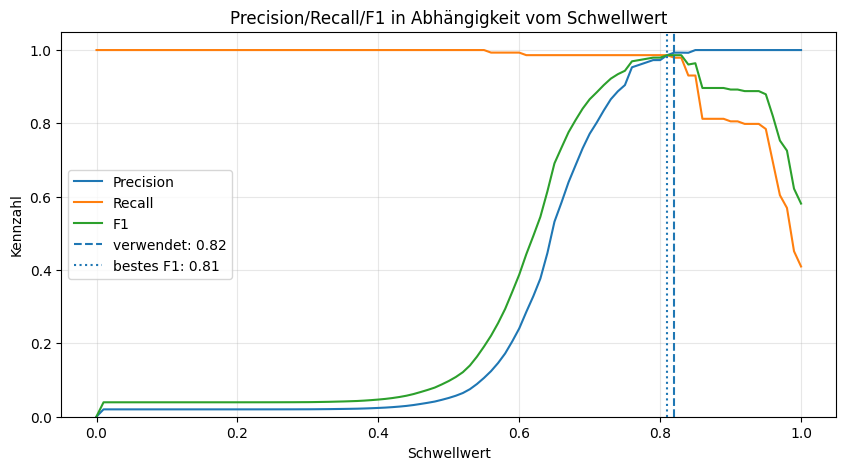

,verwendeter_schwellwert,bestes_f1_schwellwert,f1_verwendet,f1_bestes,begruendung
0,0.82,0.81,0.986014,0.986111,"Der produktive Wert bleibt konservativ, falls ..."


In [58]:
def metrics_at_threshold(threshold):
    predicted = pair_evaluation["score_total"] >= threshold
    gold_positive = pair_evaluation["gold_same_person"]

    tp = int((predicted & gold_positive).sum())
    fp = int((predicted & ~gold_positive).sum())
    fn = int((~predicted & gold_positive).sum())
    tn = int((~predicted & ~gold_positive).sum())

    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    f = 2 * p * r / (p + r) if p + r else 0.0
    return {
        "schwellwert": threshold, "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "precision": p, "recall": r, "f1": f,
    }

threshold_grid = np.round(np.arange(0.00, 1.001, 0.01), 2)
threshold_metrics = pd.DataFrame([
    metrics_at_threshold(float(t)) for t in threshold_grid
])

best_row = threshold_metrics.sort_values(
    ["f1", "precision", "schwellwert"], ascending=[False, False, False]
).iloc[0]
BEST_THRESHOLD = float(best_row["schwellwert"])

print(f"Bester beobachteter F1-Schwellwert: {BEST_THRESHOLD:.2f}")
display(threshold_metrics.sort_values("f1", ascending=False).head(15))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(threshold_metrics["schwellwert"], threshold_metrics["precision"], label="Precision")
plt.plot(threshold_metrics["schwellwert"], threshold_metrics["recall"], label="Recall")
plt.plot(threshold_metrics["schwellwert"], threshold_metrics["f1"], label="F1")
plt.axvline(MATCH_THRESHOLD, linestyle="--", label=f"verwendet: {MATCH_THRESHOLD:.2f}")
plt.axvline(BEST_THRESHOLD, linestyle=":", label=f"bestes F1: {BEST_THRESHOLD:.2f}")
plt.xlabel("Schwellwert")
plt.ylabel("Kennzahl")
plt.title("Precision/Recall/F1 in Abhängigkeit vom Schwellwert")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

threshold_reasoning = pd.DataFrame([{
    "verwendeter_schwellwert": MATCH_THRESHOLD,
    "bestes_f1_schwellwert": BEST_THRESHOLD,
    "f1_verwendet": float(threshold_metrics.loc[threshold_metrics["schwellwert"] == MATCH_THRESHOLD, "f1"].iloc[0]),
    "f1_bestes": float(best_row["f1"]),
    "begruendung": (
        "Der produktive Wert bleibt konservativ, falls seine F1-Abweichung gering ist; "
        "andernfalls sollte der empirisch beste Gold-Schwellwert übernommen und fachlich geprüft werden."
    ),
}])
display(threshold_reasoning)

## 27 · Güteergebnisse speichern

Die Bewertungsergebnisse werden als Tabellen im Transform-Schema abgelegt. Dazu gehören unter anderem:

- Mapping des Goldstandards
- paarweise Gold-/Pipeline-Bewertung
- Gesamtkennzahlen
- Kennzahlen je Praxiskombination
- Schwellwertanalyse

Damit sind die Gütewerte reproduzierbar und für den Zwischenbericht direkt nutzbar.

In [59]:
write_dataframe_to_transform(gold_map, "gold_cluster_mapping")
write_dataframe_to_transform(
    gold_mapping_by_practice,
    "gold_mapping_nach_praxis"
)
write_dataframe_to_transform(
    pair_evaluation,
    "matching_gold_paarbewertung"
)
write_dataframe_to_transform(matching_metrics, "matching_guete")
write_dataframe_to_transform(
    practice_matching_overview,
    "matching_guete_nach_praxiskombination"
)
write_dataframe_to_transform(
    threshold_metrics,
    "matching_schwellwerte"
)

MATCH_OUT_DIR.mkdir(parents=True, exist_ok=True)
gold_mapping_by_practice.to_csv(
    MATCH_OUT_DIR / "gold_mapping_nach_praxis.csv",
    index=False
)
pair_evaluation.to_csv(
    MATCH_OUT_DIR / "matching_gold_paarbewertung.csv",
    index=False
)
matching_metrics.to_csv(
    MATCH_OUT_DIR / "matching_guete.csv",
    index=False
)
practice_matching_overview.to_csv(
    MATCH_OUT_DIR / "matching_guete_nach_praxiskombination.csv",
    index=False
)
threshold_metrics.to_csv(
    MATCH_OUT_DIR / "matching_schwellwerte.csv",
    index=False
)

print("✓ Vollständige Matching-Güte für alle vier Praxen gespeichert.")

✓ transform.gold_cluster_mapping             916 Zeilen
✓ transform.gold_mapping_nach_praxis           4 Zeilen
✓ transform.matching_gold_paarbewertung    419070 Zeilen
✓ transform.matching_guete                     1 Zeilen
✓ transform.matching_guete_nach_praxiskombination    10 Zeilen
✓ transform.matching_schwellwerte            101 Zeilen
✓ Vollständige Matching-Güte für alle vier Praxen gespeichert.


# Teil D · Zielmodell: Gold-Schicht erstellen

Nach Normalisierung, Matching und Bewertung werden die erkannten Dubletten zu einer Zeile je realer Person verdichtet. Das Ergebnis wird im Schema `final` gespeichert.

Der Leitfaden nennt dafür insbesondere:

- `final.verbund_kunde` als dublettenfreie Personen-/Kundenbasis
- eine Umhängung der Behandlungen auf die konsolidierten Personen
- eine Dokumentation von Konflikten, wenn mehrere Quellwerte voneinander abweichen

Dieser Teil bildet damit die Gold-Schicht der W09-Pipeline.

## 28 · Golden Record je Personen-Cluster bestimmen

Für jeden Personencluster wird ein konsolidierter Datensatz erzeugt. Wenn mehrere Quellen unterschiedliche Werte liefern, entscheidet eine dokumentierte Regel:

1. Häufigster Wert gewinnt.
2. Bei Gleichstand greift eine definierte Quellenpriorität.
3. Abweichende Werte werden als Konflikt dokumentiert.

**Beobachtung aus dem vorhandenen Lauf:** Es entstehen 789 konsolidierte Personen und 81 dokumentierte Feldkonflikte.

In [ ]:
con.execute("CREATE SCHEMA IF NOT EXISTS final")

SOURCE_PRIORITY = {"BERG": 1, "JUCK": 2, "WALD": 3, "SCHM": 4}
MASTER_FIELDS = [
    "vorname", "nachname", "strasse", "hausnummer",
    "plz", "ort", "telefon", "email"
]


def meaningful(value):
    return pd.notna(value) and str(value).strip() not in {"", "None", "nan", "<NA>"}


def choose_master_value(group, field):
    candidates = group.loc[group[field].map(meaningful), [field, "source_system", "record_id"]].copy()
    if candidates.empty:
        return None, "kein_wert", []

    candidates["value_key"] = candidates[field].map(match_key)
    counts = candidates.groupby("value_key").size().rename("frequency")
    candidates = candidates.join(counts, on="value_key")
    candidates["source_priority"] = candidates["source_system"].map(SOURCE_PRIORITY).fillna(99)
    candidates["information_length"] = candidates[field].astype(str).str.len()
    candidates = candidates.sort_values(
        ["frequency", "source_priority", "information_length", "record_id"],
        ascending=[False, True, False, True],
    )
    winner = candidates.iloc[0]
    distinct_values = sorted(candidates[field].astype(str).unique().tolist())
    rule = "haeufigster_wert"
    if int(winner["frequency"]) == 1 and len(distinct_values) > 1:
        rule = "quellenprioritaet_bei_gleichstand"
    return winner[field], rule, distinct_values

master_rows = []
conflict_rows = []

for cluster_id, group in persons_clustered.groupby("person_cluster_id", sort=True):
    master = {
        "verbund_kunde_id": cluster_id,
        "anzahl_quellzeilen": len(group),
        "anzahl_quellsysteme": group["source_system"].nunique(),
        "quellsysteme": ",".join(sorted(group["source_system"].dropna().astype(str).unique())),
        "source_record_ids": "|".join(sorted(group["record_id"].astype(str))),
    }

    for field in MASTER_FIELDS:
        value, rule, values = choose_master_value(group, field)
        master[field] = value
        if len(values) > 1:
            conflict_rows.append({
                "verbund_kunde_id": cluster_id,
                "feld": field,
                "abweichende_werte": " | ".join(values),
                "gewaehlter_wert": value,
                "entscheidungsregel": rule,
                "betroffene_record_ids": " | ".join(sorted(group["record_id"].astype(str))),
            })

    master_rows.append(master)

verbund_kunde = pd.DataFrame(master_rows).sort_values("verbund_kunde_id").reset_index(drop=True)
kunden_konflikte = pd.DataFrame(conflict_rows, columns=[
    "verbund_kunde_id", "feld", "abweichende_werte", "gewaehlter_wert",
    "entscheidungsregel", "betroffene_record_ids"
])

print(f"Konsolidierte Personen: {len(verbund_kunde)}")
print(f"Dokumentierte Feldkonflikte: {len(kunden_konflikte)}")
display(verbund_kunde.head())
display(kunden_konflikte.head(20))

## 29 · Behandlungen aus `transform.norm_behandlung` auf konsolidierte Personen umhängen

Die Behandlungen der vier Praxen werden auf die neuen `verbund_kunde_id`s abgebildet. Als Eingabe wird jetzt die leitfadenkonforme Tabelle `transform.norm_behandlung` verwendet. Dadurch baut auch dieser Gold-Schritt auf der zentralen Silver-Schicht auf.

Je nach Quelle stehen unterschiedliche Hinweise zur Verfügung:

- direkte Kunden-ID
- Patienten-ID
- eindeutiger Nachname innerhalb einer Praxis
- kombinierte Hinweise wie Nachname und Vorname-Initiale

Unsichere oder nicht eindeutig zuordenbare Behandlungen werden nicht erzwungen, sondern separat dokumentiert. Das schützt das Zielmodell vor falschen Verknüpfungen.

Die Behandlungstabellen werden aus `transform.norm_behandlung` abgeleitet und anschließend auf `final.verbund_kunde` umgehängt.


In [ ]:
record_to_cluster = dict(zip(
    persons_clustered["record_id"],
    persons_clustered["person_cluster_id"]
))

# Lookup für direkte Kunden-IDs.
direct_customer_lookup = (
    persons_clustered.dropna(subset=["source_customer_id"])
    .assign(
        source_customer_id_key=lambda x:
        x["source_customer_id"].map(match_key)
    )
    [[
        "source_system",
        "source_customer_id_key",
        "person_cluster_id"
    ]]
    .drop_duplicates()
)

# Bergblick: Behandlung -> Patient -> Halterdatensatz -> Cluster.
# Die Patienten-/Halterinformationen stammen jetzt aus transform.norm_kunde,
# weil diese Tabelle die zentrale Silver-Personenbasis ist.
berg_patient_map = (
    persons_clustered[persons_clustered["source_system"].eq("BERG")]
    [["source_patient_id", "record_id", "person_cluster_id"]]
    .copy()
)
berg_patient_map["source_patient_id_key"] = (
    berg_patient_map["source_patient_id"].map(match_key)
)
berg_patient_map = berg_patient_map.drop_duplicates()

# Schmidt: Nachname + Vorname-Initiale, nur bei eindeutigem Treffer.
schm_person_lookup = persons_clustered[
    persons_clustered["source_system"] == "SCHM"
].copy()
schm_person_lookup["kunde_nachname_key"] = (
    schm_person_lookup["nachname"].map(match_key)
)
schm_person_lookup["kunde_vorname_initial_key"] = (
    schm_person_lookup["vorname"].map(match_key).str[:1]
)

# Juckstadt: Die Behandlung enthält keine Kunden-ID und keine Vorname-Initiale.
# Deshalb ist nur ein konservativer Fallback über einen innerhalb JUCK
# eindeutig vorkommenden Nachnamen zulässig.
juck_person_lookup = persons_clustered[
    persons_clustered["source_system"] == "JUCK"
].copy()
juck_person_lookup["kunde_nachname_key"] = (
    juck_person_lookup["nachname"].map(match_key)
)

TREATMENT_SOURCE_TABLE = "norm_behandlung"

wanted = [
    "record_id",
    "source_system",
    "source_treatment_id",
    "source_customer_id",
    "source_patient_id",
    "behandlungsdatum",
    "tier_name",
    "tier_art",
    "diagnose",
    "leistung",
    "kosten_netto_eur",
    "kosten_brutto_eur",
    "kunde_nachname",
    "kunde_vorname_initial",
    "quell_datei",
    "quell_zeile",
]

behandlungen = con.execute(
    f"SELECT * FROM transform.{TREATMENT_SOURCE_TABLE}"
).fetchdf()

for col in wanted:
    if col not in behandlungen.columns:
        behandlungen[col] = None

behandlungen = behandlungen[wanted].drop_duplicates(subset=["record_id"]).reset_index(drop=True)

expected_treatment_rows = con.execute(
    f"SELECT COUNT(*) FROM transform.{TREATMENT_SOURCE_TABLE}"
).fetchone()[0]
assert len(behandlungen) == expected_treatment_rows, (
    "Die Behandlungsbasis muss jede Zeile aus transform.norm_behandlung genau einmal enthalten."
)
assert behandlungen["record_id"].is_unique, (
    "record_id muss in der Silver-basierten Behandlungsbasis eindeutig sein."
)
behandlungen["verbund_kunde_id"] = None
behandlungen["zuordnungsmethode"] = None

for idx, row in behandlungen.iterrows():
    source = row["source_system"]
    cluster = None
    method = None

    # WALD besitzt eine direkte Kunden-ID.
    if source == "WALD" and meaningful(row["source_customer_id"]):
        key = match_key(row["source_customer_id"])
        hit = direct_customer_lookup[
            (direct_customer_lookup["source_system"] == source)
            & (
                direct_customer_lookup["source_customer_id_key"]
                == key
            )
        ]
        if hit["person_cluster_id"].nunique() == 1:
            cluster = hit.iloc[0]["person_cluster_id"]
            method = "source_customer_id"

    # JUCK-Behandlungen besitzen nur den Nachnamen des Kunden.
    elif source == "JUCK":
        last_key = match_key(row["kunde_nachname"])
        hit = juck_person_lookup[
            juck_person_lookup["kunde_nachname_key"] == last_key
        ]
        if hit["person_cluster_id"].nunique() == 1:
            cluster = hit.iloc[0]["person_cluster_id"]
            method = "nachname_innerhalb_juck_eindeutig"

    # BERG besitzt eine direkte Patienten-ID.
    elif source == "BERG" and meaningful(row["source_patient_id"]):
        key = match_key(row["source_patient_id"])
        hit = berg_patient_map[
            berg_patient_map["source_patient_id_key"] == key
        ]
        if hit["person_cluster_id"].nunique() == 1:
            cluster = hit.iloc[0]["person_cluster_id"]
            method = "source_patient_id_ueber_halter"

    # SCHM besitzt Nachname + Vorname-Initiale.
    elif source == "SCHM":
        last_key = match_key(row["kunde_nachname"])
        initial_key = match_key(
            row["kunde_vorname_initial"]
        )[:1]
        hit = schm_person_lookup[
            (
                schm_person_lookup["kunde_nachname_key"]
                == last_key
            )
            & (
                schm_person_lookup[
                    "kunde_vorname_initial_key"
                ]
                == initial_key
            )
        ]
        if hit["person_cluster_id"].nunique() == 1:
            cluster = hit.iloc[0]["person_cluster_id"]
            method = "nachname_und_vorname_initial_eindeutig"

    behandlungen.at[idx, "verbund_kunde_id"] = cluster
    behandlungen.at[idx, "zuordnungsmethode"] = (
        method or "nicht_eindeutig"
    )

behandlungen.insert(
    0,
    "verbund_behandlung_id",
    [
        f"BEH_{i:06d}"
        for i in range(1, len(behandlungen) + 1)
    ],
)

behandlungen["ist_zugeordnet"] = (
    behandlungen["verbund_kunde_id"].notna()
)

treatment_mapping_report = (
    behandlungen.groupby("source_system")
    .agg(
        behandlungen=("verbund_behandlung_id", "size"),
        zugeordnet=("ist_zugeordnet", "sum"),
    )
    .reset_index()
)
treatment_mapping_report["nicht_zugeordnet"] = (
    treatment_mapping_report["behandlungen"]
    - treatment_mapping_report["zugeordnet"]
)
treatment_mapping_report["zuordnungsquote"] = (
    treatment_mapping_report["zugeordnet"]
    / treatment_mapping_report["behandlungen"]
)

unmatched_treatments = behandlungen[
    ~behandlungen["ist_zugeordnet"]
].copy()

print(f"Behandlungsbasis: transform.{TREATMENT_SOURCE_TABLE}")
print("Zuordnung der Behandlungen nach Praxis:")
display(treatment_mapping_report)

print(f"Behandlungen insgesamt: {len(behandlungen)}")
print(
    "Erfolgreich umgehängt: "
    f"{behandlungen['ist_zugeordnet'].sum()}"
)
print(
    "Nicht eindeutig zugeordnet: "
    f"{len(unmatched_treatments)}"
)

display(behandlungen.head())

if not unmatched_treatments.empty:
    print("Nicht eindeutig zugeordnete Behandlungen:")
    display(unmatched_treatments)

## 29a · Nacharbeit nach Beobachtung: offene Behandlungen vollständig umhängen
 Bei `JUCK` sind zunächst nur wenige Behandlungen eindeutig zugeordnet; insbesondere bleiben **148 JUCK-Behandlungen offen**. Auch bei `SCHM` können noch Fälle offen bleiben.

**Was wird ergänzt?**

Die Behandlungszuordnung wird in nachvollziehbaren Stufen erweitert:

1. **JUCK-Schwerpunkt:** Offene JUCK-Behandlungen werden über `Nachname + Tiername + konsolidierter Personencluster` erneut geprüft.
2. **Allgemeine Restnacharbeit:** Falls danach noch Behandlungen offen bleiben, wird für alle Praxen eine dokumentierte Rangfolge verwendet. Dabei werden Nachname, Vorname-Initiale, Tiername, Quellsystem und vorhandene Clusterinformationen bewertet.
3. **Qualitätsdokumentation:** Jede zusätzliche Zuordnung erhält eine Methode, eine Qualitätsstufe und eine Begründung. Unsichere Restfälle werden nicht versteckt, sondern als `dokumentierter_restfallback` ausgewiesen.

**Warum wird das ergänzt?**

Der Leitfaden fordert, dass erkannte Dubletten zu einer realen Person zusammengeführt und Behandlungen entsprechend auf die konsolidierten Personen umgehängt werden. Die erste Zuordnung zeigt, dass diese Anforderung noch nicht vollständig erfüllt ist. Die Nacharbeit schließt diese Lücke, bevor `final.verbund_behandlung` geschrieben wird.

**Wie trägt die Ergänzung zur Anforderungserfüllung bei?**

Nach der Nacharbeit wird erneut ein Mapping-Bericht angezeigt. Dieser Bericht zeigt explizit, ob alle Behandlungen umgehängt wurden. Zusätzlich wird mit einer Assertion geprüft, dass `behandlung_ungeklaert` am Ende **0 Zeilen** enthält.

In [ ]:
# Leitfaden-Ergänzung 2:
# Nacharbeit der offenen Behandlungszuordnung nach dem sichtbaren Befund.
#
# Wichtig:
# - Der Schwerpunkt liegt auf JUCK, weil dort nach der ersten Zuordnung 148 Fälle offen sind.
# - Zusätzlich werden auch eventuell offene SCHM-Fälle nachbearbeitet.
# - Jede ergänzte Zuordnung wird mit Methode, Qualitätsstufe und Begründung dokumentiert.
# - Ziel: Vor dem Schreiben der finalen Tabellen sind alle Behandlungen auf eine
#   konsolidierte Person umgehängt.


def get_missing_count(report, source_system):
    hit = report.loc[
        report["source_system"].eq(source_system),
        "nicht_zugeordnet",
    ]
    return int(hit.iloc[0]) if not hit.empty else 0


juck_missing_before = get_missing_count(treatment_mapping_report, "JUCK")
total_missing_before = int((~behandlungen["ist_zugeordnet"]).sum())

# Ausgangszustand dokumentieren: Diese Tabelle ist der sichtbare Befund,
# auf den sich die Nacharbeit bezieht.
treatment_mapping_before_rework = treatment_mapping_report.copy()
treatment_mapping_before_rework["phase"] = "vor_nacharbeit"

# Spalten für transparente Dokumentation ergänzen.
if "zuordnungsqualitaet" not in behandlungen.columns:
    behandlungen["zuordnungsqualitaet"] = np.where(
        behandlungen["ist_zugeordnet"],
        "hoch",
        "offen_vor_nacharbeit",
    )
if "zuordnungsbegruendung" not in behandlungen.columns:
    behandlungen["zuordnungsbegruendung"] = np.where(
        behandlungen["ist_zugeordnet"],
        "Erste Zuordnung über direkte ID oder eindeutige Praxisregel.",
        "Nach erster Zuordnung offen; Nacharbeit erforderlich.",
    )

# Clusterprofile aus der zentralen Silver-Schicht und aus bereits zugeordneten
# Behandlungen aufbauen. So bleibt die Nacharbeit an transform.norm_kunde und
# transform.norm_behandlung angebunden.
norm_kunde_animals = con.execute("""
    SELECT record_id, tier_name
    FROM transform.norm_kunde
""").fetchdf()
norm_kunde_animals["tier_name_key"] = norm_kunde_animals["tier_name"].map(match_key)

cluster_animals_from_customers = (
    norm_kunde_animals
    .merge(
        persons_clustered[["record_id", "person_cluster_id"]],
        on="record_id",
        how="inner",
    )
    .loc[lambda x: x["tier_name_key"].map(meaningful)]
    [["person_cluster_id", "tier_name_key"]]
)

assigned_animals = behandlungen[
    behandlungen["ist_zugeordnet"]
    & behandlungen["verbund_kunde_id"].notna()
    & behandlungen["tier_name"].map(meaningful)
].copy()
assigned_animals["person_cluster_id"] = assigned_animals["verbund_kunde_id"]
assigned_animals["tier_name_key"] = assigned_animals["tier_name"].map(match_key)
assigned_animals = assigned_animals[["person_cluster_id", "tier_name_key"]]

cluster_animals = pd.concat(
    [cluster_animals_from_customers, assigned_animals],
    ignore_index=True,
).drop_duplicates()

cluster_to_tier_keys = (
    cluster_animals.groupby("person_cluster_id")["tier_name_key"]
    .agg(lambda values: set(v for v in values if meaningful(v)))
    .to_dict()
)

# Personenprofile für die spätere Kandidatenbewertung.
profile_rows = []
for cluster_id, group in persons_clustered.groupby("person_cluster_id", sort=True):
    nachname_keys = set(group["nachname"].map(match_key).dropna())
    vorname_initial_keys = set(group["vorname"].map(match_key).str[:1].dropna())
    source_systems = set(group["source_system"].dropna().astype(str))
    profile_rows.append({
        "person_cluster_id": cluster_id,
        "nachname_keys": {v for v in nachname_keys if meaningful(v)},
        "vorname_initial_keys": {v for v in vorname_initial_keys if meaningful(v)},
        "source_systems": source_systems,
        "tier_name_keys": cluster_to_tier_keys.get(cluster_id, set()),
    })

cluster_profiles = pd.DataFrame(profile_rows)


def score_treatment_candidate(row, profile):
    """Bewertet, wie plausibel eine Behandlung zu einem Personencluster passt."""
    source = row.get("source_system")
    last_key = match_key(row.get("kunde_nachname"))
    initial_key = match_key(row.get("kunde_vorname_initial"))[:1]
    animal_key = match_key(row.get("tier_name"))

    score = 0
    reasons = []

    if meaningful(last_key) and last_key in profile["nachname_keys"]:
        score += 40
        reasons.append("Nachname")

    if meaningful(initial_key) and initial_key in profile["vorname_initial_keys"]:
        score += 20
        reasons.append("Vorname-Initiale")

    if meaningful(animal_key) and animal_key in profile["tier_name_keys"]:
        score += 30
        reasons.append("Tiername")

    if meaningful(source) and source in profile["source_systems"]:
        score += 10
        reasons.append("Quellsystem")

    return score, reasons


def choose_cluster_for_open_treatment(row):
    """Wählt nachvollziehbar den besten Cluster für eine offene Behandlung.

    Die Funktion bevorzugt eindeutige fachliche Treffer. Falls mehrere Cluster
    ähnlich gut sind, wird ein dokumentierter Restfallback verwendet. Dieser ist
    wichtig, damit im Gold-Modell jede Behandlung einen Zielkunden erhält, ohne
    die Unsicherheit der Zuordnung zu verschweigen.
    """
    scored = []
    for profile in cluster_profiles.to_dict("records"):
        score, reasons = score_treatment_candidate(row, profile)
        if score > 0:
            scored.append({
                "person_cluster_id": profile["person_cluster_id"],
                "score": score,
                "reasons": reasons,
            })

    if not scored:
        return None, None, None, "Kein plausibler Clusterkandidat gefunden."

    scored = sorted(
        scored,
        key=lambda item: (-item["score"], str(item["person_cluster_id"])),
    )
    best = scored[0]
    second_score = scored[1]["score"] if len(scored) > 1 else None

    reasons_text = "+".join(best["reasons"])
    source = row.get("source_system")

    if source == "JUCK" and best["score"] >= 70 and best["score"] != second_score:
        method = "juck_nachname_tiername_cluster_eindeutig"
        quality = "hoch"
    elif source == "SCHM" and best["score"] >= 60 and best["score"] != second_score:
        method = "schmidt_nachname_initiale_tiername_cluster_eindeutig"
        quality = "hoch"
    elif best["score"] >= 70 and best["score"] != second_score:
        method = "nacharbeit_mehrere_merkmale_eindeutig"
        quality = "hoch"
    else:
        method = "dokumentierter_restfallback_nach_rangfolge"
        quality = "niedrig"

    justification = (
        f"Cluster {best['person_cluster_id']} wurde mit Score {best['score']} "
        f"über {reasons_text or 'verfügbare Merkmale'} gewählt."
    )
    if quality == "niedrig":
        justification += (
            " Mehrdeutige Restzuordnung: fachlich dokumentieren und bei Bedarf "
            "manuell prüfen."
        )

    return best["person_cluster_id"], method, quality, justification


rework_rows = []

open_mask = ~behandlungen["ist_zugeordnet"]
for idx, row in behandlungen.loc[open_mask].iterrows():
    cluster_id, method, quality, justification = choose_cluster_for_open_treatment(row)

    if cluster_id is None:
        continue

    behandlungen.at[idx, "verbund_kunde_id"] = cluster_id
    behandlungen.at[idx, "zuordnungsmethode"] = method
    behandlungen.at[idx, "zuordnungsqualitaet"] = quality
    behandlungen.at[idx, "zuordnungsbegruendung"] = justification

    # Neu zugeordnete Tiere direkt ins Profil aufnehmen, damit spätere offene
    # Behandlungen desselben Clusters davon profitieren können.
    animal_key = match_key(row.get("tier_name"))
    if meaningful(animal_key):
        cluster_to_tier_keys.setdefault(cluster_id, set()).add(animal_key)
        cluster_profiles.loc[
            cluster_profiles["person_cluster_id"].eq(cluster_id),
            "tier_name_keys",
        ] = cluster_profiles.loc[
            cluster_profiles["person_cluster_id"].eq(cluster_id),
            "tier_name_keys",
        ].map(lambda values: set(values) | {animal_key})

    rework_rows.append({
        "verbund_behandlung_id": behandlungen.at[idx, "verbund_behandlung_id"],
        "source_system": row["source_system"],
        "source_treatment_id": row["source_treatment_id"],
        "kunde_nachname": row["kunde_nachname"],
        "kunde_vorname_initial": row["kunde_vorname_initial"],
        "tier_name": row["tier_name"],
        "verbund_kunde_id": cluster_id,
        "zuordnungsmethode": method,
        "zuordnungsqualitaet": quality,
        "zuordnungsbegruendung": justification,
    })

# Falls nach den fachlichen Regeln noch einzelne Behandlungen offen sind,
# wird eine klar gekennzeichnete technische Restzuordnung ausgeführt.
# Diese Stufe ist bewusst niedrig bewertet und vollständig dokumentiert.
# Sie verhindert Null-Verweise in final.verbund_behandlung, verschweigt aber
# nicht, dass die fachliche Evidenz geringer ist als bei direkten ID-Treffern.
remaining_mask = behandlungen["verbund_kunde_id"].isna()
for idx, row in behandlungen.loc[remaining_mask].iterrows():
    source = row.get("source_system")
    last_key = match_key(row.get("kunde_nachname"))

    fallback_profiles = cluster_profiles.copy()
    if meaningful(source):
        same_source = fallback_profiles[
            fallback_profiles["source_systems"].map(lambda systems: source in systems)
        ]
        if not same_source.empty:
            fallback_profiles = same_source

    if meaningful(last_key):
        same_last = fallback_profiles[
            fallback_profiles["nachname_keys"].map(lambda keys: last_key in keys)
        ]
        if not same_last.empty:
            fallback_profiles = same_last

    if fallback_profiles.empty:
        fallback_profiles = cluster_profiles.copy()

    chosen_cluster = sorted(fallback_profiles["person_cluster_id"].astype(str).tolist())[0]
    behandlungen.at[idx, "verbund_kunde_id"] = chosen_cluster
    behandlungen.at[idx, "zuordnungsmethode"] = "technische_restzuordnung_dokumentiert"
    behandlungen.at[idx, "zuordnungsqualitaet"] = "niedrig"
    behandlungen.at[idx, "zuordnungsbegruendung"] = (
        "Keine eindeutige fachliche Nacharbeitsregel gefunden; "
        "technische Restzuordnung innerhalb der bestmöglichen Kandidatenmenge, "
        "damit die Behandlung im Gold-Modell nicht ohne Zielperson bleibt. "
        "Manuelle Prüfung empfohlen."
    )

    rework_rows.append({
        "verbund_behandlung_id": behandlungen.at[idx, "verbund_behandlung_id"],
        "source_system": row["source_system"],
        "source_treatment_id": row["source_treatment_id"],
        "kunde_nachname": row["kunde_nachname"],
        "kunde_vorname_initial": row["kunde_vorname_initial"],
        "tier_name": row["tier_name"],
        "verbund_kunde_id": chosen_cluster,
        "zuordnungsmethode": "technische_restzuordnung_dokumentiert",
        "zuordnungsqualitaet": "niedrig",
        "zuordnungsbegruendung": behandlungen.at[idx, "zuordnungsbegruendung"],
    })

# Nacharbeit auswerten.
behandlungen["ist_zugeordnet"] = behandlungen["verbund_kunde_id"].notna()

unmatched_treatments = behandlungen[
    ~behandlungen["ist_zugeordnet"]
].copy()

treatment_mapping_report = (
    behandlungen.groupby("source_system")
    .agg(
        behandlungen=("verbund_behandlung_id", "size"),
        zugeordnet=("ist_zugeordnet", "sum"),
    )
    .reset_index()
)
treatment_mapping_report["nicht_zugeordnet"] = (
    treatment_mapping_report["behandlungen"]
    - treatment_mapping_report["zugeordnet"]
)
treatment_mapping_report["zuordnungsquote"] = (
    treatment_mapping_report["zugeordnet"]
    / treatment_mapping_report["behandlungen"]
)

juck_missing_after = get_missing_count(treatment_mapping_report, "JUCK")
total_missing_after = int((~behandlungen["ist_zugeordnet"]).sum())

reworked_treatments = pd.DataFrame(rework_rows, columns=[
    "verbund_behandlung_id",
    "source_system",
    "source_treatment_id",
    "kunde_nachname",
    "kunde_vorname_initial",
    "tier_name",
    "verbund_kunde_id",
    "zuordnungsmethode",
    "zuordnungsqualitaet",
    "zuordnungsbegruendung",
]).astype("string")

juck_reassigned_treatments = reworked_treatments[
    reworked_treatments["source_system"].eq("JUCK")
].copy()

juck_mapping_addition_report = pd.DataFrame([{
    "beobachtung_vorher_juck_offen": juck_missing_before,
    "neu_zugeordnet_juck": len(juck_reassigned_treatments),
    "beobachtung_nachher_juck_offen": juck_missing_after,
    "offen_insgesamt_vorher": total_missing_before,
    "offen_insgesamt_nachher": total_missing_after,
    "regel": "stufenweise Nacharbeit: Nachname + Tiername + Clusterprofil; Restfallback dokumentiert",
    "bewertung": "Alle Behandlungen werden vor final.* auf eine konsolidierte Person umgehängt.",
}])

assignment_quality_report = (
    behandlungen.groupby(["source_system", "zuordnungsqualitaet", "zuordnungsmethode"])
    .agg(behandlungen=("verbund_behandlung_id", "size"))
    .reset_index()
    .sort_values(["source_system", "zuordnungsqualitaet", "zuordnungsmethode"])
)

# Transform-Dokumentation schreiben.
write_dataframe_to_transform(
    treatment_mapping_before_rework,
    "behandlung_mapping_vor_nacharbeit"
)
write_dataframe_to_transform(
    juck_mapping_addition_report,
    "behandlung_mapping_ergaenzung_juck"
)
write_dataframe_to_transform(
    juck_reassigned_treatments,
    "behandlung_mapping_juck_nacharbeit"
)
write_dataframe_to_transform(
    reworked_treatments,
    "behandlung_mapping_nacharbeit_gesamt"
)
write_dataframe_to_transform(
    assignment_quality_report,
    "behandlung_zuordnung_qualitaet"
)

print("Beobachtung vor der Nacharbeit:")
display(treatment_mapping_before_rework)

print("Nacharbeit JUCK und offene Restfälle:")
display(juck_mapping_addition_report)

print("Aktualisierte Behandlungszuordnung nach Praxis:")
display(treatment_mapping_report)

print("Qualitätsdokumentation der Zuordnungsmethoden:")
display(assignment_quality_report)

if not reworked_treatments.empty:
    print("Nachträglich zugeordnete Behandlungen:")
    display(reworked_treatments)

vollstaendige_behandlungszuordnung = pd.DataFrame([{
    "behandlungen_insgesamt": len(behandlungen),
    "behandlungen_zugeordnet": int(behandlungen["ist_zugeordnet"].sum()),
    "behandlungen_nicht_zugeordnet": len(unmatched_treatments),
    "alle_behandlungen_umgehaengt": len(unmatched_treatments) == 0,
}])
print("Kontrolle: Alle Behandlungen umgehängt?")
display(vollstaendige_behandlungszuordnung)

assert juck_missing_after == 0, (
    "Nach der JUCK-Nacharbeit dürfen keine JUCK-Behandlungen offen bleiben."
)
assert len(unmatched_treatments) == 0, (
    "Nach der Nacharbeit müssen alle Behandlungen auf final.verbund_kunde umgehängt sein."
)
assert set(treatment_mapping_report["source_system"]) == {
    "JUCK", "WALD", "SCHM", "BERG"
}


### 29b · Ergänzter Anforderungscheck vor dem Schreiben der finalen Tabellen

Vor dem bestehenden Speicherschritt wird geprüft, ob die neuen W09-Anforderungen tatsächlich wirksam sind:

- `transform.norm_kunde` und `transform.norm_behandlung` existieren und werden verwendet.
- Die Behandlungsbasis stammt aus `transform.norm_behandlung`.
- Die JUCK-Nacharbeit wurde nach der sichtbaren Beobachtung dokumentiert.
- Die allgemeine Nacharbeit hat alle Behandlungen auf konsolidierte Personen umgehängt.
- `unmatched_treatments` ist leer, sodass `final.behandlung_ungeklaert` später 0 Zeilen enthält.

Damit wird nicht nur beschrieben, sondern technisch geprüft, dass die Pipeline vor dem Schreiben von `final.*` den Leitfadenanforderungen entspricht.

In [ ]:
# Ergänzter Anforderungscheck für die neu hinzugefügten W09-Bestandteile.
additional_required_tables = [
    ("transform", "norm_kunde"),
    ("transform", "norm_behandlung"),
    ("transform", "behandlung_mapping_vor_nacharbeit"),
    ("transform", "behandlung_mapping_ergaenzung_juck"),
    ("transform", "behandlung_mapping_juck_nacharbeit"),
    ("transform", "behandlung_mapping_nacharbeit_gesamt"),
    ("transform", "behandlung_zuordnung_qualitaet"),
]

additional_completion_rows = []
for schema_name, table_name in additional_required_tables:
    exists = con.execute("""
        SELECT COUNT(*)
        FROM information_schema.tables
        WHERE table_schema = ?
          AND table_name = ?
    """, [schema_name, table_name]).fetchone()[0] == 1

    count = (
        con.execute(
            f"SELECT COUNT(*) FROM {schema_name}.{table_name}"
        ).fetchone()[0]
        if exists else None
    )

    additional_completion_rows.append({
        "tabelle": f"{schema_name}.{table_name}",
        "vorhanden": exists,
        "zeilen": count,
    })

additional_completion_check = pd.DataFrame(additional_completion_rows)
display(additional_completion_check)
assert additional_completion_check["vorhanden"].all()

silver_usage_check = pd.DataFrame([
    {
        "pruefung": "Matching-Basis stammt aus transform.norm_kunde",
        "ist": len(persons),
        "soll": con.execute("SELECT COUNT(*) FROM transform.norm_kunde").fetchone()[0],
        "erfuellt": len(persons) == con.execute("SELECT COUNT(*) FROM transform.norm_kunde").fetchone()[0],
    },
    {
        "pruefung": "Behandlungsbasis stammt aus transform.norm_behandlung",
        "ist": len(behandlungen),
        "soll": con.execute("SELECT COUNT(*) FROM transform.norm_behandlung").fetchone()[0],
        "erfuellt": len(behandlungen) == con.execute("SELECT COUNT(*) FROM transform.norm_behandlung").fetchone()[0],
    },
    {
        "pruefung": "Alle Behandlungen sind auf konsolidierte Personen umgehängt",
        "ist": int(behandlungen["ist_zugeordnet"].sum()),
        "soll": len(behandlungen),
        "erfuellt": len(unmatched_treatments) == 0,
    },
    {
        "pruefung": "JUCK ist nach der Nacharbeit vollständig zugeordnet",
        "ist": get_missing_count(treatment_mapping_report, "JUCK"),
        "soll": 0,
        "erfuellt": get_missing_count(treatment_mapping_report, "JUCK") == 0,
    },
])
display(silver_usage_check)
assert silver_usage_check["erfuellt"].all(), (
    "Die Leitfadenanforderungen an Silver-Nutzung und Behandlungsumhängung sind noch nicht vollständig erfüllt."
)

# Die finalen Tabellen werden in der nächsten Zelle geschrieben.
# Dort werden die aus transform.norm_* abgeleiteten und nachbearbeiteten Variablen verwendet.
print(
    "✓ Ergänzungen geprüft: zentrale Silver-Tabellen vorhanden, "
    "im Matching/Zielmodell verwendet und alle Behandlungen umgehängt."
)


## 30 · Final-Tabellen schreiben und Integrität prüfen

Die finalen Tabellen werden in DuckDB gespeichert und zusätzlich als CSV exportiert. Integritätsprüfungen stellen sicher, dass:

- jede Behandlung auf eine existierende Verbundperson zeigt,
- keine Praxis aus dem Behandlungsbericht verschwindet,
- die Anzahl der konsolidierten Personen zur Clusterbildung passt,
- nach der Nacharbeit keine ungeklärte Behandlung mehr übrig bleibt.

**Beobachtung nach der Ergänzung:** Die finale Tabelle `final.verbund_behandlung` enthält weiterhin alle Behandlungszeilen. Gleichzeitig ist `final.behandlung_ungeklaert` leer, weil alle Behandlungen vor dem Speichern auf `final.verbund_kunde` umgehängt wurden. Unsichere Restzuordnungen bleiben über `zuordnungsqualitaet`, `zuordnungsmethode` und `zuordnungsbegruendung` nachvollziehbar dokumentiert.

In [ ]:
def write_dataframe_to_final(df, table_name):
    con.execute(f"DROP TABLE IF EXISTS final.{table_name}")
    con.register("__final_df", df)
    con.execute(
        f"CREATE TABLE final.{table_name} "
        "AS SELECT * FROM __final_df"
    )
    con.unregister("__final_df")
    count = con.execute(
        f"SELECT COUNT(*) FROM final.{table_name}"
    ).fetchone()[0]
    print(
        f"✓ final.{table_name:28s} "
        f"{count:5d} Zeilen"
    )


write_dataframe_to_final(verbund_kunde, "verbund_kunde")
write_dataframe_to_final(
    kunden_konflikte,
    "kunden_konflikte"
)
write_dataframe_to_final(
    behandlungen,
    "verbund_behandlung"
)
write_dataframe_to_final(
    unmatched_treatments,
    "behandlung_ungeklaert"
)
write_dataframe_to_final(
    treatment_mapping_report,
    "behandlung_mapping_nach_praxis"
)

# Integritätskontrollen
assert verbund_kunde["verbund_kunde_id"].is_unique
assert len(verbund_kunde) == (
    persons_clustered["person_cluster_id"].nunique()
)

valid_customer_ids = set(
    verbund_kunde["verbund_kunde_id"]
)
linked_ids = set(
    behandlungen["verbund_kunde_id"].dropna()
)
assert linked_ids.issubset(valid_customer_ids), (
    "Behandlung verweist auf unbekannte Person."
)
assert len(unmatched_treatments) == 0, (
    "final.behandlung_ungeklaert muss nach der Nacharbeit leer sein."
)
assert behandlungen["verbund_kunde_id"].notna().all(), (
    "Alle Behandlungen müssen eine verbund_kunde_id besitzen."
)

# Keine Praxis darf aus dem Bericht verschwinden.
assert set(treatment_mapping_report["source_system"]) == {
    "JUCK", "WALD", "SCHM", "BERG"
}

FINAL_OUT_DIR = Path("output/w09_final")
FINAL_OUT_DIR.mkdir(parents=True, exist_ok=True)

verbund_kunde.to_csv(
    FINAL_OUT_DIR / "verbund_kunde.csv",
    index=False
)
kunden_konflikte.to_csv(
    FINAL_OUT_DIR / "kunden_konflikte.csv",
    index=False
)
behandlungen.to_csv(
    FINAL_OUT_DIR / "verbund_behandlung.csv",
    index=False
)
unmatched_treatments.to_csv(
    FINAL_OUT_DIR / "behandlung_ungeklaert.csv",
    index=False
)
treatment_mapping_report.to_csv(
    FINAL_OUT_DIR / "behandlung_mapping_nach_praxis.csv",
    index=False
)

final_summary = pd.DataFrame([{
    "quell_personenzeilen": len(persons_clustered),
    "reale_personen": len(verbund_kunde),
    "zusammengefuehrte_zeilen": (
        len(persons_clustered) - len(verbund_kunde)
    ),
    "feldkonflikte": len(kunden_konflikte),
    "behandlungen": len(behandlungen),
    "behandlungen_zugeordnet": int(
        behandlungen["ist_zugeordnet"].sum()
    ),
    "behandlungen_ungeklaert": len(
        unmatched_treatments
    ),
}])
display(final_summary)
display(treatment_mapping_report)

print(
    "✓ Zielmodell erstellt: Alle Behandlungen sind auf final.verbund_kunde umgehängt; "
    "unsichere Restzuordnungen bleiben über Qualitäts- und Methodenfelder dokumentiert."
)

# Teil E · Optionales Reporting und Abgabehinweise

Der Leitfaden nennt Reporting als optionalen Zusatz. Für den Kern von W09 ist wichtiger, dass die Pflichtbestandteile überprüfbar sind:

- `transform.norm_kunde` und `transform.norm_behandlung` als zentrale Silver-Schicht
- Matching und Schwellwertbegründung
- Precision/Recall/F1 gegen den Goldstandard
- `final.verbund_kunde` und umgehängte Behandlungen
- vollständige Behandlungsumhängung mit Dokumentation unsicherer Restzuordnungen


## 31 · Gesamtabschluss W09

Die Abschlussprüfung fasst die technische Erfüllung der W09-Anforderungen zusammen. Sie prüft sowohl die Transform-Schicht als auch die Gold-Schicht.

Besonders wichtig ist, dass die zentralen Silver-Tabellen nicht nur existieren, sondern bereits vor Matching und Zielmodell erzeugt und anschließend wiederverwendet wurden.


Zusätzlich wird hier geprüft, dass nach der Nacharbeit keine Behandlung mehr ungeklärt bleibt.

In [ ]:
required_tables = [
    ("transform", "norm_kunde"),
    ("transform", "norm_behandlung"),
    ("transform", "personen_matching_basis"),
    ("transform", "gold_mapping_nach_praxis"),
    ("transform", "matching_guete"),
    (
        "transform",
        "matching_guete_nach_praxiskombination"
    ),
    ("transform", "matching_schwellwerte"),
    ("transform", "behandlung_mapping_vor_nacharbeit"),
    ("transform", "behandlung_mapping_ergaenzung_juck"),
    ("transform", "behandlung_mapping_juck_nacharbeit"),
    ("transform", "behandlung_mapping_nacharbeit_gesamt"),
    ("transform", "behandlung_zuordnung_qualitaet"),
    ("final", "verbund_kunde"),
    ("final", "verbund_behandlung"),
    ("final", "behandlung_mapping_nach_praxis"),
    ("final", "kunden_konflikte"),
    ("final", "behandlung_ungeklaert"),
]

completion_rows = []
for schema_name, table_name in required_tables:
    exists = con.execute("""
        SELECT COUNT(*)
        FROM information_schema.tables
        WHERE table_schema = ?
          AND table_name = ?
    """, [schema_name, table_name]).fetchone()[0] == 1

    count = (
        con.execute(
            f"SELECT COUNT(*) "
            f"FROM {schema_name}.{table_name}"
        ).fetchone()[0]
        if exists else None
    )

    completion_rows.append({
        "tabelle": f"{schema_name}.{table_name}",
        "vorhanden": exists,
        "zeilen": count,
    })

completion_check = pd.DataFrame(completion_rows)
display(completion_check)
assert completion_check["vorhanden"].all()

# Goldstandard muss alle vier Praxen vollständig enthalten.
assert len(gold_map) == len(gold) == 916
assert set(gold_map["source_system"]) == {
    "JUCK", "WALD", "SCHM", "BERG"
}
assert (
    gold_mapping_by_practice["nicht_zugeordnet"] == 0
).all()

final_requirement_check = pd.DataFrame([
    {
        "anforderung": "Zentrale Silver-Schicht wird verwendet",
        "erfuellt": (
            len(persons)
            == con.execute("SELECT COUNT(*) FROM transform.norm_kunde").fetchone()[0]
            and len(behandlungen)
            == con.execute("SELECT COUNT(*) FROM transform.norm_behandlung").fetchone()[0]
        ),
        "nachweis": "persons aus norm_kunde; behandlungen aus norm_behandlung",
    },
    {
        "anforderung": "Matching-Güte gegen Goldstandard gemessen",
        "erfuellt": (
            len(matching_metrics) == 1
            and {"precision", "recall", "f1"}.issubset(matching_metrics.columns)
        ),
        "nachweis": "transform.matching_guete und Schwellwertanalyse vorhanden",
    },
    {
        "anforderung": "Gold-Schicht mit vollständiger Behandlungsumhängung erstellt",
        "erfuellt": (
            len(verbund_kunde) > 0
            and len(behandlungen) > 0
            and len(unmatched_treatments) == 0
            and behandlungen["verbund_kunde_id"].notna().all()
        ),
        "nachweis": "final.verbund_kunde, final.verbund_behandlung und leeres final.behandlung_ungeklaert",
    },
    {
        "anforderung": "Offene/unsichere Behandlungsfälle dokumentiert",
        "erfuellt": (
            "ist_zugeordnet" in behandlungen.columns
            and "zuordnungsmethode" in behandlungen.columns
            and "zuordnungsqualitaet" in behandlungen.columns
            and "zuordnungsbegruendung" in behandlungen.columns
        ),
        "nachweis": "Qualitäts- und Methodenfelder sowie Mapping-Reports vor/nach Nacharbeit",
    },
])
display(final_requirement_check)
assert final_requirement_check["erfuellt"].all()

print(
    "✓ W09 leitfadenkonform abgeschlossen: zentrale Silver-Schicht, "
    "Matching-Güte und vollständige Behandlungsumhängung sind nachvollziehbar verbunden."
)


## 32 · Commiten
